In [1]:
!python --version
import os
import warnings

#suppress warnings
warnings.filterwarnings('ignore')

Python 3.10.18


In [2]:
import pandas as pd
import numpy as np
np.random.seed(42) ## for reproducibility --- this is important for the random number generation in the Bayesian model
import xarray as xr
xr.set_options(file_cache_maxsize=10)

import scipy as scipy
from scipy import stats
from scipy.optimize import curve_fit
import math
from scipy.stats import pearsonr, spearmanr, truncnorm
from scipy.stats import gaussian_kde
from sklearn.linear_model import LinearRegression, RANSACRegressor, HuberRegressor, TheilSenRegressor
from sklearn.metrics import r2_score

import numpy as np
import pandas as pd

import statsmodels.api as sm

import matplotlib as mpl

import matplotlib.pyplot as plt
import matplotlib.colors as colors
import cmocean.cm as cmo

import proplot as plot
import seaborn as sns
from shapely.geometry import Point, Polygon

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from ipywidgets import FloatRangeSlider, VBox
from IPython.display import display


from geopy.distance import distance, Distance, lonlat
import xesmf as xe

from matplotlib import font_manager
font_manager.findfont("TeX Gyre Heros")
mpl.rcParams.update({'font.sans-serif':'TeX Gyre Heros',
                    'font.weight': 'normal',
                    'axes.labelweight': 'normal',
                    'axes.titleweight': 'normal',
                    'pdf.fonttype':42,
                    'ps.fonttype':42
                     })

import string
import os
import requests
import io
from tqdm import tqdm
import time
from pathlib import Path
from typing import Union, Optional, Dict, List, Tuple, Sequence

import importlib
from cmdstanpy import CmdStanModel
import culRIBayesian.stan_utils as culRIB
import culRIBayesian.dataviz_utils as dviz

import bayspline as bsl
import bayspar as bsr



# Miscellaneous functions

In [3]:
def round_to_nearest_half_int(num):
    return round(num * 2) / 2

def getClosestPoint_fromLineString(LineString_input,point1):
    if "MultiLineString" in str(type(LineString_input)):
        multiLineString = LineString_input
        len_multiLineString = len(multiLineString.geoms)
        idxMin = np.array([multiLineString.geoms[i].distance(point1) for i in range(len_multiLineString)]).argmin()
        
        LineString = multiLineString.geoms[idxMin]
    elif "Polygon" in str(type(LineString_input)):
        
        polygon_input = LineString_input
        LineString = polygon_input.exterior
        
    else:
        LineString = LineString_input
        
    Coords = LineString.coords
    x, y = Coords.xy

    coords_df = pd.DataFrame({'LON':x,'LAT':y})
    coords_df['LAT_diff'] = abs(point1.y-coords_df.LAT)
    coords_df['LON_diff'] = abs(point1.x-coords_df.LON)
    coords_df['LONLAT_diff_sum'] = coords_df['LAT_diff']+coords_df['LON_diff']
    lat2,loN_meso = coords_df.LAT.iloc[coords_df.LONLAT_diff_sum.idxmin()],coords_df.LON.iloc[coords_df.LONLAT_diff_sum.idxmin()]
    point2 = Point(loN_meso,lat2)
    return point2

def distance_haversine(origin, destination, output_unit='km'):
    import math
    loN_cul, lat1 = origin
    loN_meso, lat2 = destination
    
    if output_unit=='km':
        radius = 6371
    elif output_unit=='mi':
        radius = 3956
    elif output_unit=='m':
        radius = 6371000
    
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(loN_meso - loN_cul)
    a = (math.sin(dlat / 2) * math.sin(dlat / 2) +
         math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) *
         math.sin(dlon / 2) * math.sin(dlon / 2))
    c = 2 * math.ataN_meso(math.sqrt(a), math.sqrt(1 - a))
    d = radius * c
    return d

# Define usefull functions:
def vrange(V): # Return the array value range
    return [np.min(V),np.max(V)]
def vrangec(V): # Return the array value centered range 
    xl = np.max(np.abs(vrange(V)))
    return np.array([-xl,xl])

def nonnan_gradient(array, axis=None, edge_order=1):
  """Computes the gradient of an array, ignoring NaN values.

  Args:
    array: An N-dimensional array containing samples of a scalar function.
    axis: The axis along which to compute the gradient. If None, the gradient
      is computed for all axes.
    edge_order: The order of the accuracy of the approximation at the edges of
      the array.

  Returns:
    An N-dimensional array or a list of N-dimensional arrays representing the
    gradient.
  """

  # Create a mask of non-NaN values.
  mask = np.isfinite(array)

  # Compute the gradient of the masked array.
  gradient = np.gradient(array, axis=axis, edge_order=edge_order)

  # Set the gradient to zero wherever the mask is False.
  for i in range(len(gradient)):
    gradient[i][~mask] = 0

  return gradient

# Concordance correlation coefficient (CCC)
def concordance_corr_coef(x, y):
    mean_x = np.mean(x)
    mean_y = np.mean(y)
    var_x = np.var(x)
    var_y = np.var(y)
    cov_xy = np.mean((x - mean_x) * (y - mean_y))
    return (2 * cov_xy) / (var_x + var_y + (mean_x - mean_y) ** 2)

def running_mean(x, y, window_size):
    df = pd.DataFrame({'x': x, 'y': y})
    df = df.sort_values(by='x')
    df['y_running_mean'] = df['y'].rolling(window=window_size, center=True).mean()
    return df['x'], df['y_running_mean']


def running_mean_log10(x, y, window_size, weights=None):
    # Convert x to log10 scale
    log_x = np.log10(x)
    
    # Create a DataFrame with log_x and y
    df = pd.DataFrame({'log_x': log_x, 'y': y})
    
    # Sort the DataFrame by log_x
    df = df.sort_values(by='log_x')
    
    # Calculate the running mean of y with the specified window size
    df['y_running_mean'] = df['y'].rolling(window=window_size, center=True).mean()
    if weights is not None:
        df['y_running_mean'] = df['y_running_mean'] * weights
    
    return df['log_x'], df['y_running_mean']

def running_median_log10(x, y, window_size):
    # Convert x to log10 scale
    log_x = np.log10(x)
    
    # Create a DataFrame with log_x and y
    df = pd.DataFrame({'log_x': log_x, 'y': y})
    
    # Sort the DataFrame by log_x
    df = df.sort_values(by='log_x')
    
    # Calculate the running mean of y with the specified window size
    df['y_running_median'] = df['y'].rolling(window=window_size, center=True).median()
    
    return df['log_x'], df['y_running_median']
    
    
def flag_quantile_outliers(df, x_col, y_col, 
                           nbins=30, lower_q=0.10, upper_q=0.90):
    df = df.copy()
    df['bin'] = pd.qcut(np.log10(df[x_col]), q=nbins, duplicates='drop')
    df['outlier'] = False

    for b in df['bin'].unique():
        bin_mask = df['bin'] == b
        residuals_in_bin = df.loc[bin_mask, y_col]
        q_low = np.nanquantile(residuals_in_bin, lower_q)
        q_high = np.nanquantile(residuals_in_bin, upper_q)

        outlier_mask = (residuals_in_bin < q_low) | (residuals_in_bin > q_high)
        df.loc[bin_mask, 'outlier'] = outlier_mask

    return df

# Previous TEX86 calibration models

In [4]:
def predictSSTfromTEX(input_tex,method_name='kim2010_tex86H'):
    '''
    
    available methods:
    
    linear: schouteN_meso002, schouteN_meso003, kim2008, OBrieN_meso017
    non-linear: liu2009, kim2010_tex86H
    '''
    
    reg_params_dict = {
        'schouteN_meso002':(66.6667,-18.6667),
        'schouteN_meso003':(37.0370,0.5926),
        'kim2008':(56.2000,-10.7800),
        'liu2009':(-16.3000,50.4750),
        'kim2010_tex86H':(68.4,38.6),
        'OBrieN_meso017':(58.8235,-11.1765),
        'allCoretop_linear_exclRS_above5degC':(67.63154335,-17.85292574),
        'low23_crtp_lnTEX':(35.5891263830379,41.3154356803057),
        'low23_crtp_linear':(69.61698822,-16.73443208),
        'low23_crtp_cultureAllAOA_lnTEX':(37.32224813,44.59294303),
        'low23_crtp_cultureAllAOA_linear':(65.2193,-14.8708),
        'low23_crtp_cultureMarineAOA_lnTEX':(32.39639713,40.83593007),
        'low23_crtp_cultureMarineAOA_linear':(62.32280847,-13.4871),
    }
    
    if method_name=='kim2010_tex86H':
        predictor = np.log10(input_tex)
    elif method_name=='liu2009':
        predictor = (1/input_tex)
    elif 'lnTEX' in method_name:
        predictor = np.log(input_tex)
    else:
        predictor = input_tex
        
    slope = reg_params_dict.get(method_name)[0]
    yintercept = reg_params_dict.get(method_name)[1]
    
    predictedSST = slope*predictor+yintercept
    return predictedSST

def predictTEXfromSST(input_sst,method_name='kim2010_tex86H'):
    '''
    
    available methods:
    
    linear: schouteN_meso002, schouteN_meso003, kim2008, OBrieN_meso017
    non-linear: liu2009, kim2010_tex86H
    '''
    
    reg_params_dict = {
        'schouteN_meso002':(0.015,0.280),
        'schouteN_meso003':(0.027,-0.016),
        'kim2008':(0.017794,0.191815),
        'liu2009':(-16.3000,50.4750),
        'kim2010_tex86H':(68.4,38.6),
        'OBrieN_meso017':(0.0170,0.19),
        'allCoretop_linear_exclRS_above5degC':(67.63154335,-17.85292574),
        'low23_crtp_lnTEX':(35.5891263830379,41.3154356803057),
        'low23_crtp_linear':(69.61698822,-16.73443208),
        'low23_crtp_cultureAllAOA_lnTEX':(37.32224813,44.59294303),
        'low23_crtp_cultureAllAOA_linear':(65.2193,-14.8708),
        'low23_crtp_cultureMarineAOA_lnTEX':(32.39639713,40.83593007),
        'low23_crtp_cultureMarineAOA_linear':(62.32280847,-13.4871),
    }
    
    if 'lnTEX' in method_name:
        predictor = np.log(input_sst)
    else:
        predictor = input_sst
    
    slope = reg_params_dict.get(method_name)[0]
    yintercept = reg_params_dict.get(method_name)[1]
    if method_name=='liu2009':
        predictedTEX = 1/(slope*predictor+yintercept)
    elif method_name=='kim2010_tex86H':
        predictedTEX = 10**((predictor-yintercept)/slope)
    else:
        predictedTEX = slope*predictor+yintercept
    return predictedTEX

## Logistic equations

In [5]:
def logistic(x, x0, k, L, b):
    return L / (1 + np.exp(-k * (x - x0))) + b

def logistic_fixed_upper(t, t0, k, b, beta0_dict=None):
    """
    Predict scaled RI from temperature t using the logistic model with optional linear predictors.

    Parameters:
    - t: Temperature array
    - t0, k, b: Logistic model parameters
    - beta0_dict: dict of {predictor_name: (beta_value, predictor_array)}
                  e.g., {'gdgt23ratio': (beta0_gdgt23ratio, gdgt23ratio_array),
                         'no3': (beta0_no3, no3_array)}

    Returns:
    - scaledRI predictions as a NumPy array
    """
    base = (1 - b) / (1 + np.exp(-k * (t - t0))) + b
    if beta0_dict:
        for beta, predictor in beta0_dict.values():
            base += beta * predictor
    return base

def inverse_logistic_fixed_upper(y, t0, k, b, beta0_dict=None):
    """
    Invert the logistic function with optional additive linear terms to solve for temperature x.

    Parameters:
    - y: Observed RI (can be array)
    - t0, k, b: Logistic parameters
    - beta0_dict: dict of {predictor_name: (beta_value, predictor_array)}

    Returns:
    - Estimated temperature x
    """
    if beta0_dict:
        for beta, predictor in beta0_dict.values():
            y -= beta * predictor

    ratio = (1 - b) / (y - b)
    x = t0 - (np.log(ratio - 1) / k)
    return x

In [6]:
ringNumbers_dict_zhang16 = {
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':4, 
    'fGDGT_cren':4,
    'reported_1292_iso':4,
    'fGDGT_cren_prime':4,
    'reported_1292_iso2':5,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
}

ringNumbers_dict_revised = {
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':5, 
    'fGDGT_cren':5,
    'reported_1292_iso':5,
    'fGDGT_cren_prime':5,
    'reported_1292_iso2':5,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
}


def label_pvalues(x):
    if x<0.001:
        return r'$\it{p}$<.001'
    elif x<0.01:
        return r'$\it{p}$<.01'
    elif x<0.05:
        return r'$\it{p}$<.05'
    elif x<0.1:
        return r'$\it{p}$<.1'
    elif x>=0.1:
        return r'$\it{p}$>.1'


In [7]:
# set the path to local folder other than github
login_name = os.getlogin()
### 1.4.1 Local path on PC
local_documents_path = f'/home/{login_name}/Documents' ### this is the path when code is run on Linux

### 1.4.2 Path to github folder
gitpath_idx = os.getcwd().find('culRI-Bayesian')+len('culRI-Bayesian')
local_github_path = os.getcwd()[:gitpath_idx]

### 1.4.3 Path to OneDrive folder
local_onedrive_path = f'/home/{login_name}/OneDrive'


### stan_models path 
stan_models_path = local_github_path+'/culRIBayesian/stan_models/'

## Ensure a freshly compiled stan files

In [8]:
os.environ["CC"] = "/usr/bin/gcc"
os.environ["CXX"] = "/usr/bin/g++"
os.environ["TBB_CXX_TYPE"] = "gcc"
os.environ["CMDSTAN"] = os.path.expanduser("~/.cmdstan/cmdstan-2.36.0")
from culRIBayesian.stan_utils import refresh_stan_models
refresh_stan_models(stan_models_dir=stan_models_path,n_jobs=8, clean=True)


15:31:11 - cmdstanpy - INFO - compiling stan file /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/gen_logi_culmeso.stan to exe file /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/gen_logi_culmeso


🔧 (Re)compiling 12 Stan model(s) via CmdStanPy…


15:31:34 - cmdstanpy - INFO - compiled model executable: /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/gen_logi_culmeso
15:31:34 - cmdstanpy - WARNING - CmdStanModel.compile() is deprecated and will be removed in the next major version. To compile a model, use the CmdStanModel() constructor or cmdstanpy.compile_stan_file().
15:31:34 - cmdstanpy - INFO - compiling stan file /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/gen_logi_culmeso.stan to exe file /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/gen_logi_culmeso
15:31:56 - cmdstanpy - INFO - compiled model executable: /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/gen_logi_culmeso
15:31:56 - cmdstanpy - INFO - compiling stan file /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/gen_logi_culmesocore.stan to exe file /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_mo

✅ Compiled: gen_logi_culmeso.stan


15:32:20 - cmdstanpy - INFO - compiled model executable: /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/gen_logi_culmesocore
15:32:20 - cmdstanpy - WARNING - CmdStanModel.compile() is deprecated and will be removed in the next major version. To compile a model, use the CmdStanModel() constructor or cmdstanpy.compile_stan_file().
15:32:20 - cmdstanpy - INFO - compiling stan file /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/gen_logi_culmesocore.stan to exe file /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/gen_logi_culmesocore
15:32:43 - cmdstanpy - INFO - compiled model executable: /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/gen_logi_culmesocore
15:32:43 - cmdstanpy - WARNING - CmdStanModel.compile() is deprecated and will be removed in the next major version. To compile a model, use the CmdStanModel() constructor or cmdstanpy.compile_stan_file().
15:32:43 - cmds

...

❌ Failed to compile: jnt_cul_meso_crtp.stan
Failed to compile Stan model '/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_crtp.stan'. Console:

--- Translating Stan model to C++ code ---
bin/stanc --filename-in-msg=jnt_cul_meso_crtp.stan --o=/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_crtp.hpp /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_crtp.stan

--- Compiling C++ code ---
/usr/bin/g++ -fvisibility-inlines-hidden -fmessage-length=0 -march=nocona -mtune=haswell -ftree-vectorize -fPIC -fstack-protector-strong -fno-plt -O2 -ffunction-sections -pipe -isystem /home/paleolipidrr/miniforge3/envs/culRI-Bayesian-py310/include -std=c++17 -pthread -D_REENTRANT -Wno-sign-compare -Wno-ignored-attributes -Wno-class-memaccess      -I stan/lib/stan_math/lib/tbb_2020.3/include    -O3 -I src -I stan/src -I stan/lib/rapidjson_1.1.0/ -I lib/CLI11-1.9.1/ -I stan/lib/stan_ma

15:36:15 - cmdstanpy - INFO - compiled model executable: /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp
15:36:15 - cmdstanpy - WARNING - CmdStanModel.compile() is deprecated and will be removed in the next major version. To compile a model, use the CmdStanModel() constructor or cmdstanpy.compile_stan_file().
15:36:15 - cmdstanpy - INFO - compiling stan file /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp.stan to exe file /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp
15:36:36 - cmdstanpy - INFO - compiled model executable: /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp
15:36:36 - cmdstanpy - INFO - compiling stan file /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan to exe file /home/paleolipidrr/Documents/GitHub/cul

✅ Compiled: jnt_cul_meso_hier_crtp.stan


15:36:59 - cmdstanpy - INFO - compiled model executable: /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv
15:36:59 - cmdstanpy - WARNING - CmdStanModel.compile() is deprecated and will be removed in the next major version. To compile a model, use the CmdStanModel() constructor or cmdstanpy.compile_stan_file().
15:36:59 - cmdstanpy - INFO - compiling stan file /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan to exe file /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv


❌ Failed to compile: jnt_cul_meso_hier_crtp_multiv.stan
Failed to compile Stan model '/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan'. Console:

--- Translating Stan model to C++ code ---
bin/stanc --filename-in-msg=jnt_cul_meso_hier_crtp_multiv.stan --o=/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.hpp /home/paleolipidrr/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/jnt_cul_meso_hier_crtp_multiv.stan

--- Compiling C++ code ---
/usr/bin/g++ -fvisibility-inlines-hidden -fmessage-length=0 -march=nocona -mtune=haswell -ftree-vectorize -fPIC -fstack-protector-strong -fno-plt -O2 -ffunction-sections -pipe -isystem /home/paleolipidrr/miniforge3/envs/culRI-Bayesian-py310/include -std=c++17 -pthread -D_REENTRANT -Wno-sign-compare -Wno-ignored-attributes -Wno-class-memaccess      -I stan/lib/stan_math/lib/tbb_2020.3/include    -O3 -I src -I stan/src -I stan/

In [9]:
### Regression dataset compilation
fpath = fr'{local_github_path}/spreadsheets'
fname = r'culture_mesocosm_combined_rev_030425.csv'

culture_meso_df = pd.read_csv(os.path.join(fpath, fname))
culture_meso_growthrate = culture_meso_df[culture_meso_df['experiment_setup'].isin(['Culture-growth-rate','Culture-oxygen'])].reset_index(drop=True)  
culture_meso_df = culture_meso_df[culture_meso_df['experiment_setup'].isin(['mesocosm','Culture-temperature'])].reset_index(drop=True)
culture_meso_df['gdgt23ratio'] = culture_meso_df['fGDGT_2']/culture_meso_df['fGDGT_3']
# culture_meso_df = culture_meso_df[culture_meso_df['Source']!='Sinninghe Damste et al. (2002) Journal of Lipid Research'].reset_index(drop=True)
culture_meso_df['Strains_edited'] = np.nan
for i in range(len(culture_meso_df)):
    if culture_meso_df['Strains'].iloc[i] == 'mesocosm':
        if culture_meso_df['Source'].iloc[i] == 'Wuchter2004':
            culture_meso_df['Strains_edited'].iloc[i] = 'mesocosm - North Sea'
        else:
            culture_meso_df['Strains_edited'].iloc[i] = 'mesocosm - Seychelles'
    else:
        culture_meso_df['Strains_edited'].iloc[i] = culture_meso_df['Strains'].iloc[i]

culture_meso_df['GTDB_genus_edited'] = np.nan
for i in range(len(culture_meso_df)):
    if culture_meso_df['GTDB_genus'].iloc[i] == 'mesocosm':
        if culture_meso_df['Source'].iloc[i] == 'Wuchter2004':
            culture_meso_df['GTDB_genus_edited'].iloc[i] = 'mesocosm - North Sea'
        else:
            culture_meso_df['GTDB_genus_edited'].iloc[i] = 'mesocosm - Seychelles'
    else:
        culture_meso_df['GTDB_genus_edited'].iloc[i] = culture_meso_df['GTDB_genus'].iloc[i]

culture_meso_df = culture_meso_df[culture_meso_df['Source']!='Varma et al. (2024) Biogeosciences']
culture_meso_df


,sampleID,sampleName,Source,Temperature,TEX86,ringIndex,scaledRI,gdgt23ratio,phyloT_order,GTDB_phylum,...,fGDGT_3,fGDGT_cren,fGDGT_cren_prime,datatype,methaneIndex,gdgtZeroOverZeroCren,BIT,violin_bins,Strains_edited,GTDB_genus_edited
0,TEXAS_PSM_culture_RR001,Bale2019_019_Cultures_ThAOA_Ca_Nitrosotenuis u...,Bale et al. (2019) AEM,37,0.578544,2.792553,0.698138,0.478873,13.0,p__Thermoproteota,...,0.125887,0.443262,0.081560,culture,0.420744,0.174917,0,Culture-temperature_Terrestrial thermophile,N4,g__Nitrosotenuis
1,TEXAS_PSM_culture_RR002,Bale2019_020_Cultures_ThAOA_Ca_Nitrosotenuis u...,Bale et al. (2019) AEM,46,0.806931,3.734637,0.933659,0.482759,13.0,p__Thermoproteota,...,0.040503,0.712291,0.167598,culture,0.115169,0.007782,0,Culture-temperature_Terrestrial thermophile,N4,g__Nitrosotenuis
2,TEXAS_PSM_culture_RR003,Bale2019_021_Cultures_ThAOA_Ca_Nitrosotenuis u...,Bale et al. (2019) AEM,50,0.755102,3.725664,0.931416,0.652174,13.0,p__Thermoproteota,...,0.029077,0.745891,0.139064,culture,0.109415,0.008403,0,Culture-temperature_Terrestrial thermophile,N4,g__Nitrosotenuis
3,TEXAS_PSM_culture_RR004,Elling2015_Culture_NA0A2_18,Elling et al. (2015) GCA,18,0.858108,2.437576,0.609394,0.402266,5.2,p__Thermoproteota,...,0.427879,0.161212,0.015758,culture,0.798621,0.429185,0,Culture-temperature_Marine mesophile,NAOA2,g__Nitrosopumilus
4,TEXAS_PSM_culture_RR005,Elling2015_Culture_NA0A2_22,Elling et al. (2015) GCA,22,0.827338,2.235429,0.558857,1.088785,5.2,p__Thermoproteota,...,0.244571,0.200000,0.014857,culture,0.742818,0.451411,0,Culture-temperature_Marine mesophile,NAOA2,g__Nitrosopumilus
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125,TEXAS_PSM_mesocosm_RR017,meso_017,Schouten2007,25,0.449778,2.772491,0.693123,2.629108,0.0,mesocosm,...,0.013396,0.635200,0.011792,mesocosm,0.159209,0.266255,0,NaN,mesocosm - Seychelles,mesocosm - Seychelles
126,TEXAS_PSM_mesocosm_RR018,meso_018,Schouten2007,32,0.683519,2.627887,0.656972,3.553719,0.0,mesocosm,...,0.015702,0.564495,0.039904,mesocosm,0.169194,0.325581,0,NaN,mesocosm - Seychelles,mesocosm - Seychelles
127,TEXAS_PSM_mesocosm_RR019,meso_019,Schouten2007,34,0.606766,3.236153,0.809038,2.318038,0.0,mesocosm,...,0.019677,0.747221,0.011769,mesocosm,0.131807,0.144080,0,NaN,mesocosm - Seychelles,mesocosm - Seychelles
128,TEXAS_PSM_mesocosm_RR020,meso_020,Schouten2007,36,0.813041,3.598787,0.899697,2.396907,0.0,mesocosm,...,0.022633,0.822493,0.027125,mesocosm,0.106058,0.056856,0,NaN,mesocosm - Seychelles,mesocosm - Seychelles


In [10]:
def pred_texRI(x, method_name='zhang16'):
    """
    Predicts the ring index (RI) based on the TEX86 value using the Zhang16 method.
    
    Parameters:
    x (float or array-like): The TEX86 value(s).
    method_name (str): The method to use for prediction. Default is 'zhang16'.
    
    Returns:
    float or array-like: The predicted ring index (RI) value(s).
    """
    if method_name == 'zhang16':
        return -0.77 * x + 3.32 * x**2 + 1.59
    elif method_name == 'linear_thisStudy':
        return 3.1517 * x + 0.5808
    elif method_name == 'exp_thisStudy':
        return np.exp(1.4352 * x + 0.0244)
        
    else:
        raise ValueError(f"Method '{method_name}' is not implemented.")

# Raw coretop

In [11]:
fpath = f'{local_github_path}/spreadsheets/'
fname = 'ds03_processed_coretop_tex.csv'

raw_coretop_df = pd.read_csv(os.path.join(fpath, fname))
raw_coretop_df['scaledRI'] = raw_coretop_df['ringIndex']/4
raw_coretop_df['deltaRI_group'] = pd.cut(raw_coretop_df['deltaRI'],
                                            bins=[-np.inf, -0.3, 0.3, np.inf],
                                            labels=['<-0.3','-0.3 to 0.3','>0.3'])

raw_coretop_df['pred_new_texRI'] = pred_texRI(raw_coretop_df['TEX86'], method_name='exp_thisStudy')
raw_coretop_df['new_deltaRI'] = raw_coretop_df['scaledRI'] - raw_coretop_df['pred_new_texRI']
raw_coretop_df

,sampleID,index_column,core_name,core_type,sample_depth_start,sample_depth_end,Latitude,Longitude,modernWaterDepth,TEX86,...,thermocline_nitrate,thermocline_nitrate_depthIntegral,region_ID,regionName,mahalanobis_distance,mahalanobis_distance_weights,mahalanobis_outlier,deltaRI_group,pred_new_texRI,new_deltaRI
0,RR00001,JET_RR_00001,GeoB7702-3,GC,5.0,6.0,31.651700,34.07330,562.0,0.662000,...,0.003865,0.025728,NaN,NaN,NaN,NaN,NaN,NaN,2.649848,NaN
1,RR00002,JET_RR_00002,KNR195-5-5 MC11,MC,6.0,8.0,-1.532700,-86.78520,2288.0,0.602873,...,8.300386,5.318187,10.0,East Equatorial Pacific,1.886982,0.894152,False,-0.3 to 0.3,2.434261,-1.848859
2,RR00003,JET_RR_00003,KNR195-5-6 MC12,MC,0.0,1.0,-3.710500,-81.11530,378.0,0.570000,...,5.804398,4.208444,NaN,NaN,NaN,NaN,NaN,NaN,2.322082,NaN
3,RR00004,JET_RR_00004,KNR195-5-7 MC16,MC,0.0,1.0,-3.750200,-81.13580,379.0,0.572000,...,7.112034,5.378340,NaN,NaN,NaN,NaN,NaN,NaN,2.328756,NaN
4,RR00005,JET_RR_00005,KNR195-5-8 MC18,MC,4.0,6.0,-3.969000,-81.31000,1024.0,0.599447,...,6.462469,4.969550,10.0,East Equatorial Pacific,1.217141,0.946764,False,-0.3 to 0.3,2.422321,-1.780690
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2077,RR02080,JET_RR_02080,AMD17_176_BC,NaN,NaN,NaN,69.600000,-65.40000,267.0,0.400000,...,3.155563,3.107517,60.0,Baffin Bay,4.267857,0.707148,False,>0.3,1.819351,-1.520851
2078,RR02081,JET_RR_02081,AMD17_8.1_BC,NaN,NaN,NaN,69.410000,-64.40000,1054.0,0.322581,...,3.043328,2.995078,60.0,Baffin Bay,3.700127,0.751740,False,>0.3,1.628025,-1.355025
2079,RR02082,JET_RR_02082,AMD17_Disko_Fan_BC,NaN,NaN,NaN,67.970000,-59.49000,1012.0,0.375000,...,2.829360,2.795761,60.0,Baffin Bay,4.128651,0.718082,False,>0.3,1.755230,-1.450230
2080,RR02083,JET_RR_02083,DSDP591_0-3cm_PC,PC,0.0,3.0,-31.584330,164.44867,2131.0,0.671171,...,0.917937,0.575588,61.0,Tasman Sea,1.925943,0.891092,False,-0.3 to 0.3,2.684958,-2.062401


# Gridded coretop

In [12]:
fpath = f'{local_github_path}/nc_files/'
fname = 'ds06_calculated_ocean_properties.nc'

ocean_properties_ds = xr.open_dataset(os.path.join(fpath, fname))

fpath = f'{local_onedrive_path}/Postdoc/WOA23/decav91C0/temperature/'
fname = 'woa23_decav91C0_t00_04.nc'
woa23_decav91C0_t00_04 = xr.open_dataset(os.path.join(fpath, fname),decode_times=False)
SST = woa23_decav91C0_t00_04['t_an'].sel(depth=0).rename('sst')
ocean_properties_ds['sst'] = SST.drop_vars('depth')
display(ocean_properties_ds)

fpath = f'{local_github_path}/nc_files/'
fname = 'ds04_gridded_coretop_tex_scaledRI.nc'
coretop_ds = xr.open_dataset(os.path.join(fpath, fname))
coretop_ds

<xarray.Dataset>
Dimensions:        (lat: 720, lon: 1440, time: 1)
Coordinates:
  * lat            (lat) float32 -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
  * lon            (lon) float32 -179.9 -179.6 -179.4 ... 179.4 179.6 179.9
  * time           (time) float32 1.878e+03
Data variables:
    no3_sf2tc_avg  (lat, lon) float32 ...
    no3_tc         (lat, lon) float32 ...
    t_sf2tc_avg    (lat, lon) float32 ...
    tc_depth       (lat, lon) float32 ...
    t_tc           (lat, lon) float32 ...
    sst            (time, lat, lon) float32 ...
Attributes:
    title:             Calculated Ocean Properties: Nitrite and Temperature f...
    summary:           This dataset contains climatological annual means (199...
    data_sources:      Global Ocean Biogeochemistry Hindcast (CMEMS); World O...
    Conventions:       CF-1.7
    processing_level:  Derived product
    history:           (a) Nitrate: Calculated climatological annual means (1...
    references:        CMEMS, WOA23

<xarray.Dataset>
Dimensions:                    (lat: 720, lon: 1440)
Coordinates:
  * lat                        (lat) float32 -89.88 -89.62 ... 89.62 89.88
  * lon                        (lon) float32 -179.9 -179.6 ... 179.6 179.9
Data variables: (12/15)
    region_ID                  (lon, lat) float64 ...
    tex_count                  (lon, lat) float64 ...
    tex_median                 (lon, lat) float64 ...
    tex_mean                   (lon, lat) float64 ...
    tex_std                    (lon, lat) float64 ...
    scaledRI_count             (lon, lat) float64 ...
    ...                         ...
    gdgt23ratio_count          (lon, lat) float64 ...
    gdgt23ratio_median         (lon, lat) float64 ...
    gdgt23ratio_mean           (lon, lat) float64 ...
    gdgt23ratio_std            (lon, lat) float64 ...
    modernWaterDepth_mean      (lon, lat) float64 ...
    mahalanobis_distance_mean  (lon, lat) float64 ...
Attributes:
    title:             Gridded coretop TEX86 data
    long_name:         statistics of TEX86 for each grid cell with the same l...
    units:             TEX86 [unitless], Scaled RI [unitless]
    data_sources:      Global Ocean Biogeochemistry Hindcast (CMEMS); World O...
    processing_level:  Derived product
    history:           Computed from the global compilation of core-top GDGT ...
    references:        This study

In [13]:
coretop_ds_merged = xr.merge([coretop_ds, ocean_properties_ds])



coretop_df_temp = coretop_ds_merged.to_dataframe()
coretop_df_temp['pred_new_texRI'] = pred_texRI(coretop_df_temp['tex_median'], method_name='exp_thisStudy')
coretop_df_temp['new_deltaRI'] = coretop_df_temp['scaledRI_median']*4 - coretop_df_temp['pred_new_texRI']
coretop_df_temp = coretop_df_temp.replace([np.inf, -np.inf], np.nan).dropna(subset=['scaledRI_median','gdgt23ratio_median',]).reset_index()
coretop_df = coretop_df_temp[coretop_df_temp['new_deltaRI'].abs()<=0.5].reset_index(drop=True)

display(coretop_df)

coretop_df = coretop_df[coretop_df['gdgt23ratio_median']<100].reset_index(drop=True)  # remove outliers
coretop_df_below70N = coretop_df[coretop_df['lat']<70].reset_index(drop=True)

,lat,lon,time,region_ID,tex_count,tex_median,tex_mean,tex_std,scaledRI_count,scaledRI_median,...,modernWaterDepth_mean,mahalanobis_distance_mean,no3_sf2tc_avg,no3_tc,t_sf2tc_avg,tc_depth,t_tc,sst,pred_new_texRI,new_deltaRI
0,-77.875,-40.375,1878.0,46.0,1.0,0.413650,0.413650,NaN,1.0,0.509982,...,928.0,2.684224,NaN,NaN,-1.636017,30.0,-1.75611,-1.64841,1.855344,0.184584
1,-77.375,-158.375,1878.0,32.0,1.0,0.351000,0.351000,NaN,1.0,0.438075,...,1081.0,2.016756,NaN,NaN,-1.586854,50.0,-1.66971,-1.50741,1.695801,0.056499
2,-77.125,-45.375,1878.0,46.0,1.0,0.367016,0.367016,NaN,1.0,0.410931,...,332.0,2.380477,NaN,NaN,-1.692642,30.0,-1.76631,-1.70171,1.735232,-0.091510
3,-76.625,-35.375,1878.0,46.0,1.0,0.335974,0.335974,NaN,1.0,0.433342,...,932.0,2.422640,28.365620,28.426125,-1.498910,10.0,-1.56971,-1.42831,1.659622,0.073747
4,-76.375,-33.875,1878.0,46.0,1.0,0.342342,0.342342,NaN,1.0,0.447518,...,839.0,2.392552,29.118933,29.757280,-1.651191,40.0,-1.75551,-1.74881,1.674860,0.115210
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1350,84.125,46.625,1878.0,3.0,1.0,0.373000,0.373000,NaN,1.0,0.446550,...,3960.0,1.913307,7.489292,8.702111,-1.237260,95.0,-0.19781,-1.48951,1.750199,0.036001
1351,84.875,40.625,1878.0,3.0,1.0,0.334000,0.334000,NaN,1.0,0.459150,...,4018.0,2.447200,7.665815,9.033155,-1.373924,125.0,0.08159,-1.64041,1.654927,0.181673
1352,86.875,-146.125,1878.0,3.0,1.0,0.438000,0.438000,NaN,1.0,0.399850,...,3368.0,4.652252,8.384475,9.424562,-1.477433,150.0,-0.88321,-1.57180,1.921330,-0.321930
1353,87.125,104.625,1878.0,3.0,1.0,0.500000,0.500000,NaN,1.0,0.433075,...,4443.0,3.303009,6.828367,8.589128,-1.377392,150.0,-0.05211,-1.73371,2.100132,-0.367832


# Generalized logistic function

In [14]:
def generalized_logistic_model(x, x0, A, K, B, v, Q, C=1):
    """
    Generalized logistic model function.
    
    Parameters:
    - x: Independent variable (e.g., temperature)
    - x0: Inflection point (the value of x at which the function changes from concave down to concave up)
    
    - A: Lower asymptote (left asymptote)
    - K: the right horizontal asymptote when C = 1. If A = 0 and C = 1, then K is the carrying capacity.
    - B: Growth rate
    - Q: Exponent
    - C: typically takes a value of 1. Otherwise, the upper asymptote is A + (K - A) / C^(1/v).
    Returns:
    - Function that computes the generalized logistic model.
    """
    Y = A + (K - A) / np.power(C + Q * np.exp(-B * (x - x0)), 1/v)

    return Y

In [15]:
def generalized_logistic_inflection_point(x0, B, v):
    """
    Calculate the inflection point of a generalized logistic function.

    Parameters:
    - x0 (float or array): center/shift parameter
    - B (float or array): growth rate
    - v (float or array): shape/asymmetry parameter (nu)

    Returns:
    - Inflection point (same shape as input)
    """
    return x0 + np.log(v) / B

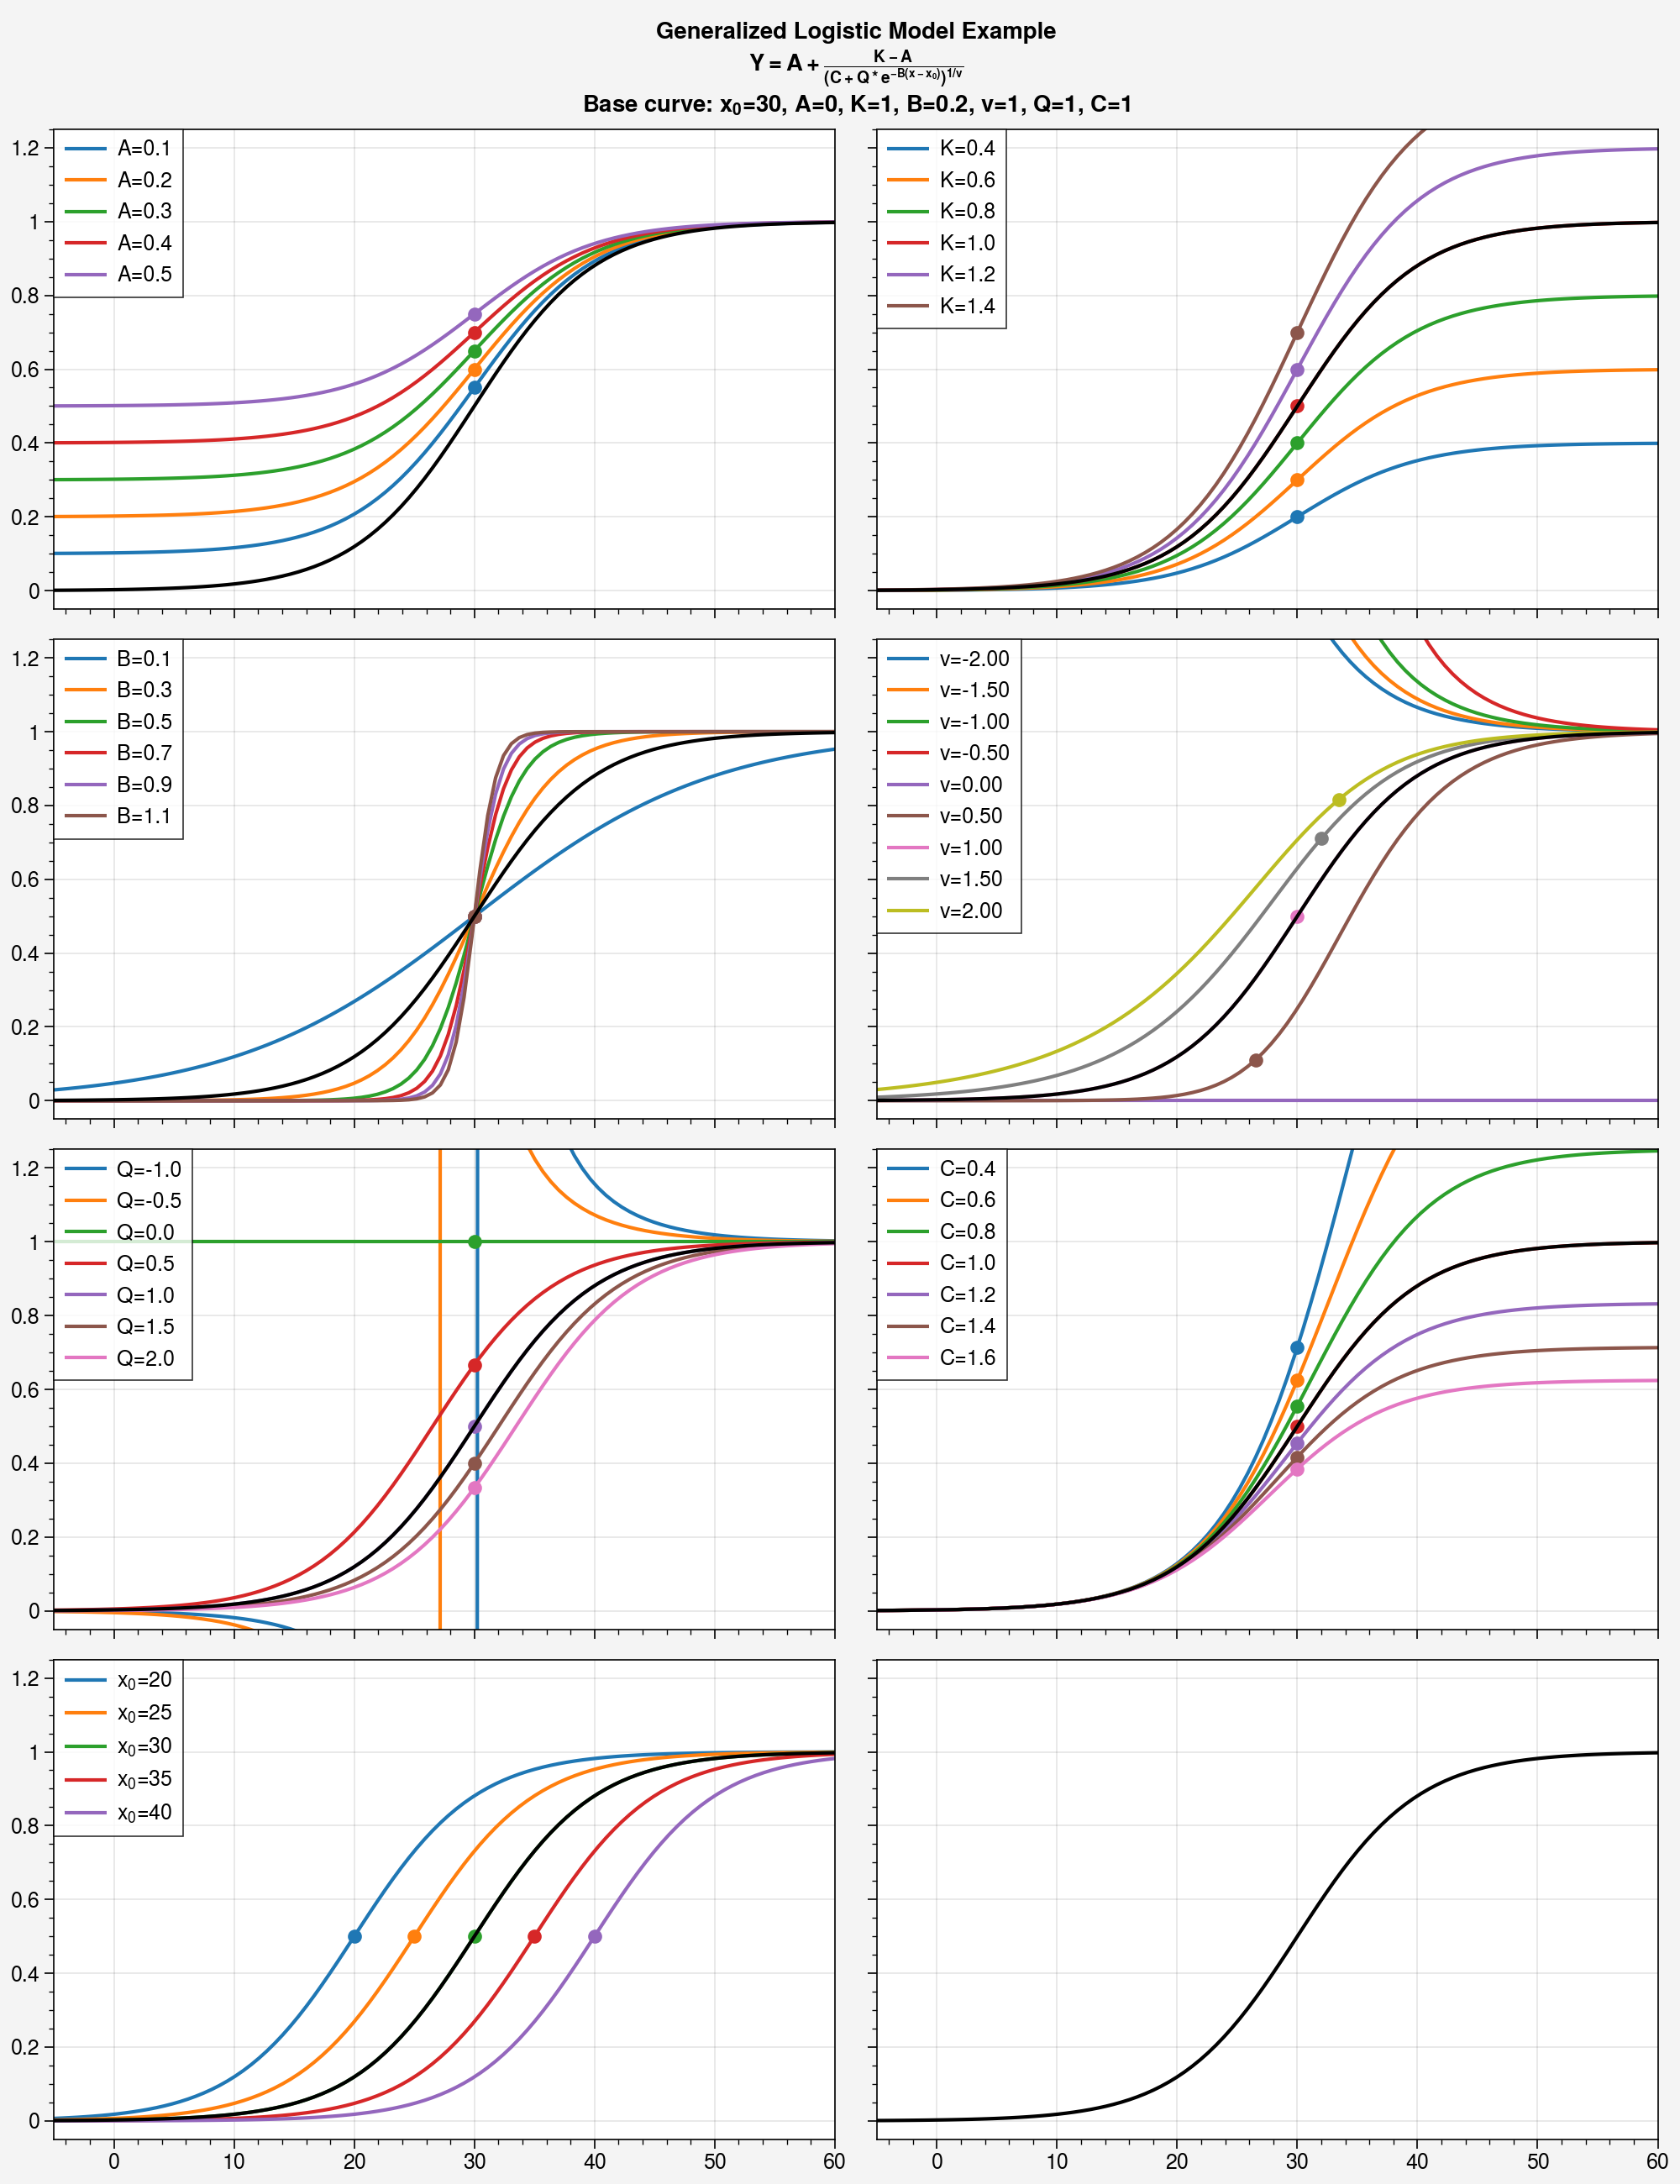

In [16]:
xx = np.linspace(-5,60,100)
sel_a = 0
sel_k = 1
sel_b = 0.2
sel_v = 1
sel_q = 1
sel_x0 = 30


fig, axs = plot.subplots(figsize=(10,13),nrows=4,ncols=2)

### varying A
AA = np.arange(0.1, 0.51, 0.1)
for i, a in enumerate(AA):
    sel_c = plot.get_colors('tab10', len(AA))
    pred_y = generalized_logistic_model(
        A=a,K=sel_k,B=sel_b,v=sel_v,Q=sel_q,C=1,
        x=xx,x0=sel_x0
    )
    axs[0].plot(xx, pred_y, label=f'A={a:.1f}', color=sel_c[i])
    
    ## Add inflection point
    inflection_x = generalized_logistic_inflection_point(sel_x0, sel_b, sel_v)
    inflection_y = generalized_logistic_model(
        A=a,K=sel_k,B=sel_b,v=sel_v,Q=sel_q,C=1,
        x=inflection_x,x0=sel_x0
    )
    axs[0].plot(inflection_x, inflection_y, 'o', color=sel_c[i], markersize=5, label=f'')
h, l = axs[0].get_legend_handles_labels()
axs[0].legend(handles=h, labels=l, loc='upper left', fontsize=10, ncols=1)

axs.format(
    ylim=(-0.05, 1.05),
)

### varying K
KK = np.arange(0.4, 1.41, 0.2)
for i, k in enumerate(KK):
    sel_c = plot.get_colors('tab10', len(KK))
    pred_y = generalized_logistic_model(
        A=sel_a,K=k,B=sel_b,v=sel_v,Q=sel_q,C=1,
        x=xx,x0=sel_x0
    )
    axs[1].plot(xx, pred_y, label=f'K={k:.1f}', color=sel_c[i])
    
    ## Add inflection point
    inflection_x = generalized_logistic_inflection_point(sel_x0, sel_b, sel_v)
    inflection_y = generalized_logistic_model(
        A=sel_a,K=k,B=sel_b,v=sel_v,Q=sel_q,C=1,
        x=inflection_x,x0=sel_x0
    )
    axs[1].plot(inflection_x, inflection_y, 'o', color=sel_c[i], markersize=5, label=f'')
h, l = axs[1].get_legend_handles_labels()
axs[1].legend(handles=h, labels=l, loc='upper left', fontsize=10, ncols=1)

### varying B
BB = np.arange(0.1, 1.2, 0.2)
for i, b in enumerate(BB):
    sel_c = plot.get_colors('tab10', len(BB))
    pred_y = generalized_logistic_model(
        A=sel_a,K=sel_k,B=b,v=sel_v,Q=sel_q,C=1,
        x=xx,x0=sel_x0
    )
    axs[2].plot(xx, pred_y, label=f'B={b:.1f}', color=sel_c[i])
    
    ## Add inflection point
    inflection_x = generalized_logistic_inflection_point(sel_x0, b, sel_v)
    inflection_y = generalized_logistic_model(
        A=sel_a,K=sel_k,B=b,v=sel_v,Q=sel_q,C=1,
        x=inflection_x,x0=sel_x0
    )
    axs[2].plot(inflection_x, inflection_y, 'o', color=sel_c[i], markersize=5, label=f'')

h, l = axs[2].get_legend_handles_labels()
axs[2].legend(handles=h, labels=l, loc='upper left', fontsize=10, ncols=1)

### varying v
VV = np.arange(-2, 2.01, 0.5)
for i, v in enumerate(VV):
    sel_c = plot.get_colors('tab10', len(VV))
    pred_y = generalized_logistic_model(
        A=sel_a,K=sel_k,B=sel_b,v=v,Q=sel_q,C=1,
        x=xx,x0=sel_x0
    )
    axs[3].plot(xx, pred_y, label=f'v={v:.2f}', color=sel_c[i])
    
    ## Add inflection point
    inflection_x = generalized_logistic_inflection_point(sel_x0, sel_b, v)
    inflection_y = generalized_logistic_model(
        A=sel_a,K=sel_k,B=sel_b,v=v,Q=sel_q,C=1,
        x=inflection_x,x0=sel_x0
    )
    axs[3].plot(inflection_x, inflection_y, 'o', color=sel_c[i], markersize=5, label=f'')
h, l = axs[3].get_legend_handles_labels()
axs[3].legend(handles=h, labels=l, loc='upper left', fontsize=10, ncols=1)

### varying Q
QQ = np.arange(-1.0, 2.4, 0.5)
for i, q in enumerate(QQ):
    sel_c = plot.get_colors('tab10', len(QQ))
    pred_y = generalized_logistic_model(
        A=sel_a,K=sel_k,B=sel_b,v=sel_v,Q=q,C=1,
        x=xx,x0=sel_x0
    )
    axs[4].plot(xx, pred_y, label=f'Q={q:.1f}', color=sel_c[i])
    
    ## Add inflection point
    inflection_x = generalized_logistic_inflection_point(sel_x0, sel_b, sel_v)
    inflection_y = generalized_logistic_model(
        A=sel_a,K=sel_k,B=sel_b,v=sel_v,Q=q,C=1,
        x=inflection_x,x0=sel_x0
    )
    axs[4].plot(inflection_x, inflection_y, 'o', color=sel_c[i], markersize=5, label=f'')
h, l = axs[4].get_legend_handles_labels()
axs[4].legend(handles=h, labels=l, loc='upper left', fontsize=10, ncols=1)


#### varying C
CC = np.arange(0.4, 1.61, 0.2)
for i, c in enumerate(CC): 
    sel_c = plot.get_colors('tab10', len(CC))
    pred_y = generalized_logistic_model(
        A=sel_a,K=sel_k,B=sel_b,v=sel_v,Q=sel_q,C=c,
        x=xx,x0=sel_x0
    )
    axs[5].plot(xx, pred_y, label=f'C={c:.1f}', color=sel_c[i])
    
    ## Add inflection point
    inflection_x = generalized_logistic_inflection_point(sel_x0, sel_b, sel_v)
    inflection_y = generalized_logistic_model(
        A=sel_a,K=sel_k,B=sel_b,v=sel_v,Q=sel_q,C=c,
        x=inflection_x,x0=sel_x0
    )
    axs[5].plot(inflection_x, inflection_y, 'o', color=sel_c[i], markersize=5, label=f'')
h, l = axs[5].get_legend_handles_labels()
axs[5].legend(handles=h, labels=l, loc='upper left', fontsize=10, ncols=1)


### Varying x0
X0 = np.arange(20, 41, 5)
for i, x0 in enumerate(X0):
    sel_c = plot.get_colors('tab10', len(X0))
    pred_y = generalized_logistic_model(
        A=sel_a,K=sel_k,B=sel_b,v=sel_v,Q=sel_q,C=1,
        x=xx,x0=x0
    )
    axs[6].plot(xx, pred_y, label=r'x$_{0}$='+f'{x0}', color=sel_c[i])

    ## Add inflection point
    inflection_x = generalized_logistic_inflection_point(x0, sel_b, sel_v)
    inflection_y = generalized_logistic_model(
        A=sel_a,K=sel_k,B=sel_b,v=sel_v,Q=sel_q,C=1,
        x=inflection_x,x0=x0
    )
    axs[6].plot(inflection_x, inflection_y, 'o', color=sel_c[i], markersize=5, label=f'')
h, l = axs[6].get_legend_handles_labels()
axs[6].legend(handles=h, labels=l, loc='upper left', fontsize=10, ncols=1)


##############################################################

sel_a = 0
sel_k = 1
sel_b = 0.2
sel_v = 1
sel_q = 1
sel_x0 = 30
pred_y = generalized_logistic_model(
    A=sel_a,K=sel_k,B=sel_b,v=sel_v,Q=sel_q,C=1,
    x=xx,x0=sel_x0
)

axs.plot(xx, pred_y, label='Generalized Logistic Model', color='k')
eq_str = r'$Y = A + \frac{K - A}{(C + Q * e^{-B(x - x_{0})})^{1/v}}$'
text_str = fr'Base curve: x$_{0}$='+f'{sel_x0}, A={sel_a}, K={sel_k}, B={sel_b}, v={sel_v}, Q={sel_q}, C=1'

axs.format(
    suptitle=f'Generalized Logistic Model Example\n{eq_str}\n{text_str}',
    ylim=(-0.05, 1.25),
)

| Parameter | Description                                 | Increasing →                                                           | Decreasing →                                                    | Notes                                              |
| --------- | ------------------------------------------- | ---------------------------------------------------------------------- | --------------------------------------------------------------- | -------------------------------------------------- |
| **A**     | Lower asymptote (left horizontal level)     | Curve starts from a **higher baseline**                                | Curve starts from a **lower baseline**                          | See top-left subplot (A=0.1–0.5)                   |
| **K**     | Upper asymptote (right horizontal level)    | Curve levels off **higher**                                            | Curve levels off **lower**                                      | See top-right subplot                              |
| **B**     | Growth rate / steepness                     | Curve becomes **steeper**, transitions more abruptly                   | Curve becomes **flatter**, transitions more gradually           | See middle-left subplot                            |
| **ν (v)** | Asymmetry / shape                           | Inflection point shifts **right**, curve becomes more **right-skewed** | Inflection point shifts **left**, curve becomes **left-skewed** | See middle-right subplot                           |
| **Q**     | Horizontal stretch / curve-start factor     | Curve shifts **rightward** and flattens                                | Curve shifts **leftward** and steepens                          | Affects timing of rise. See lower-left subplot     |
| **C**     | Additive constant inside denominator        | Delays rise and **lowers the upper asymptote** when $C > 1$            | Accelerates rise, **can overshoot** when $C < 1$                | Uncommon to vary this; see lower-middle subplot    |
| **x₀**    | Horizontal shift (center/starting location) | Shifts curve **rightward**                                             | Shifts curve **leftward**                                       | Does **not change shape**; see lower-right subplot |


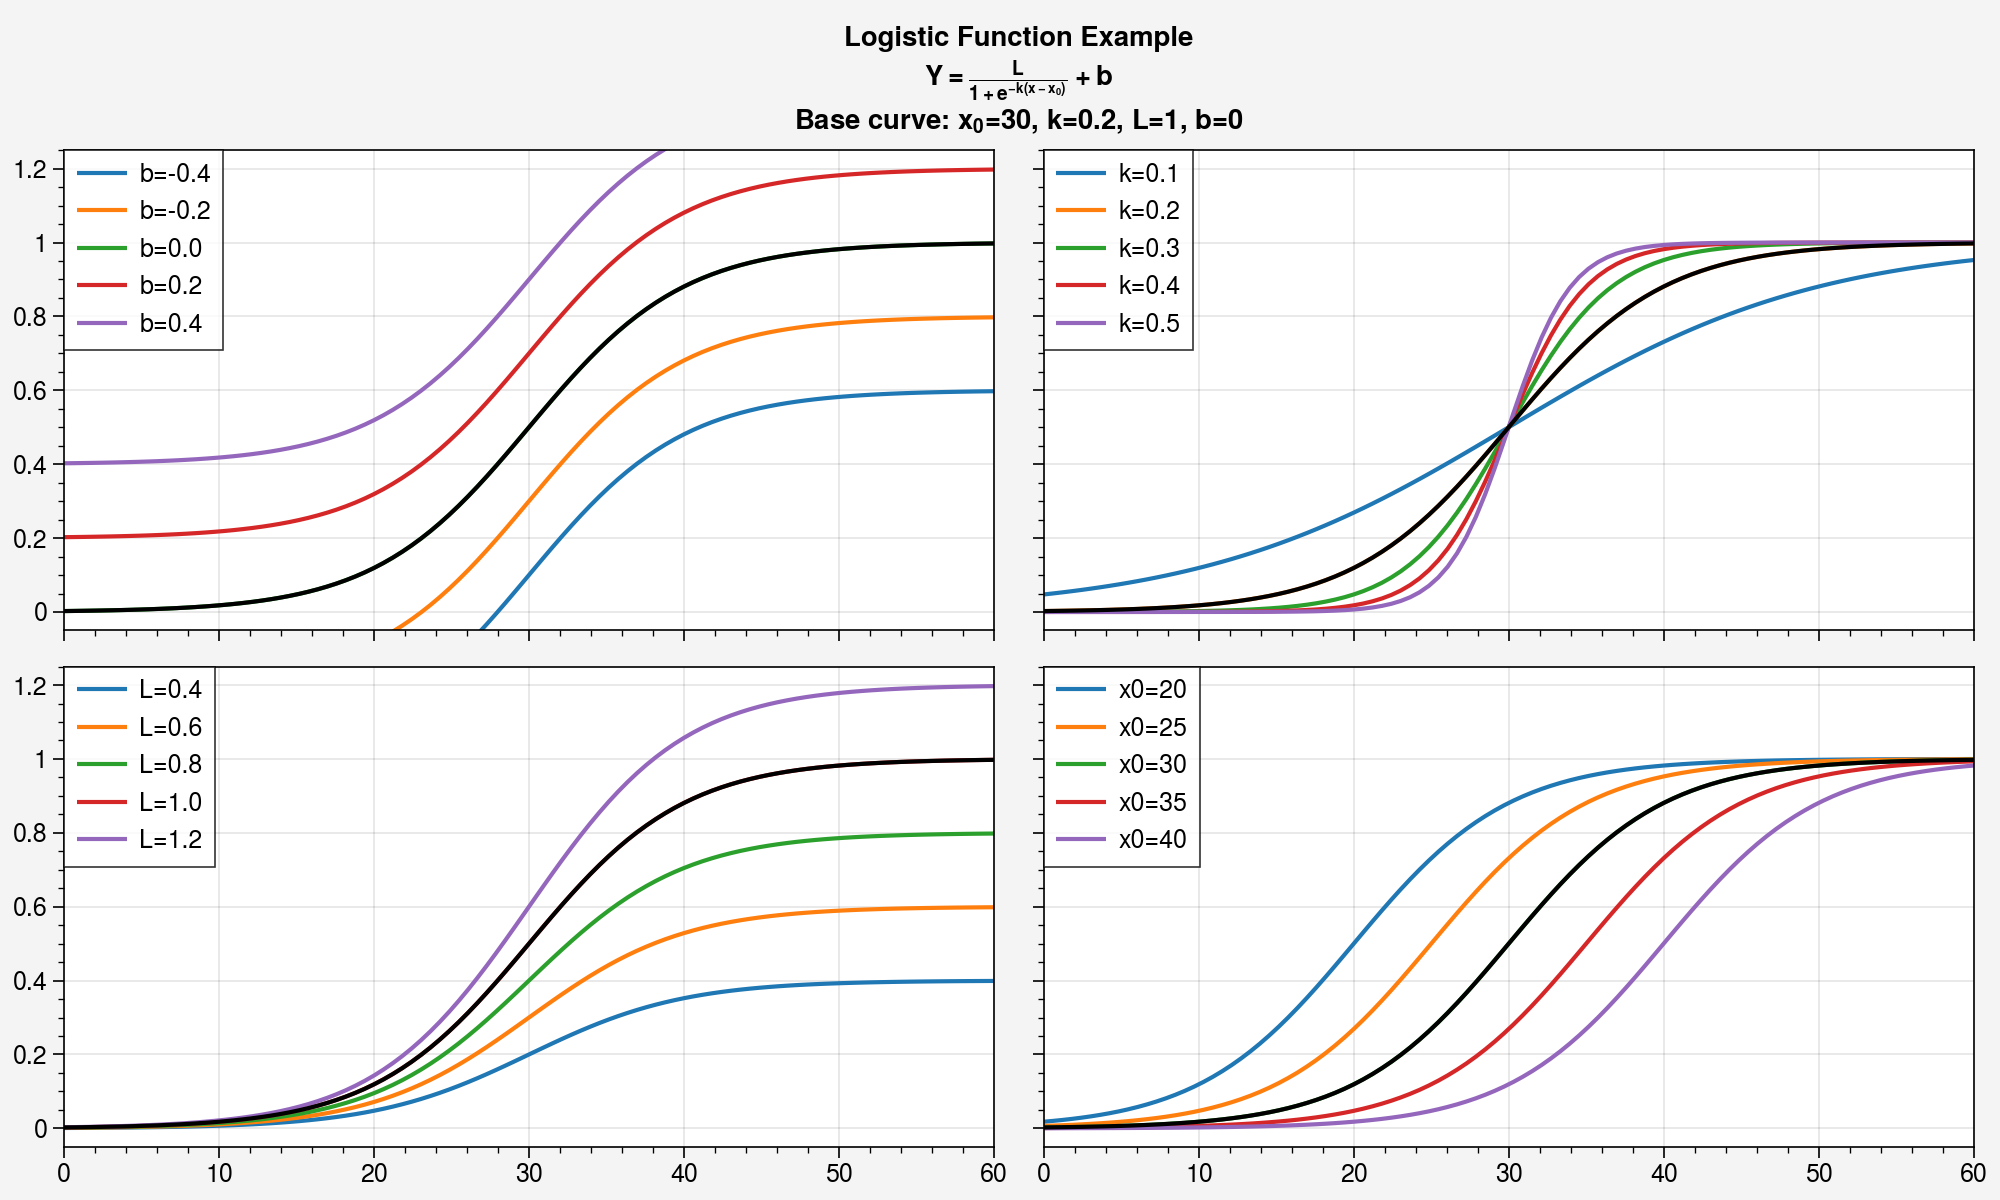

In [17]:
fig, axs = plot.subplots(figsize=(10, 6), nrows=2, ncols=2)

xx = np.linspace(0,60,100)
sel_x0 = 30
sel_b = 0
sel_L = 1
sel_k = 0.2

### varying b
BB = np.arange(-0.4, 0.41, 0.2)
for i, b in enumerate(BB):
    sel_c = plot.get_colors('tab10', len(BB))
    pred_y = logistic(xx, x0=sel_x0, k=sel_k, L=sel_L, b=b)
    axs[0].plot(xx, pred_y, label=f'b={b:.1f}', color=sel_c[i])
h, l = axs[0].get_legend_handles_labels()
axs[0].legend(handles=h, labels=l, loc='upper left', fontsize=10, ncols=1)

### varying k
KK = np.arange(0.1, 0.51, 0.1)
for i, k in enumerate(KK):
    sel_c = plot.get_colors('tab10', len(KK))
    pred_y = logistic(xx, x0=sel_x0, k=k, L=sel_L, b=sel_b)
    axs[1].plot(xx, pred_y, label=f'k={k:.1f}', color=sel_c[i])
h, l = axs[1].get_legend_handles_labels()
axs[1].legend(handles=h, labels=l, loc='upper left', fontsize=10, ncols=1)

### varying L
LL = np.arange(0.4, 1.21, 0.2)
for i, L in enumerate(LL):
    sel_c = plot.get_colors('tab10', len(LL))
    pred_y = logistic(xx, x0=sel_x0, k=sel_k, L=L, b=sel_b)
    axs[2].plot(xx, pred_y, label=f'L={L:.1f}', color=sel_c[i])
h, l = axs[2].get_legend_handles_labels()
axs[2].legend(handles=h, labels=l, loc='upper left', fontsize=10, ncols=1)

### varying x0
X0 = np.arange(20, 41, 5)
for i, x0 in enumerate(X0):
    sel_c = plot.get_colors('tab10', len(X0))
    pred_y = logistic(xx, x0=x0, k=sel_k, L=sel_L, b=sel_b)
    axs[3].plot(xx, pred_y, label=f'x0={x0}', color=sel_c[i])
h, l = axs[3].get_legend_handles_labels()
axs[3].legend(handles=h, labels=l, loc='upper left', fontsize=10, ncols=1)

sel_x0 = 30
sel_k = 0.2
sel_L = 1
sel_b = 0
pred_y = logistic(xx, x0=sel_x0, k=sel_k, L=sel_L, b=sel_b)

axs.plot(xx, pred_y, label='Logistic Function', color='k')
eq_str = r'$Y = \frac{L}{1 + e^{-k(x -x_0)}} + b$'
text_str = r'Base curve: x$_{0}$='+f'{sel_x0}, k={sel_k}, L={sel_L}, b={sel_b}'
axs.format(
    suptitle=f'Logistic Function Example\n{eq_str}\n{text_str}',
    ylim=(-0.05, 1.25),
)

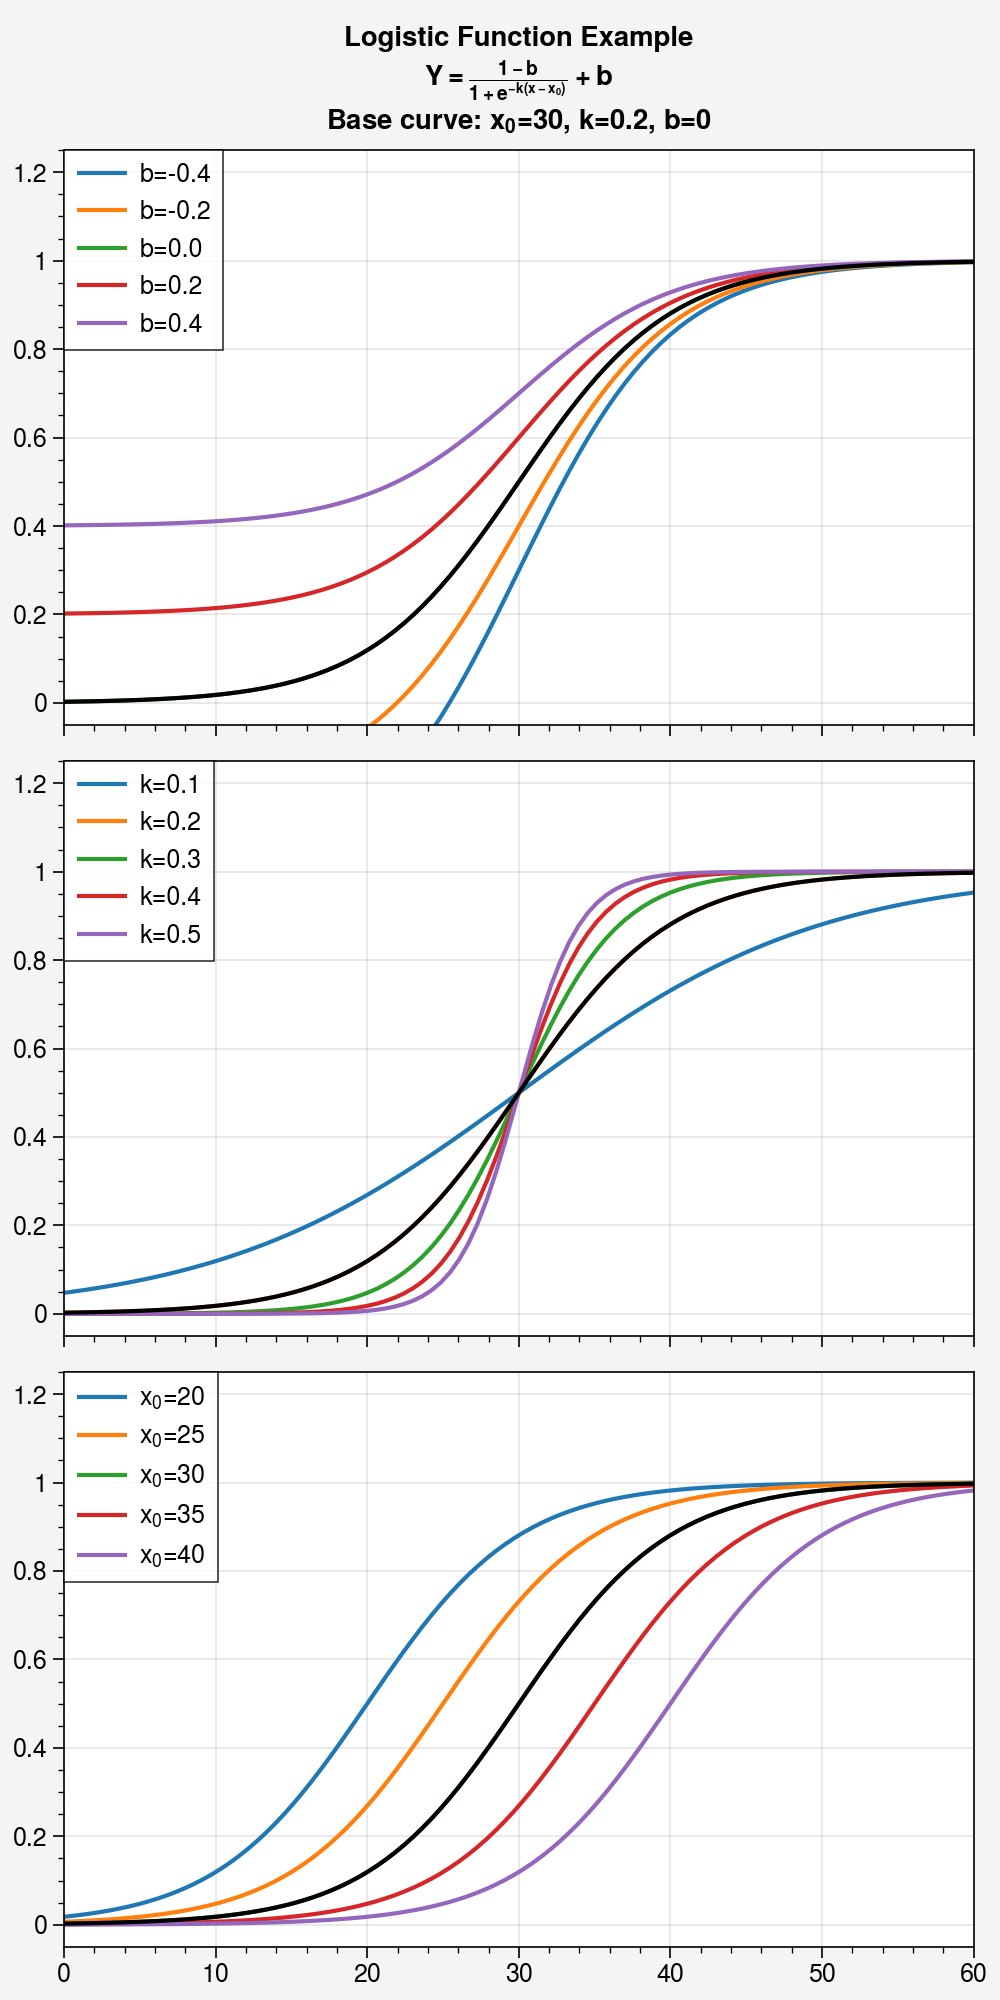

In [18]:
fig, axs = plot.subplots(figsize=(5, 10), nrows=3, ncols=1)

xx = np.linspace(0,60,100)
sel_t0 = 30
sel_b = 0
sel_k = 0.2

### varying b
BB = np.arange(-0.4, 0.41, 0.2)
for i, b in enumerate(BB):
    sel_c = plot.get_colors('tab10', len(BB))
    pred_y = logistic_fixed_upper(xx, t0=sel_t0, k=sel_k, b=b)
    axs[0].plot(xx, pred_y, label=f'b={b:.1f}', color=sel_c[i])
h, l = axs[0].get_legend_handles_labels()
axs[0].legend(handles=h, labels=l, loc='upper left', fontsize=10, ncols=1)

### varying k
KK = np.arange(0.1, 0.51, 0.1)
for i, k in enumerate(KK):
    sel_c = plot.get_colors('tab10', len(KK))
    pred_y = logistic_fixed_upper(xx, t0=sel_t0, k=k, b=sel_b)
    axs[1].plot(xx, pred_y, label=f'k={k:.1f}', color=sel_c[i])
h, l = axs[1].get_legend_handles_labels()
axs[1].legend(handles=h, labels=l, loc='upper left', fontsize=10, ncols=1)

### varying t0
T0 = np.arange(20, 41, 5)
for i, t0 in enumerate(T0):
    sel_c = plot.get_colors('tab10', len(T0))
    pred_y = logistic_fixed_upper(xx, t0=t0, k=sel_k, b=sel_b)
    axs[2].plot(xx, pred_y, label=r'x$_{0}$='+f'{t0}', color=sel_c[i])
h, l = axs[2].get_legend_handles_labels()
axs[2].legend(handles=h, labels=l, loc='upper left', fontsize=10, ncols=1)


sel_t0 = 30
sel_k = 0.2
sel_L = 1
sel_b = 0
pred_y = logistic_fixed_upper(xx, t0=sel_t0, k=sel_k, b=sel_b)

axs.plot(xx, pred_y, label='Logistic Function', color='k')
eq_str = r'$Y = \frac{1-b}{1 + e^{-k(x -x_0)}} + b$'
text_str = r'Base curve: x$_{0}$='+f'{sel_x0}, k={sel_k}, b={sel_b}'
axs.format(
    suptitle=f'Logistic Function Example\n{eq_str}\n{text_str}',
    ylim=(-0.05, 1.25),
)

# Performance metrics

08:37:55 - cmdstanpy - INFO - CmdStan start processing


Using parameters: ['t0_crtp', 'k_crtp', 'b_crtp', 'beta0_gdgt23ratio_crtp']
use_gdgt23ratio in attrs: True, use_no3 in attrs: False
{'N': 1348, 'scaledRI': array([0.50998201, 0.438075  , 0.41093053, ..., 0.39985   , 0.433075  ,
       0.416475  ]), 'prior_mu_t': array([20., 20., 20., ..., 20., 20., 20.]), 'prior_sigma_t': 10, 'mu_t0': 27.041775275, 'mu_k': 0.13016620225, 'mu_b': 0.45923771724999995, 'std_t0': 0.19560700520731455, 'std_k': 0.005208562837611248, 'std_b': 0.004649080992551371, 'no3_cutoff': 0.0, 'mu_sigma_scaledRI': 0.050129166925, 'std_sigma_scaledRI': 0.0009591910719421571, 'gdgt23ratio': array([1.50283851, 2.83333333, 1.82483181, ..., 9.55555556, 2.87037037,
       6.45454545]), 'mu_beta0_gdgt23ratio': -0.0054151866775, 'std_beta0_gdgt23ratio': 0.0004064865738978792, 'use_gdgt23ratio': 1, 'no3': array([0., 0., 0., ..., 0., 0., 0.]), 'mu_beta0_no3': 0.0, 'std_beta0_no3': 0.1, 'use_no3': 0, 'calibration_model_name': 'jnt_cul_meso_hier_crtp_multiv', 'posteriors_used': ['t

chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

08:39:03 - cmdstanpy - INFO - CmdStan done processing.
08:39:03 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'invT_logistic_fixed_multiv_meanprior_bayes.stan', line 79, column 2 to column 49)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'invT_logistic_fixed_multiv_meanprior_bayes.stan', line 79, column 2 to column 49)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'invT_logistic_fixed_multiv_meanprior_bayes.stan', line 79, column 2 to column 49)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'invT_logistic_fixed_multiv_meanprior_bayes.stan', line 79, column 2 to column 49)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'invT_logistic_fixed_multiv_meanprior_bayes.stan', line 79, column 2 to column 49)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'invT_logistic_fixed_multiv


Sampling completed in 71.4 seconds
⚠️ Sampling diagnostics warning:
 Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

The following parameters had rank-normalized split R-hat greater than 1.01:
  t_est[366], beta0_no3
Such high values indicate incomplete mixing and biased estimation.
You should consider regularizating your model with additional prior information or a more effective parameterization.

Processing complete.

Please specify the temptype (e.g., 'thermoT', 'sst', 'cultureT') to store as an attribute.
['t0', 'k', 'b', 'beta0_gdgt23ratio', 'beta0_no3']


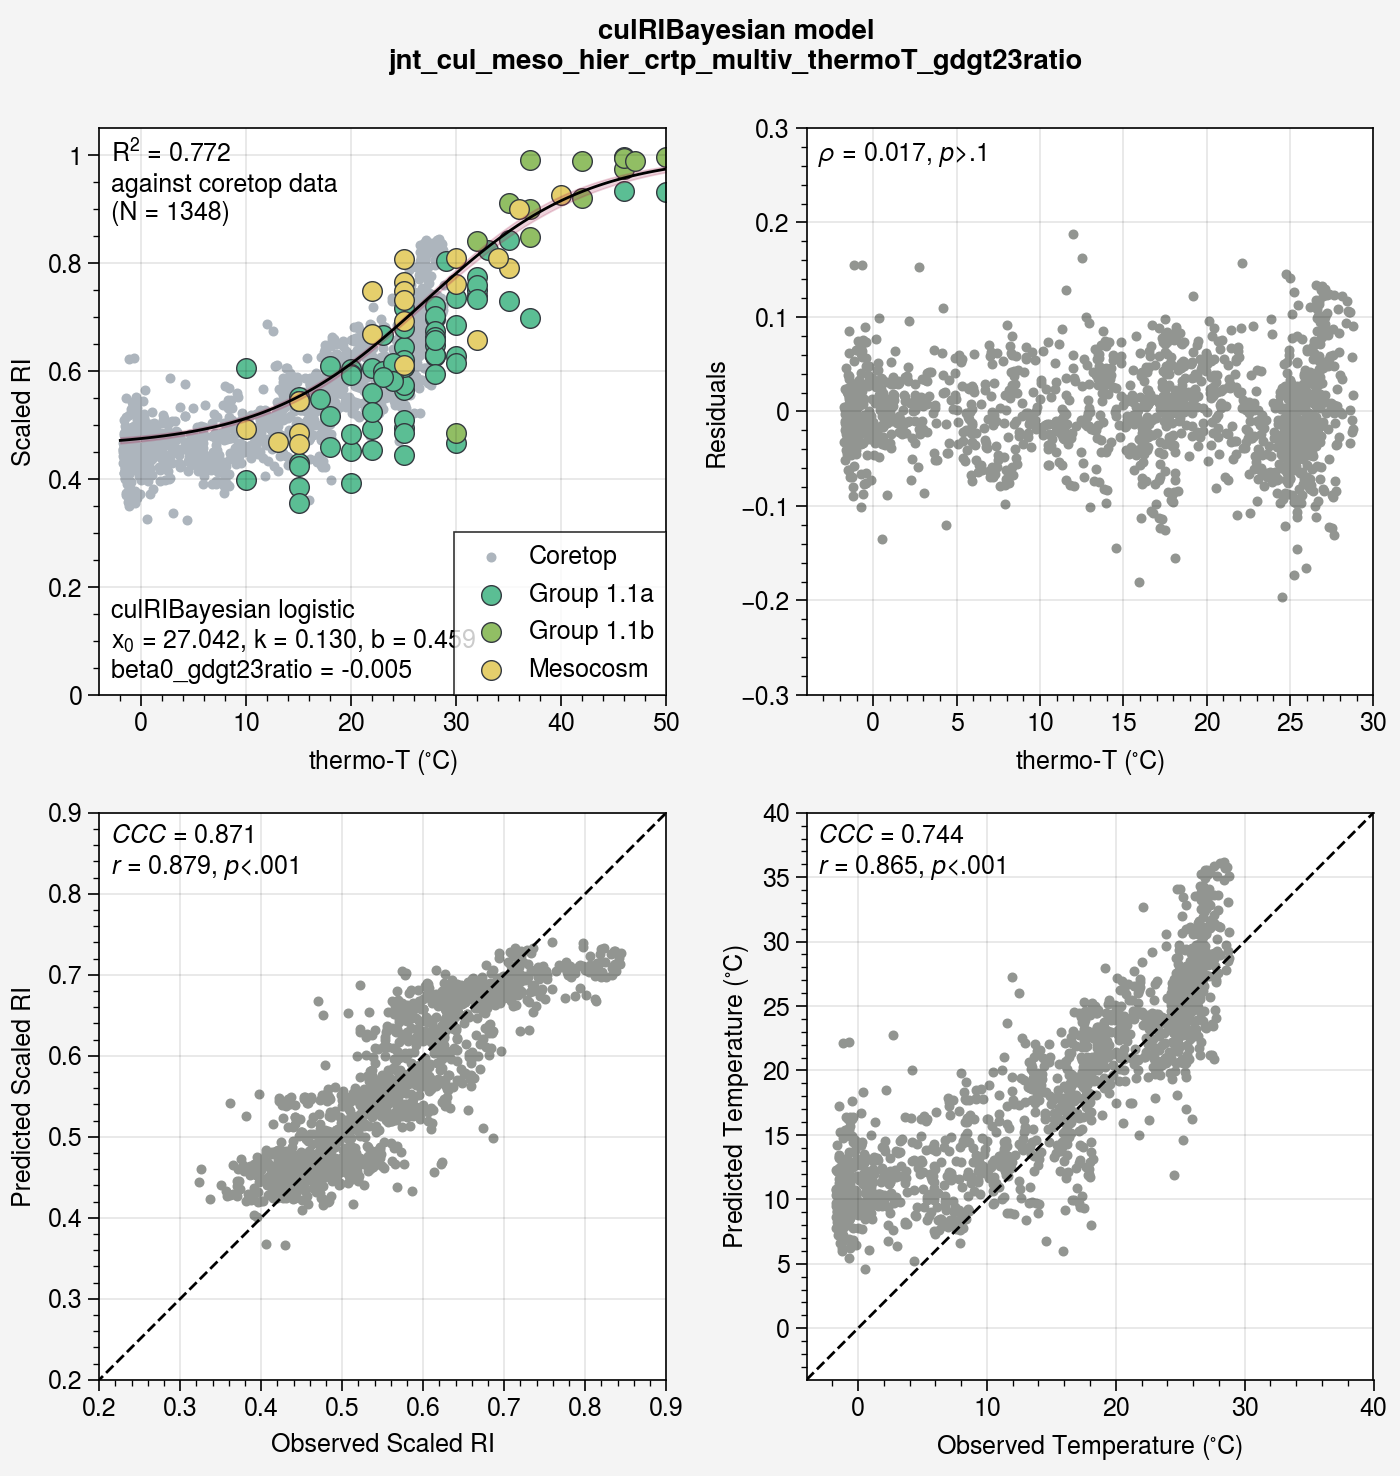

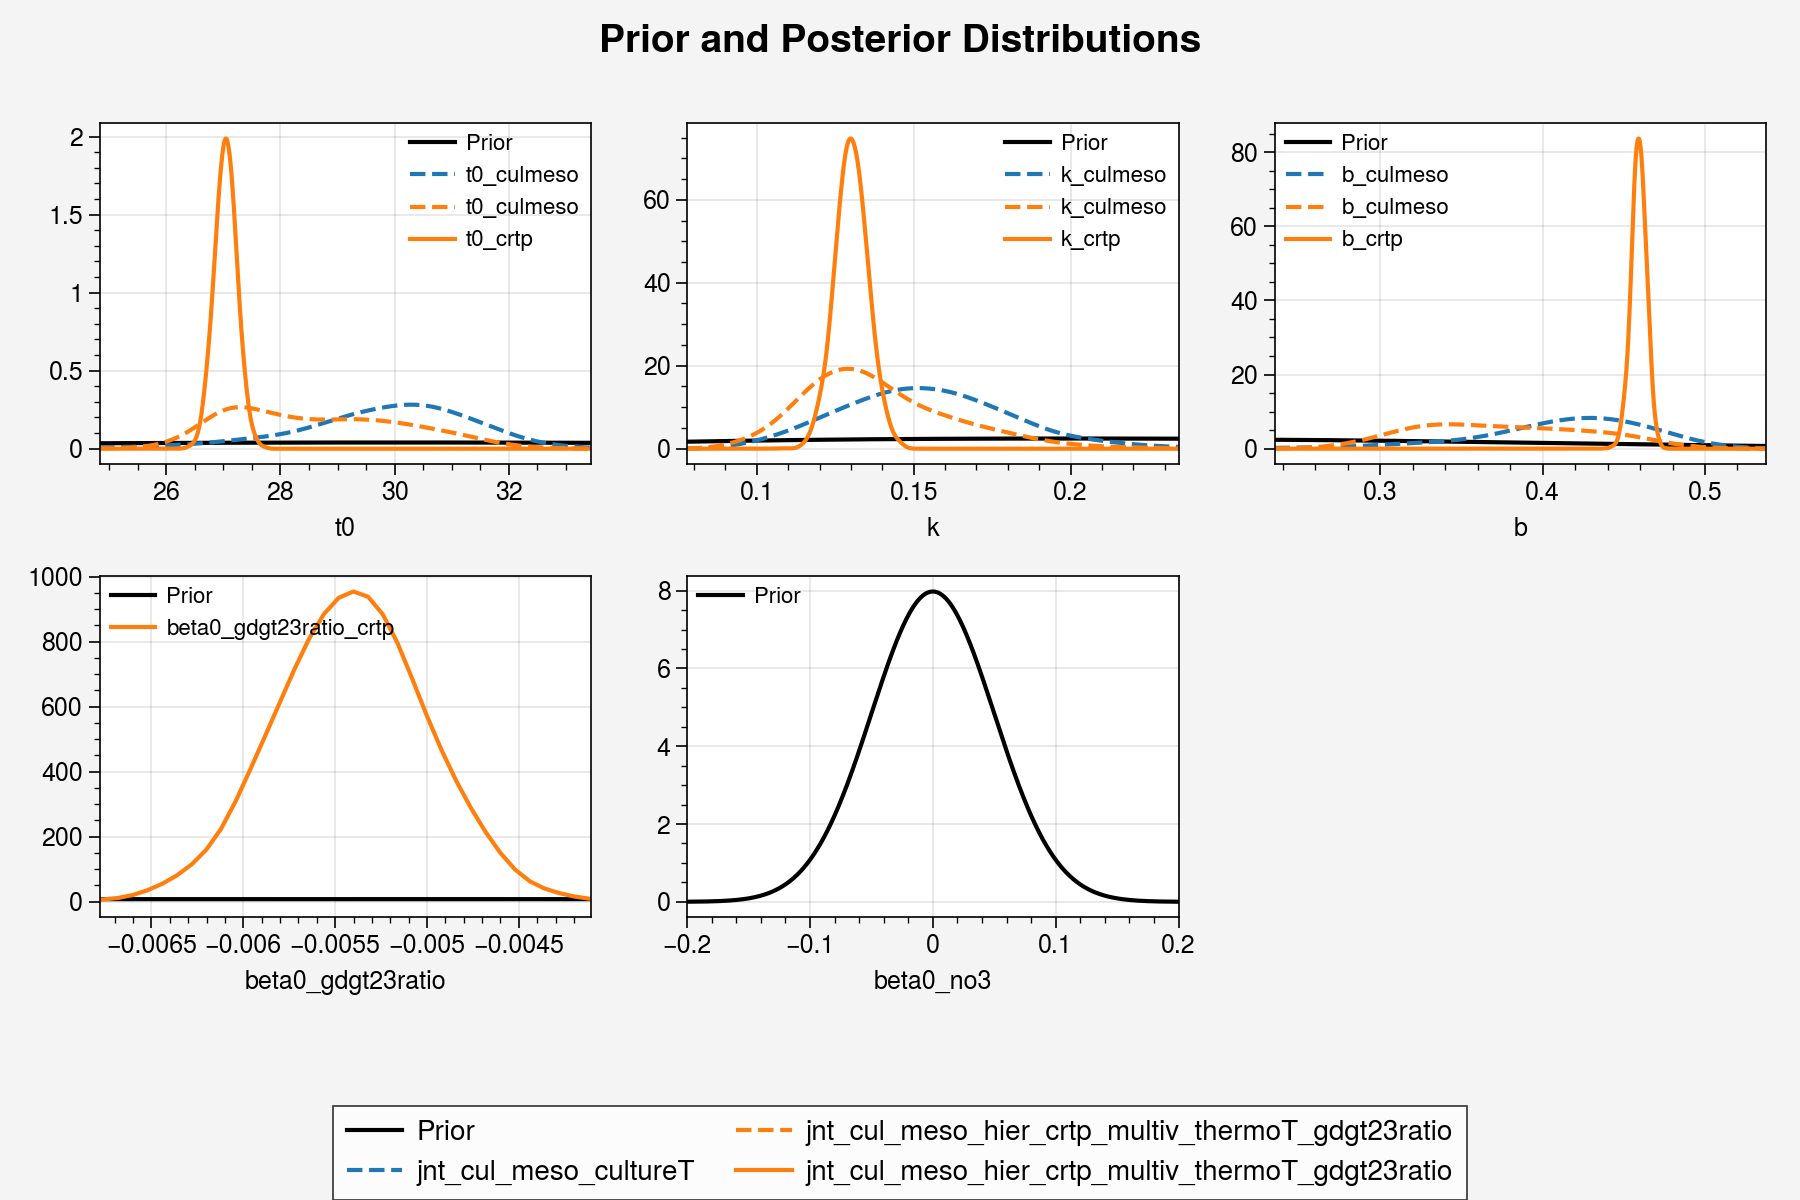

In [21]:
def plot_reg_case(
        use_coretop_df: pd.DataFrame,
        temp_param: str,
        sel_y_param: str = 'scaledRI_median',
        gdgt23ratio_param: str = 'gdgt23ratio_median',
        no3_param: str = 'no3_sf2tc_avg',
        case_: str = 'culmeso-linear',
        stan_post_ds: Optional[str] = None,
        invT_model_mode: Optional[str] = "meanprior_bayes",
        no3_cutoff: Optional[float] = None,
        ):
    plt.close('all')
    fig,axs = plot.subplots(width=7, ncols=2, nrows=2, share=0)
    ax = axs[0]

    label_dict = {
        'sst': 'SST ($^{\circ}$C)',
        't_sf2tc_avg': 'thermo-T ($^{\circ}$C)',
    }

    use_coretop_df = use_coretop_df.replace([np.inf, -np.inf], np.nan).reset_index(drop=True)
    use_coretop_df = use_coretop_df.dropna(subset=[temp_param,sel_y_param]).reset_index(drop=True)

    ax.format(
        xlabel=label_dict.get(temp_param, temp_param),
        ylabel='Scaled RI',
        xlim=(-4, 50),
        ylim=(0, 1.05),
    )

    ax.scatter(use_coretop_df[temp_param], use_coretop_df[sel_y_param],
            color='gray5', m='.', label='coretop data')

    grouped = culture_meso_df[culture_meso_df['Temperature']<=50].groupby('organism_broadClass3')
    for name, group in grouped:
        plot_x = group['Temperature']
        plot_y = group['scaledRI']
        ax.scatter(plot_x, plot_y, 
                mec='gray8',mew=0.5,
                label=name, s=50, 
                cycle='Qual1')
    h, l = ax.get_legend_handles_labels()
    ax.legend(
        h, ['Coretop', 'Group 1.1a', 'Group 1.1b', 'Mesocosm'], loc='lr', fontsize=12,
        title_fontsize=12,
        ncol=1
    )

    if temp_param not in use_coretop_df.columns:
        raise ValueError(f"Temperature parameter '{temp_param}' not found in use_coretop_df.")

    if case_ == 'culmeso-linear':
        xx = np.linspace(-2, 50, 100)
        reg_data = culture_meso_df[culture_meso_df['Temperature']<=50]
        model = LinearRegression()
        model.fit(reg_data[['Temperature']], reg_data['scaledRI'])
        slope_ = model.coef_[0]
        intercept_ = model.intercept_
        pred_y = model.predict(xx.reshape(-1, 1))

        label_model = f'Culture-Mesocosm linear\nm = {slope_:.3f}, b = {intercept_:.3f}'
        test_data = use_coretop_df
        r2_ = r2_score(test_data[sel_y_param], model.predict(test_data[[temp_param]]))
        label_r2 = r'R$^2$ = '+f'{r2_:.3f}\nagainst coretop data\n(N = {len(test_data)})'

        ## performance metrics
        ### y_res
        y_res = test_data[sel_y_param] - model.predict(test_data[[temp_param]])
        nonnan_idx = ~np.isnan(y_res) & ~np.isnan(test_data[temp_param])
        rho_res, pval_res = spearmanr(test_data[temp_param][nonnan_idx], y_res[nonnan_idx])
        
        ### obs_scaledRI vs pred_scaledRI
        obs_scaledRI = test_data[sel_y_param]
        pred_scaledRI = model.predict(test_data[[temp_param]])
        nonnan_idx = ~np.isnan(pred_scaledRI) & ~np.isnan(test_data[temp_param])
        r_pred, pval_pred = pearsonr(obs_scaledRI[nonnan_idx], pred_scaledRI[nonnan_idx])
        ccc = concordance_corr_coef(obs_scaledRI[nonnan_idx], pred_scaledRI[nonnan_idx])

        ### obs_T vs pred_T
        obs_T = test_data[temp_param]
        pred_T = (test_data[sel_y_param] - intercept_ )/ slope_
        r_predT, pval_predT = pearsonr(obs_T[nonnan_idx], pred_T[nonnan_idx])
        ccc_predT = concordance_corr_coef(obs_T[nonnan_idx], pred_T[nonnan_idx])

    if case_ == 'coretop-linear':
        xx = np.linspace(-2, 50, 100)
        reg_data = use_coretop_df
        model = LinearRegression()
        model.fit(reg_data[[temp_param]], reg_data[sel_y_param])
        slope_ = model.coef_[0]
        intercept_ = model.intercept_
        pred_y = model.predict(xx.reshape(-1, 1))

        label_model = f'Coretop linear\nm = {slope_:.3f}, b = {intercept_:.3f}'
        test_data = use_coretop_df
        r2_ = r2_score(test_data[sel_y_param], model.predict(test_data[[temp_param]]))
        label_r2 = r'R$^2$ = '+f'{r2_:.3f}\nagainst coretop data\n(N = {len(test_data)})'

        ## performance metrics
        ### y_res
        y_res = test_data[sel_y_param] - model.predict(test_data[[temp_param]])
        nonnan_idx = ~np.isnan(y_res) & ~np.isnan(test_data[temp_param])
        rho_res, pval_res = spearmanr(test_data[temp_param][nonnan_idx], y_res[nonnan_idx])
        
        ### obs_scaledRI vs pred_scaledRI
        obs_scaledRI = test_data[sel_y_param]
        pred_scaledRI = model.predict(test_data[[temp_param]])
        nonnan_idx = ~np.isnan(pred_scaledRI) & ~np.isnan(test_data[temp_param])
        r_pred, pval_pred = pearsonr(obs_scaledRI[nonnan_idx], pred_scaledRI[nonnan_idx])
        ccc = concordance_corr_coef(obs_scaledRI[nonnan_idx], pred_scaledRI[nonnan_idx])

        ### obs_T vs pred_T
        obs_T = test_data[temp_param]
        pred_T = (test_data[sel_y_param] - intercept_ )/ slope_
        r_predT, pval_predT = pearsonr(obs_T[nonnan_idx], pred_T[nonnan_idx])
        ccc_predT = concordance_corr_coef(obs_T[nonnan_idx], pred_T[nonnan_idx])


    if case_ == 'culmesocore-linear':
        culture_meso_df[temp_param] = culture_meso_df['Temperature']
        culture_meso_df[sel_y_param] = culture_meso_df['scaledRI']
        combined_df = pd.concat([culture_meso_df, use_coretop_df], ignore_index=True)
        
        xx = np.linspace(-2, 50, 100)
        reg_data = combined_df[combined_df[temp_param]<=50]
        model = LinearRegression()
        model.fit(reg_data[[temp_param]], reg_data[sel_y_param])
        slope_ = model.coef_[0]
        intercept_ = model.intercept_
        pred_y = model.predict(xx.reshape(-1, 1))
        
        label_model = f'Cul-Meso-Core linear\nm = {slope_:.3f}, b = {intercept_:.3f}'
        test_data = use_coretop_df
        r2_ = r2_score(test_data[sel_y_param], model.predict(test_data[[temp_param]]))
        label_r2 = r'R$^2$ = '+f'{r2_:.3f}\nagainst coretop data\n(N = {len(test_data)})'
        ## performance metrics
        ### y_res
        y_res = test_data[sel_y_param] - model.predict(test_data[[temp_param]])
        nonnan_idx = ~np.isnan(y_res) & ~np.isnan(test_data[temp_param])
        rho_res, pval_res = spearmanr(test_data[temp_param][nonnan_idx], y_res[nonnan_idx])

        ### obs_scaledRI vs pred_scaledRI
        obs_scaledRI = test_data[sel_y_param]
        pred_scaledRI = model.predict(test_data[[temp_param]])
        nonnan_idx = ~np.isnan(pred_scaledRI) & ~np.isnan(test_data[temp_param])
        r_pred, pval_pred = pearsonr(obs_scaledRI[nonnan_idx], pred_scaledRI[nonnan_idx])
        ccc = concordance_corr_coef(obs_scaledRI[nonnan_idx], pred_scaledRI[nonnan_idx])

        #### obs_T vs pred_T
        obs_T = test_data[temp_param]
        pred_T = (test_data[sel_y_param] - intercept_ )/ slope_
        r_predT, pval_predT = pearsonr(obs_T[nonnan_idx], pred_T[nonnan_idx])
        ccc_predT = concordance_corr_coef(obs_T[nonnan_idx], pred_T[nonnan_idx])

    if case_ == 'culmeso-logistic':
        xx = np.linspace(-2, 50, 100)
        reg_data = culture_meso_df[culture_meso_df['Temperature']<=50]
        popt, pcov = curve_fit(logistic_fixed_upper,
                            reg_data['Temperature'], 
                            reg_data['scaledRI'], 
                            bounds=([0, 0, 0], [50, 1, 1]),)
        pred_y = logistic_fixed_upper(xx, *popt)
        label_model = f'Culture-Mesocosm logistic\nx$_{{0}}$ = {popt[0]:.1f}, k = {popt[1]:.1f}, b = {popt[2]:.3f}'
        test_data = use_coretop_df
        r2_ = r2_score(test_data[sel_y_param], logistic_fixed_upper(test_data[temp_param], *popt))
        label_r2 = f'R$^2$ = {r2_:.3f}\nagainst coretop data\n(N = {len(test_data)})'

        ## performance metrics
        ### y_res
        y_res = test_data[sel_y_param] - logistic_fixed_upper(test_data[temp_param], *popt)
        nonnan_idx = ~np.isnan(y_res) & ~np.isnan(test_data[temp_param])
        rho_res, pval_res = spearmanr(test_data[temp_param][nonnan_idx], y_res[nonnan_idx])

        ### obs_scaledRI vs pred_scaledRI
        obs_scaledRI = test_data[sel_y_param]
        pred_scaledRI = logistic_fixed_upper(test_data[temp_param], *popt)
        nonnan_idx = ~np.isnan(pred_scaledRI) & ~np.isnan(test_data[temp_param])
        r_pred, pval_pred = pearsonr(obs_scaledRI[nonnan_idx], pred_scaledRI[nonnan_idx])
        ccc = concordance_corr_coef(obs_scaledRI[nonnan_idx], pred_scaledRI[nonnan_idx])

        ### obs_T vs pred_T
        obs_T = test_data[temp_param]
        pred_T = inverse_logistic_fixed_upper(test_data[sel_y_param], *popt)
        nonnan_idx = ~np.isnan(pred_T) & ~np.isnan(test_data[temp_param])
        r_predT, pval_predT = pearsonr(obs_T[nonnan_idx], pred_T[nonnan_idx])
        ccc_predT = concordance_corr_coef(obs_T[nonnan_idx], pred_T[nonnan_idx])
    
    if case_ == 'coretop-logistic':
        xx = np.linspace(-2, 50, 100)
        reg_data = use_coretop_df
        popt, pcov = curve_fit(logistic_fixed_upper,
                            reg_data[temp_param], 
                            reg_data[sel_y_param], 
                            bounds=([0, 0, 0], [50, 1, 1]),
                            )
        pred_y = logistic_fixed_upper(xx, *popt)
        label_model = f'Coretop logistic\nx$_{{0}}$ = {popt[0]:.1f}, k = {popt[1]:.1f}, b = {popt[2]:.3f}'
        test_data = use_coretop_df
        r2_ = r2_score(test_data[sel_y_param], logistic_fixed_upper(test_data[temp_param], *popt))
        label_r2 = f'R$^2$ = {r2_:.3f}\nagainst coretop data\n(N = {len(test_data)})'

        ## performance metrics
        ### y_res
        y_res = test_data[sel_y_param] - logistic_fixed_upper(test_data[temp_param], *popt)
        nonnan_idx = ~np.isnan(y_res) & ~np.isnan(test_data[temp_param])
        rho_res, pval_res = spearmanr(test_data[temp_param][nonnan_idx], y_res[nonnan_idx])

        ### obs_scaledRI vs pred_scaledRI
        obs_scaledRI = test_data[sel_y_param]
        pred_scaledRI = logistic_fixed_upper(test_data[temp_param], *popt)
        nonnan_idx = ~np.isnan(pred_scaledRI) & ~np.isnan(test_data[temp_param])
        r_pred, pval_pred = pearsonr(obs_scaledRI[nonnan_idx], pred_scaledRI[nonnan_idx])
        ccc = concordance_corr_coef(obs_scaledRI[nonnan_idx], pred_scaledRI[nonnan_idx])

        ### obs_T vs pred_T
        obs_T = test_data[temp_param]
        pred_T = inverse_logistic_fixed_upper(test_data[sel_y_param], *popt)
        nonnan_idx = ~np.isnan(pred_T) & ~np.isnan(test_data[temp_param])
        r_predT, pval_predT = pearsonr(obs_T[nonnan_idx], pred_T[nonnan_idx])
        ccc_predT = concordance_corr_coef(obs_T[nonnan_idx], pred_T[nonnan_idx])

    if case_ == 'culmesocore-logistic':
        culture_meso_df[temp_param] = culture_meso_df['Temperature']
        culture_meso_df[sel_y_param] = culture_meso_df['scaledRI']
        combined_df = pd.concat([culture_meso_df, use_coretop_df], ignore_index=True)
        
        xx = np.linspace(-2, 50, 100)
        reg_data = combined_df[combined_df[temp_param]<=50]
        popt, pcov = curve_fit(logistic_fixed_upper,
                            reg_data[temp_param], 
                            reg_data[sel_y_param], 
                            bounds=([0, 0, 0], [50, 1, 1]),
                            )
        pred_y = logistic_fixed_upper(xx, *popt)
        label_model = f'Cul-Meso-Core logistic\nx$_{{0}}$ = {popt[0]:.1f}, k = {popt[1]:.1f}, b = {popt[2]:.3f}'

        test_data = use_coretop_df
        r2_ = r2_score(test_data[sel_y_param], logistic_fixed_upper(test_data[temp_param], *popt))
        label_r2 = f'R$^2$ = {r2_:.3f}\nagainst coretop data\n(N = {len(test_data)})'

        ## performance metrics
        ### y_res
        y_res = test_data[sel_y_param] - logistic_fixed_upper(test_data[temp_param], *popt)
        nonnan_idx = ~np.isnan(y_res) & ~np.isnan(test_data[temp_param])
        rho_res, pval_res = spearmanr(test_data[temp_param][nonnan_idx], y_res[nonnan_idx])

        ### obs_scaledRI vs pred_scaledRI
        obs_scaledRI = test_data[sel_y_param]
        pred_scaledRI = logistic_fixed_upper(test_data[temp_param], *popt)
        nonnan_idx = ~np.isnan(pred_scaledRI) & ~np.isnan(test_data[temp_param])
        r_pred, pval_pred = pearsonr(obs_scaledRI[nonnan_idx], pred_scaledRI[nonnan_idx])
        ccc = concordance_corr_coef(obs_scaledRI[nonnan_idx], pred_scaledRI[nonnan_idx])

        ### obs_T vs pred_T
        obs_T = test_data[temp_param]
        pred_T = inverse_logistic_fixed_upper(test_data[sel_y_param], *popt)
        nonnan_idx = ~np.isnan(pred_T) & ~np.isnan(test_data[temp_param])
        r_predT, pval_predT = pearsonr(obs_T[nonnan_idx], pred_T[nonnan_idx])
        ccc_predT = concordance_corr_coef(obs_T[nonnan_idx], pred_T[nonnan_idx])

    if case_ == 'culRIBayesian':
        if stan_post_ds is None:
            raise ValueError("stan_post_ds must be provided for culRIBayesian case")

        xx = np.linspace(-2, 50, 100)
        post_ds = culRIB.load_posterior(stan_post_ds)


        # Infer parameter suffixes
        params_prefix = ['t0_', 'k_', 'b_', 'beta0_gdgt23ratio_', 'beta0_no3_']
        popt_name = []
        for param in params_prefix:
            for suffix in ['crtp', 'culmesocore', 'culmeso']:
                key = param + suffix
                if key in post_ds:
                    popt_name.append(key)
                    break

        print(f"Using parameters: {popt_name}")

        # Ensemble prediction across temperature
        ## check if use_gdgt23ratio and use_no3 are appear in post_ds attributes
        has_use_gdgt23ratio = 'use_gdgt23ratio' in post_ds.attrs
        has_use_no3 = 'use_no3' in post_ds.attrs
        print(f"use_gdgt23ratio in attrs: {has_use_gdgt23ratio}, use_no3 in attrs: {has_use_no3}")

        if has_use_no3:
            use_coretop_df = use_coretop_df.dropna(subset=[no3_param]).reset_index(drop=True)
        if has_use_gdgt23ratio:
            use_coretop_df = use_coretop_df.dropna(subset=[gdgt23ratio_param]).reset_index(drop=True)

        gdgt23ratio_zero = np.full((1, 100), 0)
        no3_zero = np.full((1, 100), 0)


        scaledRI_ensemble_curve = logistic_fixed_upper(
            xx[None, :],
            t0=post_ds[popt_name[0]].values[:, None],
            k=post_ds[popt_name[1]].values[:, None],
            b=post_ds[popt_name[2]].values[:, None],
            beta0_dict={
                'gdgt23ratio': (post_ds[popt_name[3]].values[:, None], gdgt23ratio_zero)
                if has_use_gdgt23ratio else (0, np.full((1, 100), 0)),
                'no3': (post_ds[popt_name[4]].values[:, None], no3_zero)
                if has_use_no3 else (0, np.full((1, 100), 0)),
            }
        )

        pred_y = np.percentile(scaledRI_ensemble_curve, 50, axis=0)
        p5, p95 = np.percentile(scaledRI_ensemble_curve, [5, 95], axis=0)
        axs[0].fill_between(xx, p5, p95, color='pink9', alpha=0.2, label='ensemble 90% CI')

        # Point prediction using median parameters
        test_data = use_coretop_df
        test_t = test_data[temp_param].values
        


        P50_t0 = np.median(post_ds[popt_name[0]].values)
        P50_k = np.median(post_ds[popt_name[1]].values)
        P50_b = np.median(post_ds[popt_name[2]].values)
              
        pred_scaledRI = logistic_fixed_upper(test_t, P50_t0, P50_k, P50_b)

        predictor_dict = {}
        if has_use_gdgt23ratio:
            test_gdgt23ratio = test_data[gdgt23ratio_param].values
            predictor_dict['gdgt23ratio'] = test_gdgt23ratio

            P50_beta0_gdgt23ratio = np.median(post_ds[popt_name[3]].values)
            pred_scaledRI += P50_beta0_gdgt23ratio * test_gdgt23ratio
            
        if has_use_no3:
            test_no3 = test_data[no3_param].values
            predictor_dict['no3'] = test_no3

            P50_beta0_no3 = np.median(post_ds[popt_name[4]].values)
            pred_scaledRI += [
                P50_beta0_no3 * np.log10(test_no3[i]) if test_no3[i] < no3_cutoff else 0
                for i in range(len(test_no3))
            ]
            
        
        obs_scaledRI = test_data[sel_y_param].values
        y_res = obs_scaledRI - pred_scaledRI

        nonnan_idx = ~np.isnan(pred_scaledRI) & ~np.isnan(obs_scaledRI)
        r2_ = r2_score(obs_scaledRI[nonnan_idx], pred_scaledRI[nonnan_idx])

        nonnan_idx = ~np.isnan(y_res) & ~np.isnan(test_t)
        rho_res, pval_res = spearmanr(test_t[nonnan_idx], y_res[nonnan_idx])
        r_pred, pval_pred = pearsonr(obs_scaledRI[nonnan_idx], pred_scaledRI[nonnan_idx])
        ccc = concordance_corr_coef(obs_scaledRI[nonnan_idx], pred_scaledRI[nonnan_idx])

        label_model = (f'culRIBayesian logistic\n'
                    f'x$_{{0}}$ = {P50_t0:.3f}, k = {P50_k:.3f}, b = {P50_b:.3f}')
        label_model += (f'\nbeta0_gdgt23ratio = {P50_beta0_gdgt23ratio:.3f}') if has_use_gdgt23ratio else ''
        label_model += (f'\nbeta0_no3 = {P50_beta0_no3:.3f}') if has_use_no3 else ''
        label_r2 = f'R$^2$ = {r2_:.3f}\nagainst coretop data\n(N = {len(test_data)})'

        ### obs_T vs pred_T
        data, _ = culRIB.build_invT_inputData(
        scaledRI=test_data[sel_y_param].astype(float).tolist(),
        predictors=predictor_dict,
        prior_mu_t= 20.0,
        prior_sigma_t=10,
        fwd_posterior_name=stan_post_ds,
        mode=invT_model_mode,
        reduction="mean" if invT_model_mode == "meanprior_bayes" else None,
        )
        print(data)
        is_ensemble_mode = "M" in data
        is_bayes_meanprior_mode = "mu_t0" in data and "std_t0" in data
        
        if not is_ensemble_mode and not is_bayes_meanprior_mode:
            raise ValueError("Could not infer mode: expected either 'M' for ensemble or 'mu_t0'/'std_t0' for meanprior_bayes")
        else:
            if is_ensemble_mode:
                if has_use_gdgt23ratio or has_use_no3:
                    
                    if has_use_no3:
                        data["no3_cutoff"] = no3_cutoff
                    
                    stan_file_name = 'invT_logistic_fixed_multiv'
                    post_predT_ds, diag = culRIB.get_invT_posterior(data, stan_file_name)
                
                else:
                    stan_file_name = 'invT_logistic_fixed_univ'
                    post_predT_ds, diag = culRIB.get_invT_posterior(data, stan_file_name)
                    
            elif is_bayes_meanprior_mode:
                if has_use_gdgt23ratio or has_use_no3:
                    
                    if has_use_no3:
                         data["no3_cutoff"] = no3_cutoff
                         
                    stan_file_name = 'invT_logistic_fixed_multiv_meanprior_bayes'
                    post_predT_ds, diag = culRIB.get_invT_posterior(data, stan_file_name)
                else:
                    stan_file_name = 'invT_logistic_fixed_univ_meanprior_bayes'
                    post_predT_ds, diag = culRIB.get_invT_posterior(data, stan_file_name)
            else:
                raise ValueError("Invalid mode for posterior prediction.")

        obs_T = test_data[temp_param].values
        pred_T = post_predT_ds.quantile(0.5, dim=['draw']).t_est.values
        nonnan_idx = ~np.isnan(pred_T) & ~np.isnan(obs_T)
        r_predT, pval_predT = pearsonr(obs_T[nonnan_idx], pred_T[nonnan_idx])
        ccc_predT = concordance_corr_coef(obs_T[nonnan_idx], pred_T[nonnan_idx])


        priors = post_ds.attrs["priors"]
        culmeso_post_ds = culRIB.load_posterior('jnt_cul_meso_cultureT')
        fig2, axes2 = dviz.plot_prior_distributions(
            priors,
            posterior_datasets=[culmeso_post_ds,post_ds],
            use_linestyle_by_param=True,
            show_histogram=False,
            set_leg_max_ncol=2,
            set_fig_height_factor=3,
        )


    ax.plot(xx, pred_y, color='k', lw=1, label=case_)
    ax.text(0.02, 0.02, label_model,
            transform=ax.transAxes,
            ha='left', va='bottom')
    ax.text(0.02, 0.98, label_r2,
            transform=ax.transAxes,
            ha='left', va='top')
    

    ax = axs[1]
    ax.format(
        xlabel=label_dict.get(temp_param, temp_param),
        ylabel='Residuals',
        ylim=(-0.3, 0.3),
        xlim=(-4, 30),
    )
    ax.scatter(test_data[temp_param], y_res, c='gray', m='.')
    ax.text(0.02, 0.98, 
            r'$\it{\rho}$ = ' + f'{rho_res:.3f}, {label_pvalues(pval_res)}',
            transform=ax.transAxes,
            ha='left', va='top')

    ax = axs[2]
    ax.format(
        xlabel='Observed Scaled RI',
        ylabel='Predicted Scaled RI',
        xlim=(0.2, 0.9),
        ylim=(0.2, 0.9),
    )
    ax.plot([0, 1], [0, 1], color='k', lw=1, ls='--', label='y=x')
    ax.scatter(obs_scaledRI, pred_scaledRI, c='gray', m='.')
    ax.text(0.02, 0.98, 
            r'$\it{CCC}$ = ' + f'{ccc:.3f}\n'+r'$\it{r}$ = ' + f'{r_pred:.3f}, {label_pvalues(pval_pred)}',
            transform=ax.transAxes,
            ha='left', va='top')
    
    ax = axs[3]
    ax.format(
        xlabel='Observed Temperature ($^{\circ}$C)',
        ylabel='Predicted Temperature ($^{\circ}$C)',
        xlim=(-4, 40),
        ylim=(-4, 40),
    )
    ax.plot([-4, 40], [-4, 40], color='k', lw=1, ls='--', label='y=x')
    ax.scatter(obs_T, pred_T, c='gray', m='.')
    ax.text(0.02, 0.98, 
            r'$\it{CCC}$ = ' + f'{ccc_predT:.3f}\n'+r'$\it{r}$ = ' + f'{r_predT:.3f}, {label_pvalues(pval_predT)}',
            transform=ax.transAxes,
            ha='left', va='top')
    
    ax.format(
        suptitle=f'{case_} model\n{stan_post_ds if stan_post_ds else "No posterior dataset"}\n',
    )
    
    
    return test_data, pred_y, y_res
    
test_data, pred_y, y_res = plot_reg_case(
                            use_coretop_df=coretop_df,
                            temp_param='t_sf2tc_avg', ### 'sst' or 't_sf2tc_avg' or 'thermocline_T_depthIntegral' for use_coretop_df
                            sel_y_param='scaledRI_median', # 'scaledRI_median' (default) or 'scaledRI'
                            gdgt23ratio_param='gdgt23ratio_median', # 'gdgt23ratio_median' (default) or 'gdgt23ratio'
                            no3_param='no3_sf2tc_avg', # 'no3_sf2tc_avg' (default) or 'no3'
                            case_='culRIBayesian', 
                            stan_post_ds='jnt_cul_meso_hier_crtp_multiv_thermoT_gdgt23ratio',
                            invT_model_mode='meanprior_bayes',
                            # no3_cutoff=2.7
                            )
# test_data, pred_y, y_res = plot_reg_case(use_coretop_df=coretop_df,
#                                          temp_param='t_sf2tc_avg',  # 'sst' or 't_sf2tc_avg' for use_coretop_df
#                                          case_='culmesocore-linear',)

In [22]:
### min max normalization
def min_max_normalization(series: pd.Series,
                          vmin_cutoff: Optional[float] = None) -> pd.Series:
    """Normalize a pandas Series using min-max normalization."""
    if vmin_cutoff is not None:
        series = series[series > vmin_cutoff]
    return (series - series.min()) / (series.max() - series.min())

best_window_size = 40


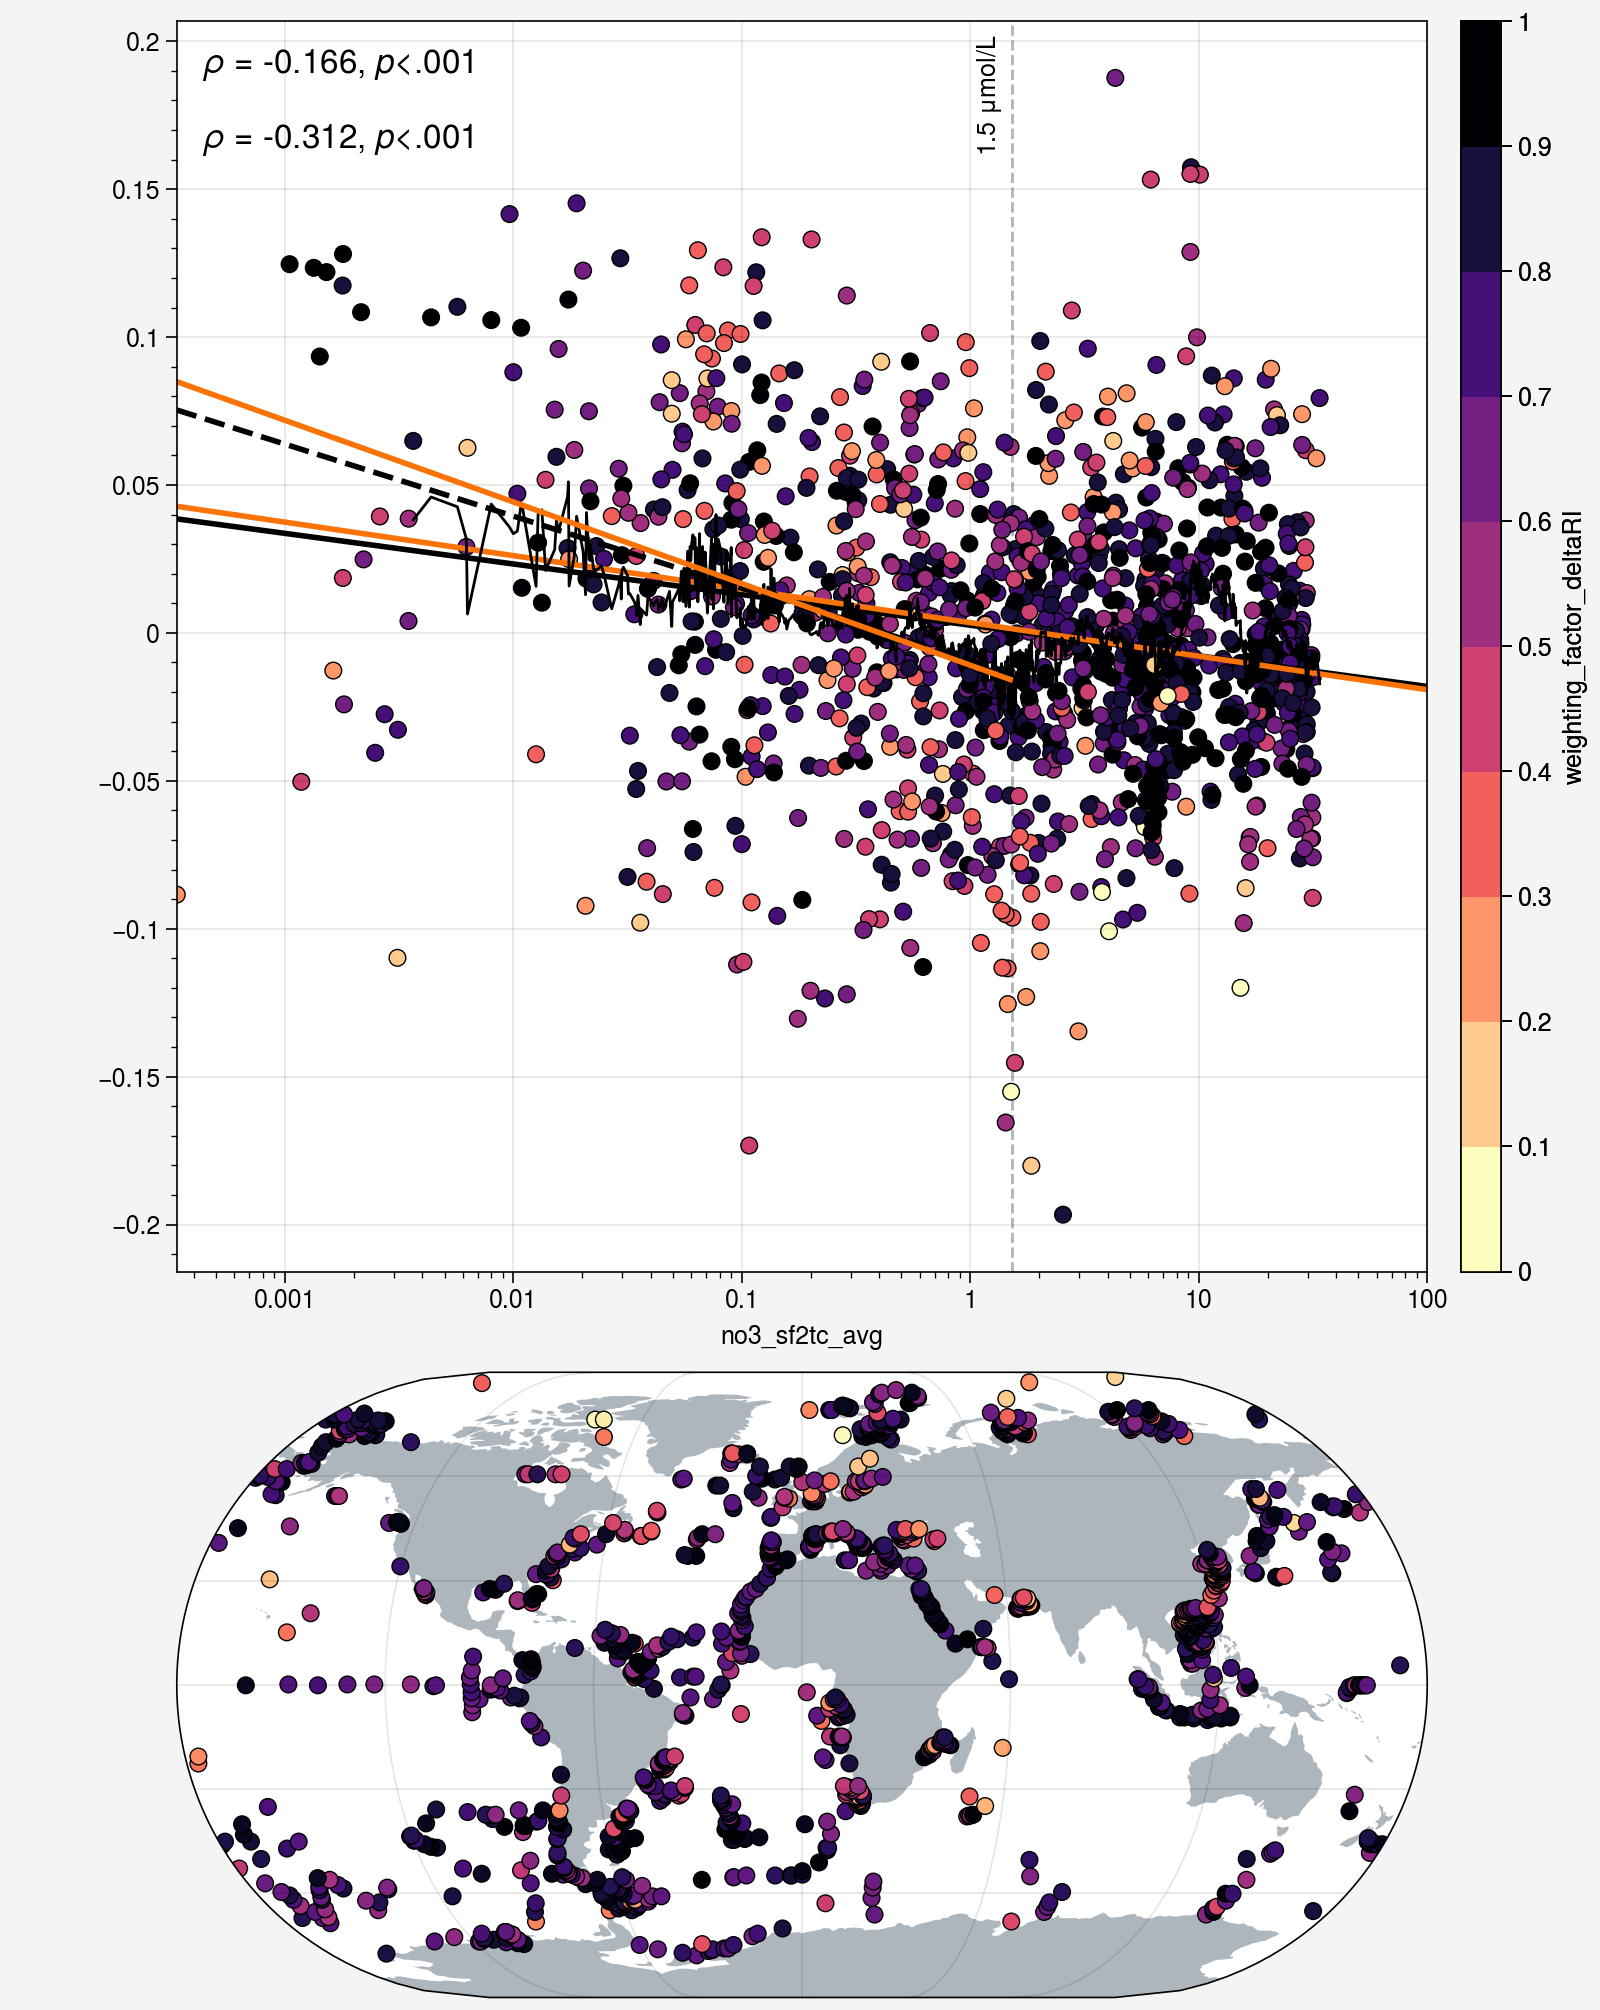

In [23]:
fig, axs = plot.subplots(width=8,nrows=2,
                         proj=(None,'eck3'),
                         hratios=[1,0.5])
ax = axs[0]
test_data['zhang16_texRI'] = -0.77 * test_data['tex_median'] + 3.1517 * test_data['tex_median']**2 + 1.59
test_data['deltaRI'] = test_data['zhang16_texRI'] - test_data['scaledRI_median']*4
test_data['new_pred_texRI'] = test_data['tex_median'] * 3.1517 + 0.5808
test_data['new_deltaRI'] = test_data['scaledRI_median']*4 - test_data['new_pred_texRI']
test_data['weighting_factor_deltaRI'] = 1 - min_max_normalization(abs(test_data['new_deltaRI']))
test_data['weighting_factor_deltaRI_binned'] = pd.cut(test_data['weighting_factor_deltaRI'],bins=[0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0], include_lowest=True)
test_data['weighting_factor_deltaRI_binned_midpoint'] = test_data['weighting_factor_deltaRI_binned'].apply(lambda x: x.mid if x is not None else None)

### create mkrsize_dict for weighting factor
wf_bins = np.arange(0.05, 1.05, 0.05)[::-1]
weights = np.linspace(10, 150, len(wf_bins))
mkrsize_dict = dict(zip(wf_bins, weights))

# reg_idx = abs(test_data['new_deltaRI']) < 0.1
reg_idx = abs(y_res) < 1
sel_x_param = 'no3_sf2tc_avg' # 'thermocline_nitrate_depthIntegral'or 'no3_sf2tc_avg'
reg_X = test_data[sel_x_param][reg_idx]
reg_y_res = y_res[reg_idx]
sel_c_param = 'weighting_factor_deltaRI'#'new_deltaRI' # 'new_deltaRI' # 'lat' or 'Latitude'
reg_c = test_data[sel_c_param][reg_idx]

plot_c = test_data[sel_c_param][reg_idx]
m = ax.scatter(reg_X, reg_y_res, m='o', c=plot_c,
               cmap='magma_r',
               mec='k',mew=0.5,
               levels=10
        #        markersize=[
        #                mkrsize_dict.get(test_data['weighting_factor_deltaRI_binned_midpoint'][reg_idx][i], 10) 
        #                for i in range(len(test_data['weighting_factor_deltaRI_binned_midpoint'][reg_idx]))],
        #        levels=np.arange(-0.6, 0.61, 0.1),
               )
ax.colorbar(m, label=sel_c_param,
            loc='r')

### linear regression on residuals
model = LinearRegression()

reg_ln_xx = np.log10(reg_X)  # Avoid log(0)
nonnan_idx = ~np.isnan(reg_ln_xx) & ~np.isnan(reg_y_res)
model.fit(reg_ln_xx[nonnan_idx].values.reshape(-1, 1), reg_y_res[nonnan_idx])

xx = np.linspace(-4,2,100)
pred_y = model.predict(xx.reshape(-1, 1))
ax.plot(10**xx, pred_y, color='k', lw=2, label='linear regression (sklearn)',)

### rho and p-value
rho, pval = spearmanr(reg_ln_xx[nonnan_idx], reg_y_res[nonnan_idx])
ax.text(0.02, 0.98, r'$\it{\rho}$ = ' + f'{rho:.3f}, {label_pvalues(pval)}',
        transform=ax.transAxes, fontsize=12, 
        ha='left', va='top')

sel_x_param = 'no3_sf2tc_avg' #'thermocline_nitrate_depthIntegral' or 'no3_sf2tc_avg'
sel_y_param = 'scaledRI_median' # 'scaledRI_residuals' or 'scaledRI_median'

### linear fit with weighting factor
weighting_factor = test_data['weighting_factor_deltaRI'][reg_idx]
model_weighted = LinearRegression()
reg_ln_xx_weighted = np.log10(reg_X[weighting_factor > 0])
nonnan_idx_weighted = ~np.isnan(reg_ln_xx_weighted) & ~np.isnan(reg_y_res[weighting_factor > 0])
model_weighted.fit(reg_ln_xx_weighted[nonnan_idx_weighted].values.reshape(-1, 1),
                   reg_y_res[weighting_factor > 0][nonnan_idx_weighted],
                   sample_weight=weighting_factor[weighting_factor > 0][nonnan_idx_weighted])
pred_y_weighted = model_weighted.predict(xx.reshape(-1, 1))
ax.plot(10**xx, pred_y_weighted, color='orange', lw=2, label='weighted linear regression (sklearn)')
## 

### linear fit between log(nitrate) and TEX residuals
plot_data = pd.DataFrame({
    sel_x_param: reg_X,
    sel_y_param: reg_y_res,
    'weighting_factor_deltaRI': weighting_factor,
})
pre_reg_data = plot_data
pre_reg_data = pre_reg_data.sort_values(by=sel_x_param).reset_index(drop=True)

### determine best window size
window_size_fig1 = np.arange(5,101,1)
score_list_fig1 = []
pval_list_fig1 = []
for sel_window_size in window_size_fig1:
        log_x, y_running_mean = running_mean_log10(pre_reg_data[sel_x_param],pre_reg_data[sel_y_param],sel_window_size,
                                           weights=pre_reg_data['weighting_factor_deltaRI']
                                           )
        lowno3_threshold_tmp = 10**log_x[y_running_mean.idxmin()]
        reg_data = pre_reg_data[pre_reg_data[sel_x_param]<lowno3_threshold_tmp]
        rho, pval = spearmanr(reg_data[sel_x_param],reg_data[sel_y_param])
        score_list_fig1.append(rho)
        pval_list_fig1.append(pval)
        # print(f'window size = {sel_window_size}, rho = {rho:.3f}, pval = {pval:.3f}')
best_window_size = window_size_fig1[np.nanargmin(score_list_fig1)]
# best_window_size = 100
print(f'best_window_size = {best_window_size}')
### find x value with minimum running mean of y
log_x, y_running_mean = running_mean_log10(pre_reg_data[sel_x_param],pre_reg_data[sel_y_param],best_window_size,
                                           weights=pre_reg_data['weighting_factor_deltaRI']
                                           )
ax.axvline(10**log_x[y_running_mean.idxmin()],color='gray5',ls='--',lw=1,zorder=0)
lowno3_threshold = np.round(10**log_x[y_running_mean.idxmin()],decimals=1)
ax.text(lowno3_threshold-0.1,0.99,f'{lowno3_threshold:.1f} $\mu$mol/L',transform=ax.get_xaxis_transform(),
        ha='right',va='top',
        rotation=90)
ax.plot(10**log_x,y_running_mean,c='k',lw=1)

### refit the data with nitrate level below the threshold
reg_data = pre_reg_data[pre_reg_data[sel_x_param]<lowno3_threshold].reset_index(drop=True)
model = LinearRegression()
reg_ln_xx = np.log10(reg_data[sel_x_param])  # Avoid log(0)
nonnan_idx = ~np.isnan(reg_ln_xx) & ~np.isnan(reg_data[sel_y_param])
model.fit(reg_ln_xx[nonnan_idx].values.reshape(-1, 1), reg_data[sel_y_param][nonnan_idx])
pred_y = model.predict(np.log10(reg_data[sel_x_param]).values.reshape(-1, 1))
ax.plot(reg_data[sel_x_param], pred_y, color='k', ls='--', lw=2, label='linear regression (sklearn)')

## refit with weighting factor
weighting_factor = reg_data['weighting_factor_deltaRI']
model_weighted = LinearRegression()
reg_ln_xx_weighted = np.log10(reg_data[sel_x_param][weighting_factor > 0])  # Avoid log(0)
nonnan_idx_weighted = ~np.isnan(reg_ln_xx_weighted) & ~np.isnan(reg_data[sel_y_param][weighting_factor > 0])
model_weighted.fit(reg_ln_xx_weighted[nonnan_idx_weighted].values.reshape(-1, 1),
                   reg_data[sel_y_param][weighting_factor > 0][nonnan_idx_weighted],
                   sample_weight=weighting_factor[weighting_factor > 0][nonnan_idx_weighted])
pred_y_weighted = model_weighted.predict(np.log10(reg_data[sel_x_param]).values.reshape(-1, 1))
ax.plot(reg_data[sel_x_param], pred_y_weighted, color='orange', lw=2, label='weighted linear regression (sklearn)')

rho, pval = spearmanr(reg_ln_xx[nonnan_idx], reg_data[sel_y_param][nonnan_idx])
ax.text(0.02, 0.92, r'$\it{\rho}$ = ' + f'{rho:.3f}, {label_pvalues(pval)}',
        transform=ax.transAxes, fontsize=12, c='k',
        ha='left', va='top')

# ## median ols fit
# from statsmodels.regression.quantile_regression import QuantReg
# model_ols = QuantReg(reg_data[sel_y_param], np.log10(reg_data[sel_x_param]))
# res_ols = model_ols.fit(q=0.5)
# pred_y_ols = res_ols.predict(np.log10(reg_data[sel_x_param]))
# ax.plot(reg_data[sel_x_param], pred_y_ols, color='gray5', lw=2, label='median OLS fit')

# reg_data2 = pre_reg_data[pre_reg_data[sel_x_param].between(0.1,lowno3_threshold)].reset_index(drop=True)
# model2 = LinearRegression()
# reg_ln_xx2 = np.log10(reg_data2[sel_x_param])  # Avoid log(0)
# nonnan_idx2 = ~np.isnan(reg_ln_xx2) & ~np.isnan(reg_data2[sel_y_param])
# model2.fit(reg_ln_xx2[nonnan_idx2].values.reshape(-1, 1), reg_data2[sel_y_param][nonnan_idx2])
# xx2 = np.linspace(0.0001, lowno3_threshold, 100)
# pred_y2 = model2.predict(np.log10(xx2).reshape(-1, 1))
# ax.plot(xx2, pred_y2, color='orange', lw=2, label='linear regression (sklearn) for low NO3')

# rho2, pval2 = spearmanr(reg_ln_xx2[nonnan_idx2], reg_data2[sel_y_param][nonnan_idx2])
# ax.text(0.02, 0.86, r'$\it{\rho}$ = ' + f'{rho2:.3f}, {label_pvalues(pval2)}',
#         transform=ax.transAxes, fontsize=12, c='orange',
#         ha='left', va='top')

# reg_data_NH = pre_reg_data[pre_reg_data[sel_x_param]<lowno3_threshold][
#         pre_reg_data['lat']>0].reset_index(drop=True)
# model_NH = LinearRegression()
# reg_ln_xx_NH = np.log10(reg_data_NH[sel_x_param])  # Avoid log(0)
# nonnan_idx_NH = ~np.isnan(reg_ln_xx_NH) & ~np.isnan(reg_data_NH[sel_y_param])
# model_NH.fit(reg_ln_xx_NH[nonnan_idx_NH].values.reshape(-1, 1), reg_data_NH[sel_y_param][nonnan_idx_NH])
# pred_y = model_NH.predict(np.log10(reg_data_NH[sel_x_param]).values.reshape(-1, 1))
# ax.plot(reg_data_NH[sel_x_param], pred_y, color='blue', lw=2, label='linear regression (NH)')

# rho_NH, pval_NH = spearmanr(reg_ln_xx_NH[nonnan_idx_NH], reg_data_NH[sel_y_param][nonnan_idx_NH])
# ax.text(0.02, 0.80, r'$\it{\rho}$ = ' + f'{rho_NH:.3f}, {label_pvalues(pval_NH)}',
#         transform=ax.transAxes, fontsize=12, c='blue',
#         ha='left', va='top')

ax.format(
    xscale='log',
    yreverse=False,
    xreverse=False,)

ax = axs[1]
ax.format(land=True,landcolor='gray5', landzorder=0)

plot_lat = test_data['lat'][reg_idx]
plot_lon = test_data['lon'][reg_idx]
ax.scatter(plot_lon, plot_lat, c=plot_c,
           cmap='magma_r',
           m='o', mec='k', mew=0.5)

In [24]:
# fig, axs = plot.subplots(ncols=3,nrows=5)

# features = [
#     'regionName','lat','modernWaterDepth','thermocline_depth',
#     'fGDGT_0', 'fGDGT_1', 'fGDGT_2', 
#     'fGDGT_3', 'fGDGT_cren', 'fGDGT_cren_prime',
#     'BIT','methaneIndex','gdgt23ratio','gdgtZeroOverZeroCren'
       
# ]
# for i, feature in enumerate(features):
#     ax = axs[i]

#     if feature == 'regionName':
#         continue
#     else:
#         reg_idx = y_res < 0.2
#         sel_x_param = 'no3_sf2tc_avg' # 'thermocline_nitrate_depthIntegral' #'no3_sf2tc_avg'
#         sel_c_param = feature
#         reg_X = test_data[sel_x_param][reg_idx]
#         reg_y_res = y_res[reg_idx]
#         reg_lat = test_data[sel_c_param][reg_idx]

#         plot_c = test_data[sel_c_param][reg_idx]
#         m = ax.scatter(reg_X, reg_y_res, m='o', c=plot_c,
#                     cmap='viridis',mec='k',
#                     levels=10 if feature != 'BIT' else np.linspace(0, 0.5, 11))
#         ax.colorbar(m,loc='r')

#         ax.format(
#             ultitle=feature,
#             xscale='log',
#             yreverse=False,
#             xreverse=False,)    

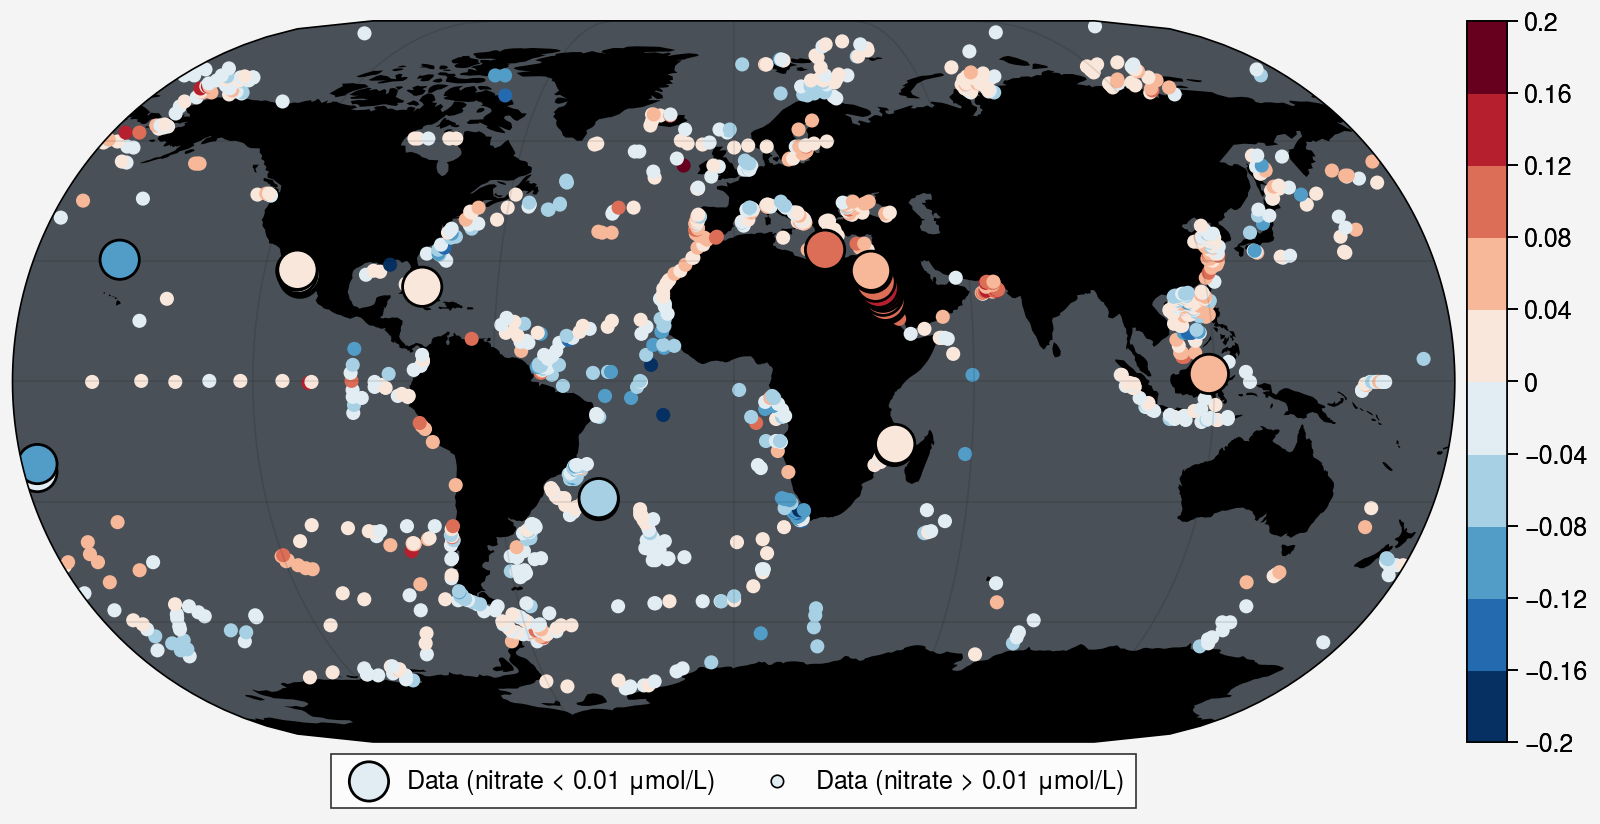

In [25]:
import cartopy.crs as ccrs

fig, axs = plot.subplots(proj='eck3',width=8)
axs.format(
    land=True, landzorder=0,
    facecolor='gray7'
)

test_data['scaledRI_res'] = y_res

plot_data = test_data[test_data['no3_sf2tc_avg']<.01]
ax = axs[0]
m = ax.scatter(
    plot_data['lon'], plot_data['lat'],
    c=plot_data['scaledRI_res'], s=200, 
    cmap='RdBu_r', levels=np.linspace(-0.2, 0.2, 11),
    edgecolor='k', edgewidth=1,
    transform=ccrs.PlateCarree(),
    zorder=2,
    label='Data (nitrate < 0.01 $\mu$mol/L)'
)

ax.colorbar(m,loc='r')

plot_data2 = test_data[test_data['no3_sf2tc_avg']>.01]
ax.scatter(
    plot_data2['lon'], plot_data2['lat'],
    c=plot_data2['scaledRI_res'], s=20,
    cmap='RdBu_r', levels=np.linspace(-0.2, 0.2, 11),
    transform=ccrs.PlateCarree(),
    zorder=1,
    label='Data (nitrate > 0.01 $\mu$mol/L)'
    
)

h, l = ax.get_legend_handles_labels()
ax.legend(
    h, l, loc='b',c='k'
)

In [26]:
raw_coretop_df.columns

Index(['sampleID', 'index_column', 'core_name', 'core_type',
       'sample_depth_start', 'sample_depth_end', 'Latitude', 'Longitude',
       'modernWaterDepth', 'TEX86', 'fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3',
       'fGDGT_cren', 'fGDGT_cren_prime', 'BIT', 'publicationYear',
       'reference_name', 'remark', 'reference_link', 'dataset_DOI',
       'ringIndex', 'scaledRI', 'gdgt23ratio', 'methaneIndex',
       'gdgtZeroOverZeroCren', 'TEX_RI', 'deltaRI', 'QC_flag', 'match_lat',
       'match_lon', 'match_depth', 'SST', 'thermocline_depth', 'thermocline_T',
       'thermocline_T_depthIntegral', 'SSN', 'thermocline_nitrate',
       'thermocline_nitrate_depthIntegral', 'region_ID', 'regionName',
       'mahalanobis_distance', 'mahalanobis_distance_weights',
       'mahalanobis_outlier', 'deltaRI_group', 'pred_new_texRI',
       'new_deltaRI'],
      dtype='object')

Hu2012
SinnigheDamste2016
Trommer2009
Varma2024
this study


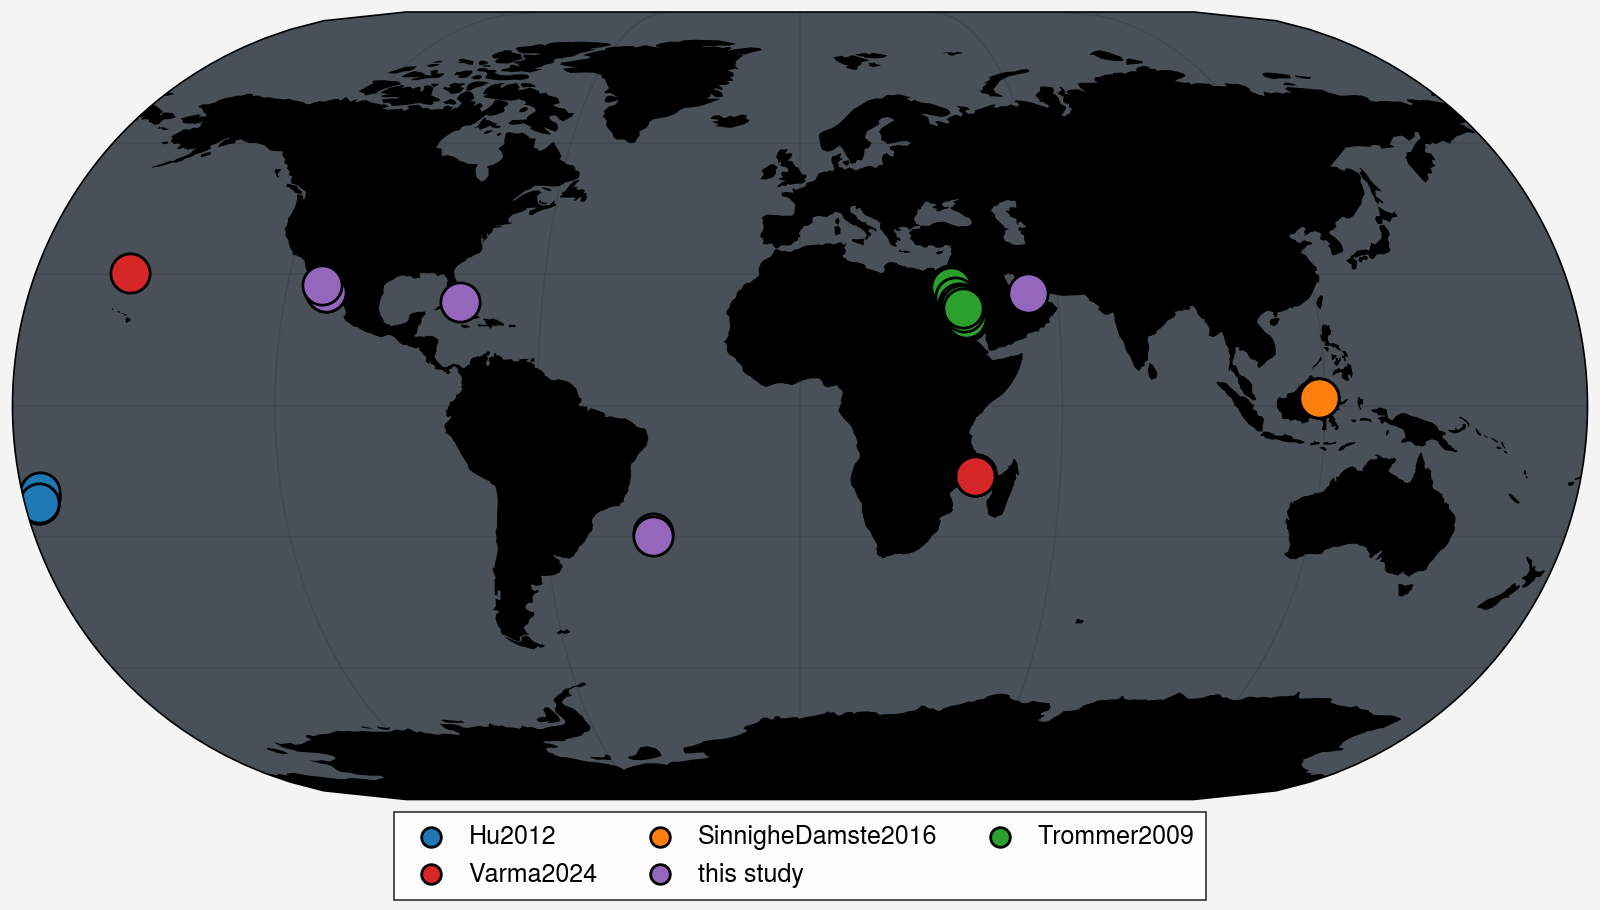

In [27]:

plot_data = raw_coretop_df[raw_coretop_df['thermocline_nitrate_depthIntegral'] < 0.01][raw_coretop_df['new_deltaRI']<0]
grouped = plot_data.groupby('reference_name')

fig, axs = plot.subplots(proj='eck3', width=8)
axs.format(
    land=True, landzorder=0,
    facecolor='gray7'
)

ax = axs[0]
for name, group in grouped:
    ax.scatter(
        group['Longitude'], group['Latitude'],
        s=200,cycle='tab10',
        edgecolor='k', edgewidth=1,
        transform=ccrs.PlateCarree(),
        zorder=2,
        label=name
    )
    print(name)
    
h, l = ax.get_legend_handles_labels()
ax.legend(
    h, l, loc='b', s=50
)

['t0_culmeso', 'k_culmeso', 'b_culmeso', 't0_crtp', 'k_crtp', 'b_crtp', 'beta0_gdgt23ratio_crtp', 'sigma_t0_culmeso', 'sigma_k_culmeso', 'sigma_b_culmeso', 'sigma_scaledRI_cul', 'sigma_scaledRI_meso', 'sigma_scaledRI_crtp']
(4000, 1354)


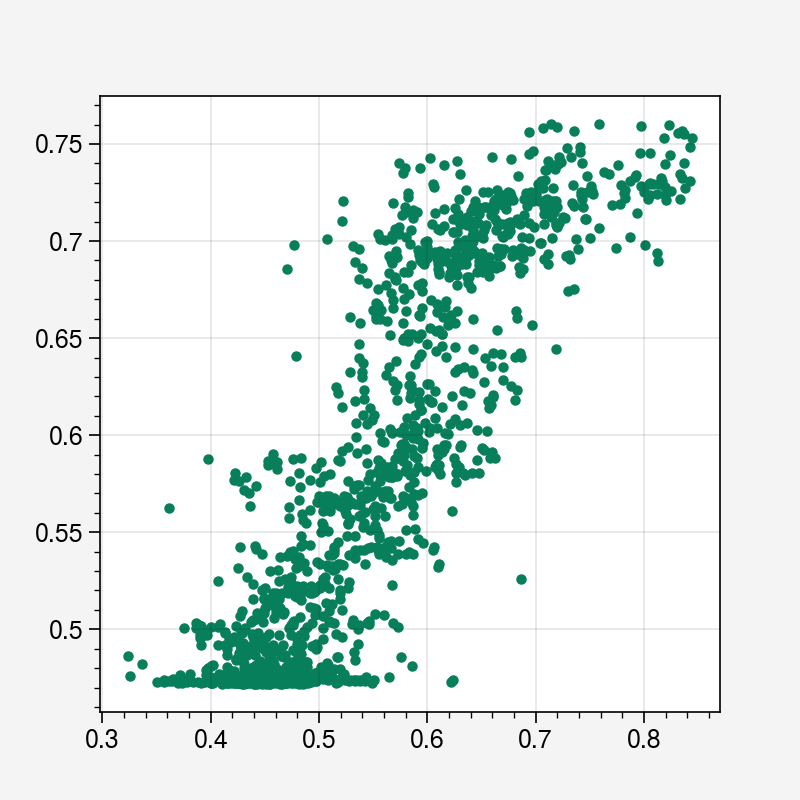

In [28]:
post_ds = culRIB.load_posterior('jnt_cul_meso_hier_crtp_multiv_thermoT_gdgt23ratio')
my_list = list(post_ds.keys())
print(my_list)

popt_name = list(post_ds.data_vars)

# Pull parameters if they exist
t0_crtp = post_ds['t0_crtp'].values
k_crtp = post_ds['k_crtp'].values
b_crtp = post_ds['b_crtp'].values

beta0_gdgt23ratio = post_ds['beta0_gdgt23ratio'].values if 'beta0_gdgt23ratio' in post_ds else np.zeros_like(t0_crtp)
beta0_no3 = post_ds['beta0_no3'].values if 'beta0_no3' in post_ds else np.zeros_like(t0_crtp)


plot_data = coretop_df
n_draws = t0_crtp.shape[0]
n_points = plot_data.shape[0]

# Temperature, NO3, and gdgt23ratio values for prediction
t_pred = plot_data['t_sf2tc_avg'].values[None, :]  # (1, n_points)
g23r_pred = plot_data['gdgt23ratio_median'].values[None, :]
no3_pred = plot_data['no3_sf2tc_avg'].values[None, :]

# Logistic coretop prediction
logistic_part = logistic_fixed_upper(
    t=t_pred,                     # (1, n_points)
    t0=t0_crtp[:, None],          # (n_draws, 1)
    k=k_crtp[:, None],
    b=b_crtp[:, None]
)                                 # Result: (n_draws, n_points)

# Add linear terms (broadcasting to (n_draws, n_points))
pred_scaledRI_ensemble = (
    logistic_part
    + beta0_gdgt23ratio[:, None] * g23r_pred
    + beta0_no3[:, None] * no3_pred
)

print(np.shape(pred_scaledRI_ensemble))
plot_y = np.percentile(pred_scaledRI_ensemble, 50, axis=0)
plt.scatter(plot_data['scaledRI_median'], plot_y, c='teal9', s=10, label='P50 prediction')

# Paleo-data plotting

In [29]:
fpath = fr'{local_github_path}/spreadsheets/fitted_models'
fname = 'ols_tex_thermoT_thisStudy.pkl'

import pickle

with open(os.path.join(fpath,fname), 'rb') as f:
    ols_tex_thermoT = pickle.load(f)
    
slope = ols_tex_thermoT.coef_[0]
intercept = ols_tex_thermoT.intercept_

fpath = fr'{local_github_path}/spreadsheets/published_data'
fname = 'PhanSST_v001.csv'
PhanSST_df = pd.read_csv(os.path.join(fpath,fname))
PhanSST_df['pubYear'] = PhanSST_df['LeadAuthor'] + PhanSST_df['Year'].astype(str)

In [30]:
PhanTEX_df = PhanSST_df[PhanSST_df['ProxyType']=='tex'].reset_index(drop=True)
PhanTEX_df = PhanTEX_df.rename(columns={'ProxyValue':'TEX86',
                                        'GDGT0':'fGDGT_0',
                                        'GDGT1':'fGDGT_1',
                                        'GDGT2':'fGDGT_2',
                                        'GDGT3':'fGDGT_3',
                                        'Cren':'fGDGT_cren',
                                        'Crenisomer':'fGDGT_cren_prime'})
PhanTEX_df = PhanTEX_df.dropna(subset=['fGDGT_0','fGDGT_1','fGDGT_2','fGDGT_3','fGDGT_cren','fGDGT_cren_prime']).reset_index(drop=True)


features = ['fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3','fGDGT_cren', 'fGDGT_cren_prime']
PhanTEX_df['ringIndex'] = np.array([PhanTEX_df[features[i]]*ringNumbers_dict_zhang16.get(features[i]) for i in range(len(features))]).sum(axis=0)
PhanTEX_df['scaledRI'] = PhanTEX_df['ringIndex'] / 4
PhanTEX_df['gdgt23ratio'] = PhanTEX_df['fGDGT_2'] / PhanTEX_df['fGDGT_3']

PhanTEX_df['thermoT_linear'] = (PhanTEX_df['TEX86'] - intercept)/slope
PhanTEX_df['SST_Schouten02'] = predictSSTfromTEX(PhanTEX_df['TEX86'],method_name='schouteN_meso002')
PhanTEX_df['SST_Kim10'] = predictSSTfromTEX(PhanTEX_df['TEX86'],method_name='kim2010_tex86H')
PhanTEX_df

,SampleID,SiteName,SiteHole,MBSF,MCD,SampleDepth,Formation,Country,ContinentOcean,ModLat,...,Year,PublicationDOI,DataDOI,pubYear,ringIndex,scaledRI,gdgt23ratio,thermoT_linear,SST_Schouten02,SST_Kim10
0,NaN,Aderet 1,NaN,NaN,NaN,265.30,NaN,Israel,as,31.65,...,2013,https://doi.org/10.1016/j.palaeo.2013.09.013,NaN,Alsenz2013,2.692752,0.673188,2.975410,30.333373,28.061152,28.043613
1,NaN,Aderet 1,NaN,NaN,NaN,268.20,NaN,Israel,as,31.65,...,2013,https://doi.org/10.1016/j.palaeo.2013.09.013,NaN,Alsenz2013,2.676383,0.669096,2.711864,32.086507,29.491964,28.939558
2,NaN,Aderet 1,NaN,NaN,NaN,271.60,NaN,Israel,as,31.65,...,2013,https://doi.org/10.1016/j.palaeo.2013.09.013,NaN,Alsenz2013,2.792211,0.698053,2.599119,30.764599,28.413095,28.266512
3,NaN,Aderet 1,NaN,NaN,NaN,274.59,NaN,Israel,as,31.65,...,2013,https://doi.org/10.1016/j.palaeo.2013.09.013,NaN,Alsenz2013,2.877008,0.719252,3.118881,31.479751,28.996763,28.632522
4,NaN,Aderet 1,NaN,NaN,NaN,277.55,NaN,Israel,as,31.65,...,2013,https://doi.org/10.1016/j.palaeo.2013.09.013,NaN,Alsenz2013,2.626159,0.656540,3.213920,30.576403,28.259500,28.169440
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7849,NaN,Mid-Waipara River,NaN,NaN,NaN,173.75,NaN,New Zealand,au,-43.06,...,2012,https://doi.org/10.1016/j.epsl.2012.06.024,NaN,Hollis2012,3.127375,0.781844,2.472160,36.970684,33.478162,31.301895
7850,NaN,Mid-Waipara River,NaN,NaN,NaN,170.40,NaN,New Zealand,au,-43.06,...,2012,https://doi.org/10.1016/j.epsl.2012.06.024,NaN,Hollis2012,3.028662,0.757166,2.614379,34.248892,31.256785,30.008682
7851,NaN,Mid-Waipara River,NaN,NaN,NaN,167.04,NaN,New Zealand,au,-43.06,...,2012,https://doi.org/10.1016/j.epsl.2012.06.024,NaN,Hollis2012,3.270462,0.817615,2.232558,38.763949,34.941727,32.124169
7852,NaN,Mid-Waipara River,NaN,NaN,NaN,164.81,NaN,New Zealand,au,-43.06,...,2012,https://doi.org/10.1016/j.epsl.2012.06.024,NaN,Hollis2012,3.198866,0.799717,2.287009,38.929990,35.077240,32.199165


In [31]:
PhanAlk_df = PhanSST_df[PhanSST_df['ProxyType']=='uk'].reset_index(drop=True)
PhanAlk_df

,SampleID,SiteName,SiteHole,MBSF,MCD,SampleDepth,Formation,Country,ContinentOcean,ModLat,...,Cren,Crenisomer,BIT,dRI,MI,LeadAuthor,Year,PublicationDOI,DataDOI,pubYear
0,NaN,DEQ161-592,NaN,19.13,NaN,NaN,Yorktown,United States of America,na,36.68,...,NaN,NaN,NaN,NaN,NaN,Dowsett,2017,https://doi.org/10.5066/F7959G1S,NaN,Dowsett2017
1,NaN,DEQ161-592,NaN,20.56,NaN,NaN,Yorktown,United States of America,na,36.68,...,NaN,NaN,NaN,NaN,NaN,Dowsett,2017,https://doi.org/10.5066/F7959G1S,NaN,Dowsett2017
2,NaN,DEQ161-592,NaN,20.97,NaN,NaN,Yorktown,United States of America,na,36.68,...,NaN,NaN,NaN,NaN,NaN,Dowsett,2017,https://doi.org/10.5066/F7959G1S,NaN,Dowsett2017
3,NaN,DEQ161-592,NaN,21.78,NaN,NaN,Yorktown,United States of America,na,36.68,...,NaN,NaN,NaN,NaN,NaN,Dowsett,2017,https://doi.org/10.5066/F7959G1S,NaN,Dowsett2017
4,NaN,DEQ161-592,NaN,22.09,NaN,NaN,Yorktown,United States of America,na,36.68,...,NaN,NaN,NaN,NaN,NaN,Dowsett,2017,https://doi.org/10.5066/F7959G1S,NaN,Dowsett2017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35355,NaN,SdrVdium,NaN,244.50,214.5,NaN,NaN,NaN,at,55.15,...,NaN,NaN,NaN,NaN,NaN,Herbert,2020,https://doi.org/10.1029/2020PA003935,NaN,Herbert2020
35356,NaN,SdrVdium,NaN,260.50,230.5,NaN,NaN,NaN,at,55.15,...,NaN,NaN,NaN,NaN,NaN,Herbert,2020,https://doi.org/10.1029/2020PA003935,NaN,Herbert2020
35357,NaN,SdrVdium,NaN,268.40,238.4,NaN,NaN,NaN,at,55.15,...,NaN,NaN,NaN,NaN,NaN,Herbert,2020,https://doi.org/10.1029/2020PA003935,NaN,Herbert2020
35358,NaN,SdrVdium,NaN,284.80,254.8,NaN,NaN,NaN,at,55.15,...,NaN,NaN,NaN,NaN,NaN,Herbert,2020,https://doi.org/10.1029/2020PA003935,NaN,Herbert2020


# Checking records with both UK37 and TEX86

In [32]:
PhanTEX_df.columns

Index(['SampleID', 'SiteName', 'SiteHole', 'MBSF', 'MCD', 'SampleDepth',
       'Formation', 'Country', 'ContinentOcean', 'ModLat', 'ModLon', 'Age',
       'Period', 'Stage', 'StagePosition', 'Biozone', 'AgeFlag', 'TEX86',
       'ProxyType', 'ValueType', 'DiagenesisFlag', 'Taxon1', 'Taxon2',
       'Taxon3', 'Environment', 'Ecology', 'AnalyticalTechnique', 'CL', 'Mn',
       'Fe', 'Sr', 'Mg', 'Ca', 'Cawtp', 'MgCa', 'SrCa', 'MnSr', 'NBS120c',
       'Durango', 'MaximumCAI', 'ModWaterDepth', 'CleaningMethod', 'fGDGT_0',
       'fGDGT_1', 'fGDGT_2', 'fGDGT_3', 'fGDGT_cren', 'fGDGT_cren_prime',
       'BIT', 'dRI', 'MI', 'LeadAuthor', 'Year', 'PublicationDOI', 'DataDOI',
       'pubYear', 'ringIndex', 'scaledRI', 'gdgt23ratio', 'thermoT_linear',
       'SST_Schouten02', 'SST_Kim10'],
      dtype='object')

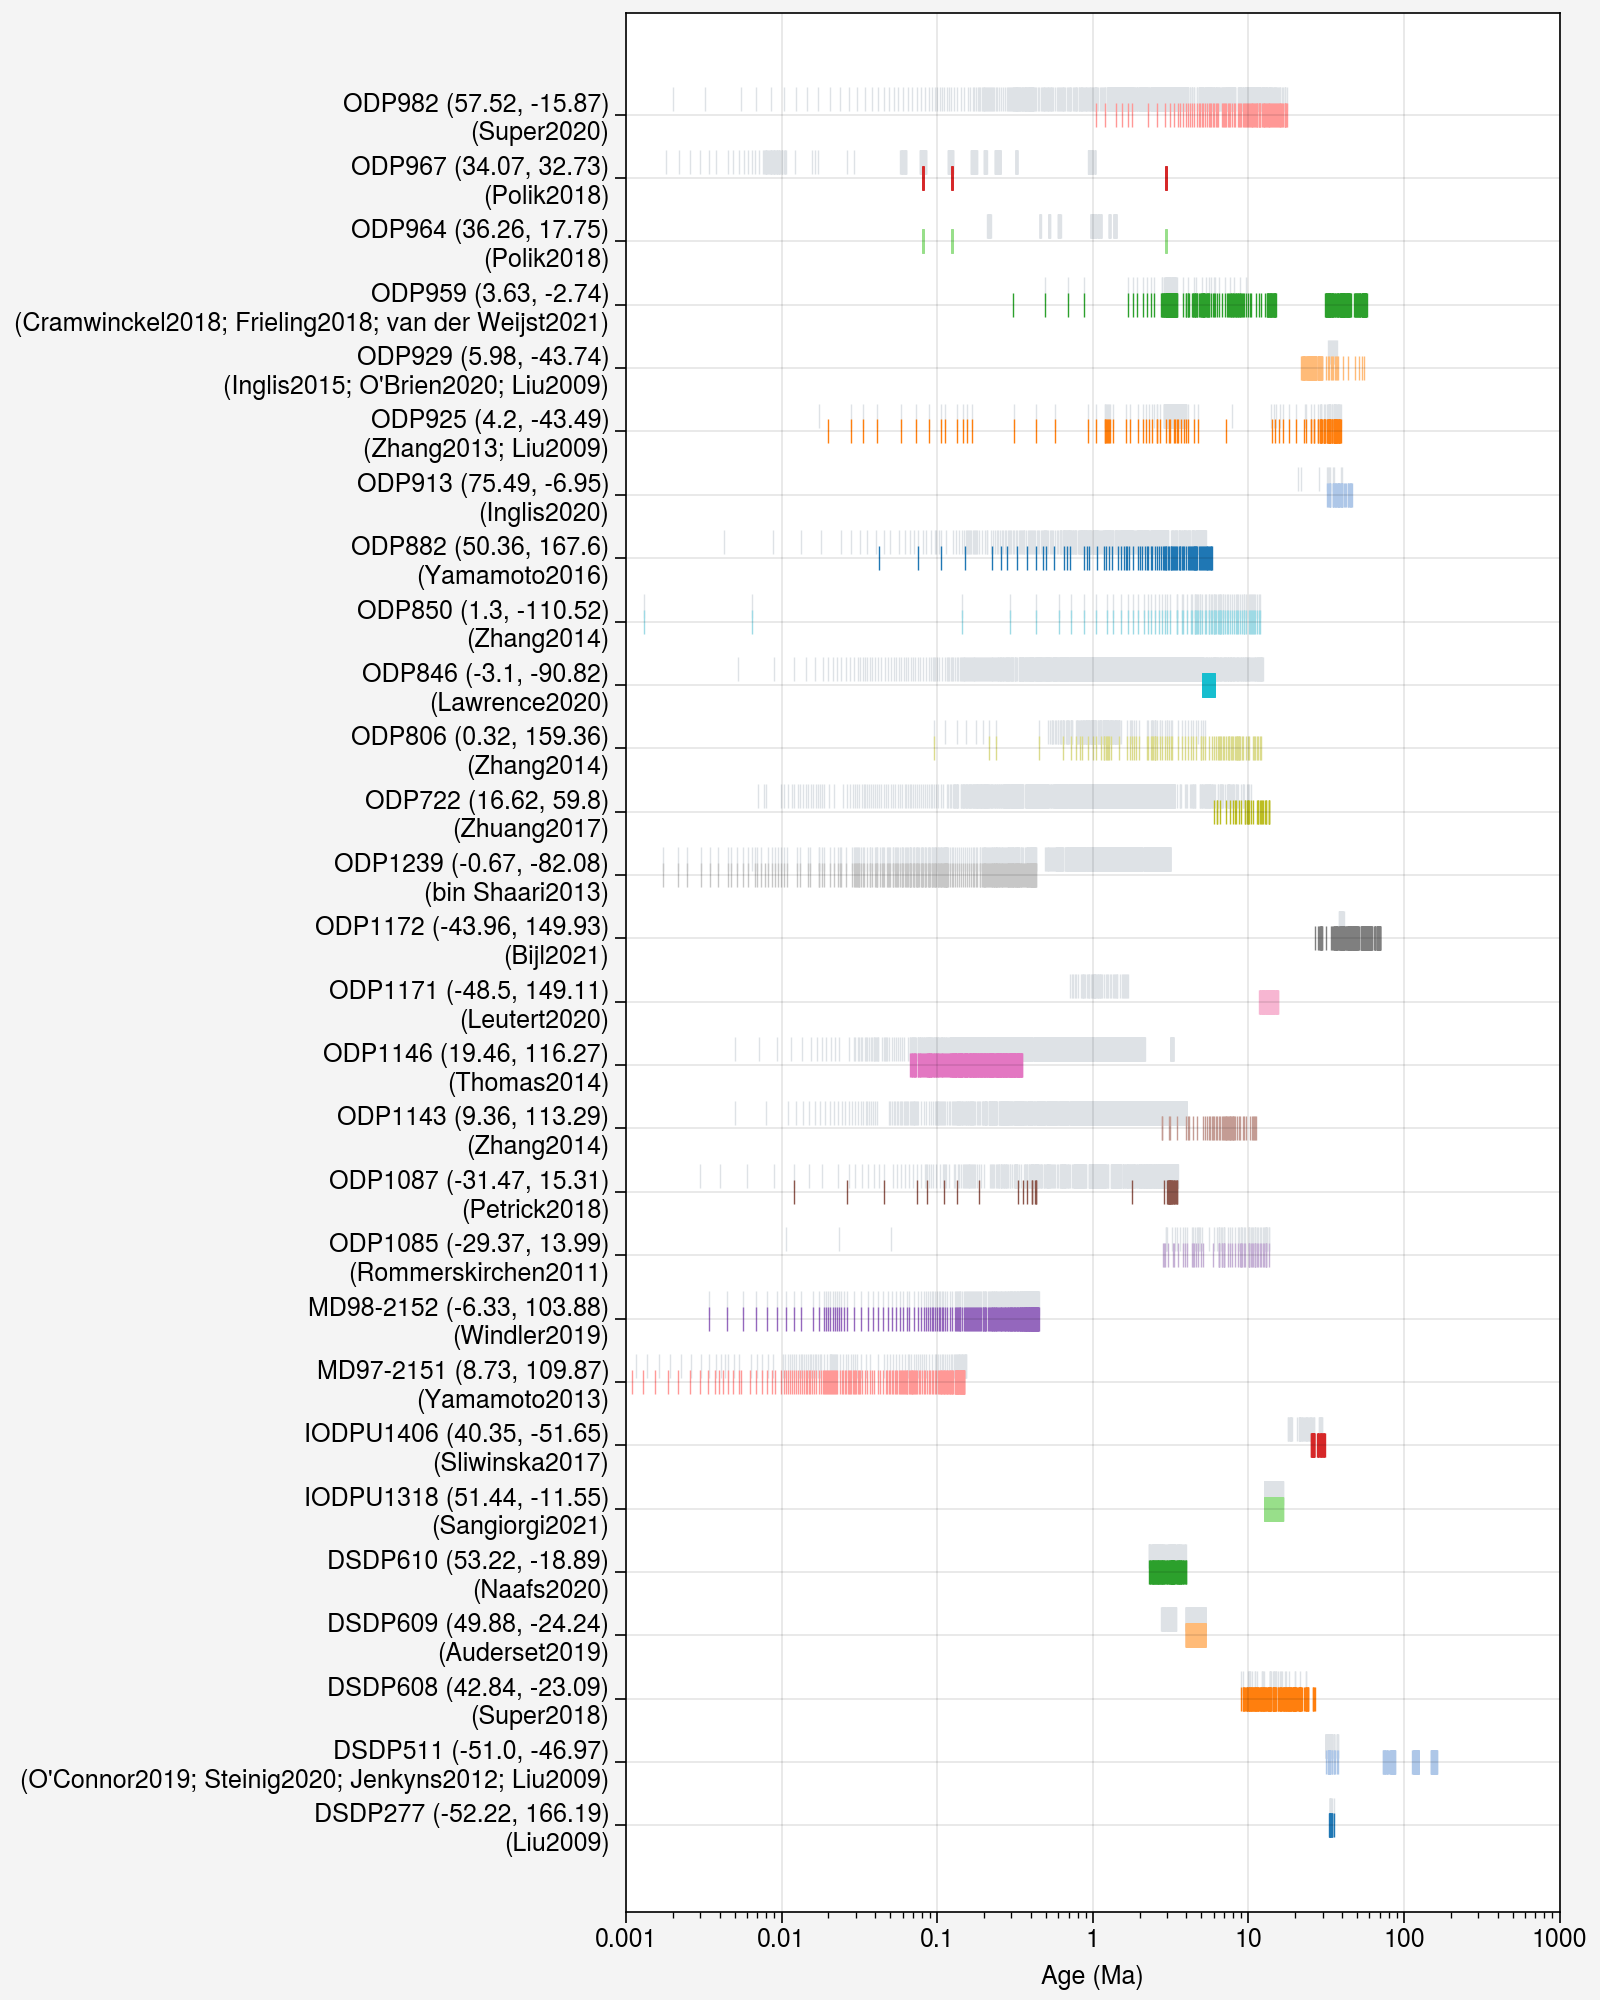

In [33]:
fig, axs = plot.subplots(width=8,height=10)
grouped_tex_df = PhanTEX_df.groupby('SiteName')

ax = axs[0]
jj = 0
y_tick_labels = []
for j, (group_name, group_data) in enumerate(grouped_tex_df):
    if group_name in PhanAlk_df['SiteName'].unique():
        # print(f"Site: {group_name}")
        if not group_data.empty:
            plot_age = group_data['Age'].values
            j_pos_array = np.full_like(plot_age, jj, dtype=float)
            ax.scatter(plot_age, j_pos_array, m='|', s=80, lw=0.5, cycle='tab20')
            
            max_age = group_data['Age'].max()
            site_lat = group_data['ModLat'].unique()[0]
            site_lon = group_data['ModLon'].unique()[0]
            pubYear = group_data['pubYear'].unique()

            label_text = f"{group_name} ({site_lat}, {site_lon})\n({'; '.join([str(year) for year in pubYear])})"
            # group_name + f' ({(site_lat)}, {(site_lon)}) [' + [f'{year};' if len(pubYear) > 1 else f'{year}' for year in pubYear] + ']',
            y_tick_labels.append(label_text)
            # ax.text(max_age+10, jj, 
            #         label_text,
            #         fontsize=8, ha='left', va='center', color='black')
            
        sel_uk_data = PhanAlk_df[PhanAlk_df['SiteName']==group_name]    
        if not sel_uk_data.empty:
            plot_age_uk = sel_uk_data['Age'].values
            j_pos_array_uk = np.full_like(plot_age_uk, jj+0.25, dtype=float)
            ax.scatter(plot_age_uk, j_pos_array_uk, m='|', s=80, lw=0.5, color='gray3', zorder=0)
            
        jj += 1
                
        
ax.format(
    xscale='log',
    xlim=(1e-3, 1e3),
    # xtickrange=(1e-4, 1e4),
    xlabel='Age (Ma)',
    yticklabels=y_tick_labels,
    yticks=np.arange(len(y_tick_labels)),
    ytickminor=False,
)

In [34]:
# ─── prepare sample points ────────────────────────────────────────────────────
xx = np.linspace(-4, 50, 200)

# ─── filter & group your data ──────────────────────────────────────────────────
plot_data = culture_meso_df[culture_meso_df['Temperature'] < 50]
plot_data = plot_data.replace([np.inf, -np.inf], np.nan)  # replace inf with NaN
plot_data = plot_data.dropna(subset=['scaledRI', 'Temperature'])  # drop NaN rows

plot_coretop_data = coretop_df.dropna(subset=['t_sf2tc_avg', 'scaledRI_median']).reset_index(drop=True)

min_count = 2
groups = [g for g, df in plot_data.groupby('Strains_edited') if len(df) >= min_count]

# ─── build the figure with one trace per strain per model ─────────────────────
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=plot_coretop_data['t_sf2tc_avg'],
    y=plot_coretop_data['scaledRI_median'],
    mode='markers',
    marker=dict(color='rgba(178,178,178,1.000)', size=5),
    name='Core-top data',
    showlegend=True   # you can allow toggling it via legend if you like
))
core_idx = 0  # index of this core-top trace

# ─── add global fits ────────────────────────────────────────────────
X_all = plot_data['Temperature'].values.reshape(-1,1)
y_all = plot_data['scaledRI'].values

# -- Linear fit --
ols_all = LinearRegression().fit(X_all, y_all)
y_lin_all = ols_all.predict(xx.reshape(-1,1))


# -- Logistic fixed upper --
p0f = [25, 0.1, 0.1]
bf = (0, [50,1,1])
popt_f_all, _ = curve_fit(logistic_fixed_upper, plot_data['Temperature'], plot_data['scaledRI'], p0=p0f, bounds=bf)
y_logif_all = logistic_fixed_upper(xx, *popt_f_all)
r2_logif_all = 1 - np.var(plot_data['scaledRI'] - logistic_fixed_upper(plot_data['Temperature'], *popt_f_all)) / np.var(plot_data['scaledRI'])

# -- Full logistic --
p0_all = [25,0.1,0.1,0.1]
bnd_all = (0, [50,1,1,1])
popt_all, _ = curve_fit(logistic, plot_data['Temperature'], plot_data['scaledRI'], p0=p0_all, bounds=bnd_all)
y_logi_all = logistic(xx, *popt_all)
r2_logi_all = 1 - np.var(plot_data['scaledRI'] - logistic(plot_data['Temperature'], *popt_all)) / np.var(plot_data['scaledRI'])

## add global fits to figure
for model, y, r2 in [
    ("Linear", y_lin_all, ols_all.score(X_all, y_all)),
    ("Logistic fixed", y_logif_all, r2_logif_all),
    ("Logistic", y_logi_all, r2_logi_all)
]:
    fig.add_trace(go.Scatter(
        x=xx, y=y,
        mode='lines',
        name=f"glob_cul_meso -- {model} (R$^{2}$ = {r2:.3f})",
        visible=True
    ))

### add X_all and y_all with coretop data and fit the glob_cul_meso_crtp
X_all_full = np.concatenate((plot_coretop_data['t_sf2tc_avg'].values.reshape(-1,1), plot_data['Temperature'].values.reshape(-1,1)))
y_all_full = np.concatenate((plot_coretop_data['scaledRI_median'].values, plot_data['scaledRI'].values))

# -- Linear fit --
ols_all_full = LinearRegression().fit(X_all_full, y_all_full)
y_lin_all_full = ols_all_full.predict(xx.reshape(-1,1))
# -- Logistic fixed upper --
p0f_full = [25, 0.1, 0.1]
bf_full = (0, [50,1,1])
popt_f_all_full, _ = curve_fit(logistic_fixed_upper, np.squeeze(X_all_full), y_all_full, p0=p0f_full, bounds=bf_full)
y_logif_all_full = logistic_fixed_upper(xx, *popt_f_all_full)
r2_logif_all_full = 1 - np.var(y_all_full - logistic_fixed_upper(X_all_full, *popt_f_all_full)) / np.var(y_all_full)
# -- Full logistic --
p0_all_full = [25,0.1,0.1,0.1]
bnd_all_full = (0, [50,1,1,1])
popt_all_full, _ = curve_fit(logistic, np.squeeze(X_all_full), y_all_full, p0=p0_all_full, bounds=bnd_all_full)
y_logi_all_full = logistic(xx, *popt_all_full)
r2_logi_all_full = 1 - np.var(y_all_full - logistic(X_all_full, *popt_all_full)) / np.var(y_all_full)
## add global fits to figure
for model, y, r2 in [
    ("Linear", y_lin_all_full, ols_all_full.score(X_all_full, y_all_full)),
    ("Logistic fixed", y_logif_all_full, r2_logif_all_full),
    ("Logistic", y_logi_all_full, r2_logi_all_full)
]:
    fig.add_trace(go.Scatter(
        x=xx, y=y,
        mode='lines',
        name=f"glob_cul_meso_crtp -- {model} (R$^{2}$ = {r2:.3f})",
        visible=True
    ))
    
# ─── add all your strain traces ───────────────────────────
for strain in groups:
    df = plot_data[plot_data['Strains_edited'] == strain]
    X = df['Temperature'].values.reshape(-1,1)
    y = df['scaledRI'].values
    
    # -- Linear fit --
    ols = LinearRegression().fit(X, y)
    y_lin = ols.predict(xx.reshape(-1,1))
    fig.add_trace(go.Scatter(
        x=xx, y=y_lin, 
        mode='lines',
        name=f"{strain} -- Linear (R$^{2}$ = {ols.score(X,y):.3f})",
        visible=(strain == groups[0])  # only first strain visible initially
    ))
    
    # -- Logistic fixed upper --
    p0f = [25, 0.1, 0.1]
    bf = (0, [50,1,1])
    popt_f, _ = curve_fit(logistic_fixed_upper, df['Temperature'], df['scaledRI'], p0=p0f, bounds=bf)
    y_logf = logistic_fixed_upper(xx, *popt_f)
    r2_f = 1 - np.var(df['scaledRI'] - logistic_fixed_upper(df['Temperature'], *popt_f)) / np.var(df['scaledRI'])
    fig.add_trace(go.Scatter(
        x=xx, y=y_logf,
        mode='lines',
        name=f"{strain} -- Logistic fixed (R$^{2}$ = {r2_f:.3f})",
        visible=False
    ))
    
    # -- Full logistic --
    p0 = [25,0.1,0.1,0.1]
    bnd = (0, [50,1,1,1])
    popt, _ = curve_fit(logistic, df['Temperature'], df['scaledRI'], p0=p0, bounds=bnd)
    y_log = logistic(xx, *popt)
    r2 = 1 - np.var(df['scaledRI'] - logistic(df['Temperature'], *popt)) / np.var(df['scaledRI'])
    fig.add_trace(go.Scatter(
        x=xx, y=y_log,
        mode='lines',
        name=f"{strain} -- Logistic (R$^{2}$ = {r2:.3f})",
        visible=False
    ))
    
    # -- Always-on scatter of raw data --
    fig.add_trace(go.Scatter(
        x=df['Temperature'], y=df['scaledRI'],
        mode='markers',
        marker=dict(size=6, line=dict(width=1, color='black')),
        name=f"{strain} -- data",
        visible=True
    ))
# build a mapping strain → color
palette1 = px.colors.qualitative.Set1
palette2 = px.colors.qualitative.Set2

# make one long list
all_colors = palette1 + palette2

# then map strains in order
strain_colors = {
    strain: all_colors[i % len(all_colors)]
    for i, strain in enumerate(groups)
}

# now loop through all traces
for trace in fig.data:
    # The “cultures + mesocosm only” global fit
    if trace.name.startswith("glob_cul_meso --"):
        trace.update(line=dict(
            color="black",   # pick any CSS name or hex code
            dash="solid",        # “solid”, “dash”, “dot”, “dashdot”, etc
            width=4              # thicker line
        ))

    # The “cultures + mesocosm + coretop” global fit
    elif trace.name.startswith("glob_cul_meso_crtp --"):
        trace.update(line=dict(
            color="black",
            dash="dashdot",
            width=3
        ))
        
    # skip the core-top (and any other truly global or background traces)
    elif trace.name == "Core-top data":
        continue

    # split off the strain name (everything before the “ – ”)
    strain = trace.name.split(" -- ")[0]

    # pick a color: if it’s one of our strains, use its palette color;
    # otherwise (e.g. “Global”) fall back to black or whatever you like
    col = strain_colors.get(strain, "black")

    # apply to both marker & line
    trace.update(
        marker=dict(color=col),
        line=dict(color=col)
    )



# Hide all line traces (fits) by default, leave markers visible
for trace in fig.data:
    if "lines" in trace.mode:
        trace.visible = "legendonly"
    else:
        trace.visible = True

# # Make “raw data” the initial visibility state:
# for tr in fig.data:
#     if tr.name == "Core-top data" or tr.name.endswith("-- data"):
#         tr.visible = True
#     else:
#         tr.visible = False
        


# reposition the model‐dropdown as a vertical nav bar on the left
fig.update_layout(

    autosize=False,     # turn off responsive “fill the container”
    width=900,          # fixed pixel width
    height=500,         # fixed pixel height
    margin=dict(l=40, r=40, t=50, b=40),

    title="Scaled RI vs Temperature",
    xaxis_title="Temperature (°C)",
    yaxis_title="Scaled RI",
    
    yaxis=dict(
        range=[0.1, 1.1],
        autorange=False    # turn off auto‐scaling
    ),

    # put the legend also on the left, so users can click each strain on/off
    legend=dict(
        traceorder="normal",
        orientation="v",
        x=1.13,      # just inside the left margin
        y=0.5,
        xanchor="left",
        yanchor="middle",
        itemsizing="constant"
    ),
    template='seaborn',
    font=dict(
        family="TeX Gyre Heros",
        size=14,
        color="black"
    ),
    
)

# lock X/Y so the units match (remove if you don’t want a 1:1 scale)
fig.update_xaxes(constrain='domain')            # keep the X‐axis from expanding

# set a default
# fig.update_layout(template="plotly_white")

fig.show()

# in your Python script / notebook:
fig.write_html(
  os.path.join(local_github_path, 'html_figures', 'scaledRI_vs_Temperature.html'),
  include_plotlyjs="cdn",   # pull Plotly.js from the CDN
  full_html=False           # only the <div>+<script>—no <html>/<body> wrapper
)


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [ ]:
culture_data_full = culture_meso_df[culture_meso_df['Temperature']<50][culture_meso_df['datatype']=='culture']
culture_data_full = culture_data_full.replace([np.inf, -np.inf], np.nan).dropna(subset=['Temperature',
                                                                                        'scaledRI',
                                                                                        'gdgt23ratio']).reset_index(drop=True)
meso_data_full = culture_meso_df[culture_meso_df['Temperature']<50][culture_meso_df['datatype']=='mesocosm']
meso_data_full = meso_data_full.replace([np.inf, -np.inf], np.nan).dropna(subset=['Temperature',
                                                                                'scaledRI',
                                                                                'gdgt23ratio']).reset_index(drop=True)

coretop_df = coretop_df.replace([np.inf, -np.inf],np.nan).dropna(subset=['scaledRI_median',
                                                                         't_sf2tc_avg',
                                                                         'no3_sf2tc_avg',
                                                                         'gdgt23ratio_median']).reset_index(drop=True)
coretop_df = coretop_df[coretop_df['gdgt23ratio_median']<100].reset_index(drop=True)
coretop_df['gdgt23ratio_median'].max()

coretop_df_low23 = coretop_df[coretop_df['gdgt23ratio_median']<5].reset_index(drop=True)
coretop_df_low23

In [ ]:
t_cul = culture_data_full['Temperature'].astype(float).tolist() 
scaledRI_cul = culture_data_full['scaledRI'].astype(float).tolist() 
gdgt23ratio_cul = culture_data_full['gdgt23ratio'].astype(float).tolist()

t_meso = meso_data_full['Temperature'].astype(float).tolist()
scaledRI_meso = meso_data_full['scaledRI'].astype(float).tolist()
gdgt23ratio_meso = meso_data_full['gdgt23ratio'].astype(float).tolist()

t_crtp = coretop_df['t_sf2tc_avg'].astype(float).tolist()
scaledRI_crtp = coretop_df['scaledRI_median'].astype(float).tolist()
gdgt23ratio_crtp = coretop_df['gdgt23ratio_median'].astype(float).tolist()
no3_crtp = coretop_df['no3_sf2tc_avg'].astype(float).tolist()

In [ ]:
WL_paleo_tex_df = PhanTEX_df[PhanTEX_df['SiteName']=='Wilson Lake'].reset_index(drop=True)
search_tolerance = np.std(WL_paleo_tex_df['TEX86'], ddof=1) * 2
WL_paleo_tex_df['SST_bsr'] = bsr.predict_seatemp_analog(WL_paleo_tex_df['TEX86'],
                                                     prior_mean=30, prior_std=6,
                                                     temptype='sst',search_tol=search_tolerance,
                                                     nens=100).percentile(50)
WL_paleo_tex_df['subT_bsr'] = bsr.predict_seatemp_analog(WL_paleo_tex_df['TEX86'],
                                                     prior_mean=30, prior_std=6,
                                                     temptype='subt',search_tol=search_tolerance,
                                                     nens=100).percentile(50)

In [ ]:
fpath = f'{local_github_path}/posterior_cache/jnt_cul_meso_hier_crtp_thermoT.nc'
jnt_cul_meso_hier_crtp_thermoT = xr.open_dataset(fpath)
jnt_cul_meso_hier_crtp_thermoT

# Compare inverse model | ensemble vs meanprior modes

In [ ]:
data, _ = culRIB.build_invT_inputData(
        scaledRI=WL_paleo_tex_df['scaledRI'].astype(float).tolist(),
        prior_mu_t= 35.0,
        prior_sigma_t=6,
        fwd_posterior_name='jnt_cul_meso_hier_crtp_thermoT',
        mode='ensemble'
    )
stan_file_name = 'invT_logistic_fixed_univ'
post_ds, diag = culRIB.get_invT_posterior(data, stan_file_name, 
                                   site_name='WilsonLake',
                                   temptype='thermoT')
post_summ_ds = culRIB.get_invT_post_quantiles(post_ds)
display(post_summ_ds)

culRIB.save_invT_posterior(post_summ_ds)

In [ ]:
data, _ = culRIB.build_invT_inputData(
        scaledRI=WL_paleo_tex_df['scaledRI'].astype(float).tolist(),
        prior_mu_t= 35.0,
        prior_sigma_t=6,
        fwd_posterior_name='jnt_cul_meso_hier_crtp_sst',
        mode='ensemble'
    )
stan_file_name = 'invT_logistic_fixed_univ'
post_sst_ds, diag = culRIB.get_invT_posterior(data, stan_file_name, 
                                   site_name='WilsonLake',
                                   temptype='sst')
post_sst_summ_ds = culRIB.get_invT_post_quantiles(post_sst_ds)
display(post_sst_summ_ds)

culRIB.save_invT_posterior(post_sst_summ_ds)

In [ ]:
data, _ = culRIB.build_invT_inputData(
        scaledRI=WL_paleo_tex_df['scaledRI'].astype(float).tolist(),
        predictors={
            "gdgt23ratio":WL_paleo_tex_df['gdgt23ratio'].astype(float).tolist(), 
        },
        prior_mu_t=35.0,
        prior_sigma_t=6,
        fwd_posterior_name='jnt_cul_meso_hier_crtp_multiv_thermoT_gdgt23ratio',
        mode='ensemble'
    )
stan_file_name = 'invT_logistic_fixed_univ'
post_multiv_ds, diag = culRIB.get_invT_posterior(data, stan_file_name, 
                                   site_name='WilsonLake',
                                   temptype='thermoT_gdgt23ratio')
post_multiv_summ_ds = culRIB.get_invT_post_quantiles(post_multiv_ds)

display(post_multiv_summ_ds)

In [ ]:
data, _ = culRIB.build_invT_inputData(
        scaledRI=WL_paleo_tex_df['scaledRI'].astype(float).tolist(),
        predictors={
            "gdgt23ratio":WL_paleo_tex_df['gdgt23ratio'].astype(float).tolist(), 
        },
        prior_mu_t=35.0,
        prior_sigma_t=6,
        fwd_posterior_name='jnt_cul_meso_hier_crtp_multiv_sst_gdgt23ratio',
        mode='ensemble'
    )
stan_file_name = 'invT_logistic_fixed_univ'
post_sst_multiv_ds, diag = culRIB.get_invT_posterior(data, stan_file_name, 
                                   site_name='WilsonLake',
                                   temptype='sst_gdgt23ratio')
post_sst_multiv_summ_ds = culRIB.get_invT_post_quantiles(post_sst_multiv_ds)

display(post_sst_multiv_summ_ds)

In [ ]:
data, _ = culRIB.build_invT_inputData(
        scaledRI=WL_paleo_tex_df['scaledRI'].astype(float).tolist(),
        prior_mu_t= 35.0,
        prior_sigma_t=6,
        fwd_posterior_name='jnt_cul_meso_hier_crtp_thermoT',
        mode='meanprior_bayes',
        reduction="mean"
    )
stan_file_name = 'invT_logistic_fixed_univ_meanprior_bayes'
post_ds2, diag = culRIB.get_invT_posterior(data, stan_file_name,
                                            site_name='WilsonLake',
                                            temptype='thermoT')
post_summ_ds2 = culRIB.get_invT_post_quantiles(post_ds2)



In [ ]:
data, _ = culRIB.build_invT_inputData(
        scaledRI=WL_paleo_tex_df['scaledRI'].astype(float).tolist(),
        prior_mu_t= 35.0,
        prior_sigma_t=6,
        fwd_posterior_name='jnt_cul_meso_hier_crtp_sst',
        mode='meanprior_bayes',
        reduction="mean"
    )
stan_file_name = 'invT_logistic_fixed_univ_meanprior_bayes'
post_sst_ds2, diag = culRIB.get_invT_posterior(data, stan_file_name,
                                            site_name='WilsonLake',
                                            temptype='sst')
post_sst_summ_ds2 = culRIB.get_invT_post_quantiles(post_sst_ds2)



In [ ]:
data, _ = culRIB.build_invT_inputData(
        scaledRI=WL_paleo_tex_df['scaledRI'].astype(float).tolist(),
        predictors={
            "gdgt23ratio":WL_paleo_tex_df['gdgt23ratio'].astype(float).tolist(), 
        },
        prior_mu_t= 35.0,
        prior_sigma_t=6,
        fwd_posterior_name='jnt_cul_meso_hier_crtp_multiv_thermoT_gdgt23ratio',
        mode='meanprior_bayes',
        reduction="mean"
    )
stan_file_name = 'invT_logistic_fixed_univ_meanprior_bayes'
post_multiv_ds2, diag = culRIB.get_invT_posterior(data, stan_file_name,
                                                  site_name='WilsonLake',
                                                  temptype='thermoT_gdgt23ratio')
post_multiv_summ_ds2 = culRIB.get_invT_post_quantiles(post_multiv_ds2)

display(post_multiv_summ_ds2)


In [ ]:
data, _ = culRIB.build_invT_inputData(
        scaledRI=WL_paleo_tex_df['scaledRI'].astype(float).tolist(),
        predictors={
            "gdgt23ratio":WL_paleo_tex_df['gdgt23ratio'].astype(float).tolist(), 
        },
        prior_mu_t= 35.0,
        prior_sigma_t=6,
        fwd_posterior_name='jnt_cul_meso_hier_crtp_multiv_sst_gdgt23ratio',
        mode='meanprior_bayes',
        reduction="mean"
    )
stan_file_name = 'invT_logistic_fixed_univ_meanprior_bayes'
post_sst_multiv_ds2, diag = culRIB.get_invT_posterior(data, stan_file_name,
                                                  site_name='WilsonLake',
                                                  temptype='sst_gdgt23ratio')
post_sst_multiv_summ_ds2 = culRIB.get_invT_post_quantiles(post_sst_multiv_ds2)

display(post_sst_multiv_summ_ds2)


In [ ]:
data, _ = culRIB.build_invT_inputData(
        scaledRI=WL_paleo_tex_df['scaledRI'].astype(float).tolist(),
        prior_mu_t= 35.0,
        prior_sigma_t=6,
        fwd_posterior_name='jnt_cul_meso_hier_crtp_thermoT',
        mode='meanprior_bayes',
        reduction="median"
    )
stan_file_name = 'invT_logistic_fixed_univ_meanprior_bayes'
post_ds3, diag = culRIB.get_invT_posterior(data, stan_file_name,
                                            site_name='WilsonLake',
                                            temptype='thermoT')
post_summ_ds3 = culRIB.get_invT_post_quantiles(post_ds3)

WL_paleo_tex_df['invT_hier_univ_thermoT'] = post_summ_ds3['t_est'].sel(quantile=0.5).values

In [ ]:
data, _ = culRIB.build_invT_inputData(
        scaledRI=WL_paleo_tex_df['scaledRI'].astype(float).tolist(),
        prior_mu_t= 35.0,
        prior_sigma_t=6,
        fwd_posterior_name='jnt_cul_meso_hier_crtp_sst',
        mode='meanprior_bayes',
        reduction="median"
    )
stan_file_name = 'invT_logistic_fixed_univ_meanprior_bayes'
post_sst_ds3, diag = culRIB.get_invT_posterior(data, stan_file_name,
                                            site_name='WilsonLake',
                                            temptype='sst')
post_sst_summ_ds3 = culRIB.get_invT_post_quantiles(post_sst_ds3)

WL_paleo_tex_df['invT_hier_univ_sst'] = post_sst_summ_ds3['t_est'].sel(quantile=0.5).values

In [ ]:
data, _ = culRIB.build_invT_inputData(
        scaledRI=WL_paleo_tex_df['scaledRI'].astype(float).tolist(),
        predictors={
            "gdgt23ratio":WL_paleo_tex_df['gdgt23ratio'].astype(float).tolist(), 
        },
        prior_mu_t= 35.0,
        prior_sigma_t=6,
        fwd_posterior_name='jnt_cul_meso_hier_crtp_multiv_thermoT_gdgt23ratio',
        mode='meanprior_bayes',
        reduction="median"
    )
stan_file_name = 'invT_logistic_fixed_univ_meanprior_bayes'
post_multiv_ds3, diag = culRIB.get_invT_posterior(data, stan_file_name,
                                                  site_name='WilsonLake',
                                                  temptype='thermoT_gdgt23ratio')
post_multiv_summ_ds3 = culRIB.get_invT_post_quantiles(post_multiv_ds3)

WL_paleo_tex_df['invT_hier_multiv_thermoT_gdgt23ratio'] = post_multiv_summ_ds3['t_est'].sel(quantile=0.5).values

In [ ]:
data, _ = culRIB.build_invT_inputData(
        scaledRI=WL_paleo_tex_df['scaledRI'].astype(float).tolist(),
        predictors={
            "gdgt23ratio":WL_paleo_tex_df['gdgt23ratio'].astype(float).tolist(), 
        },
        prior_mu_t= 35.0,
        prior_sigma_t=6,
        fwd_posterior_name='jnt_cul_meso_hier_crtp_multiv_sst_gdgt23ratio',
        mode='meanprior_bayes',
        reduction="median"
    )
stan_file_name = 'invT_logistic_fixed_univ_meanprior_bayes'
post_sst_multiv_ds3, diag = culRIB.get_invT_posterior(data, stan_file_name,
                                                  site_name='WilsonLake',
                                                  temptype='sst_gdgt23ratio')
post_sst_multiv_summ_ds3 = culRIB.get_invT_post_quantiles(post_sst_multiv_ds3)

WL_paleo_tex_df['invT_hier_multiv_sst_gdgt23ratio'] = post_sst_multiv_summ_ds3['t_est'].sel(quantile=0.5).values

In [ ]:
fig, axs = plot.subplots(ncols=2)

ax = axs[0]
post_sst_ds.quantile(0.5, dim=['draw', 'dim_2']).t_est.plot(ax=ax,c='tab:blue',label='ensemble')
post_sst_multiv_ds.quantile(0.5, dim=['draw', 'dim_2']).t_est.plot(ax=ax,c='tab:blue',ls='--',label='ensemble_multiv')

post_sst_ds2.quantile(0.5, dim=['draw']).t_est.plot(ax=ax,c='tab:orange',label='meanprior_bayes')
post_sst_multiv_ds2.quantile(0.5, dim=['draw']).t_est.plot(ax=ax,c='tab:orange',ls='--',label='meanprior_bayes_multiv')

post_sst_ds3.quantile(0.5, dim=['draw']).t_est.plot(ax=ax,c='tab:green',label='meanprior_bayes_median')
post_sst_multiv_ds3.quantile(0.5, dim=['draw']).t_est.plot(ax=ax,c='tab:green',ls='--',label='meanprior_bayes_median_multiv')

WL_paleo_tex_df['SST_Schouten02'].plot(ax=ax, c='tab:red', label='SST_Schouten02')
WL_paleo_tex_df['SST_Kim10'].plot(ax=ax, c='tab:purple', label='SST_Kim10')
WL_paleo_tex_df['SST_bsr'].plot(ax=ax, c='tab:cyan', label='SST_bsr')

h, l = ax.get_legend_handles_labels()
fig.legend(
    h, l, loc='b',ncols=3
)

ax = axs[1]
post_ds.quantile(0.5, dim=['draw', 'dim_2']).t_est.plot(ax=ax,c='tab:blue',label='ensemble')
post_multiv_ds.quantile(0.5, dim=['draw', 'dim_2']).t_est.plot(ax=ax,c='tab:blue',ls='--',label='ensemble')

post_ds2.quantile(0.5, dim=['draw']).t_est.plot(ax=ax,c='tab:orange',label='meanprior_bayes')
post_multiv_ds2.quantile(0.5, dim=['draw']).t_est.plot(ax=ax,c='tab:orange',ls='--',label='meanprior_bayes')

post_ds3.quantile(0.5, dim=['draw']).t_est.plot(ax=ax,c='tab:green',label='meanprior_bayes_median')
post_multiv_ds3.quantile(0.5, dim=['draw']).t_est.plot(ax=ax,c='tab:green',ls='--',label='meanprior_bayes_median')

WL_paleo_tex_df['subT_bsr'].plot(ax=ax, c='tab:cyan',ls='--', label='SST_bsr')

axs.format(
    ylim=(20,50)
)


In [ ]:
import glob
import re

fpath = f'/mnt/lab/ModelOutput/iCESM/Eoceneclimatologies'
fname = f'b.e12.B1850C5CN.f19_g16.iPETM09x.01.pop.h.1901-2000.climo.nc'

pattern = os.path.join(fpath, '*iPETM*pop.h*.nc')
### find files with iPETM and pop.h in the name
ipetm_re = re.compile(r'iPETM\d+x')

matches = glob.glob(pattern)

for fn in glob.glob(pattern):
    basename = os.path.basename(fn)
    m = ipetm_re.search(basename)
    if m:
        print(m.group(0))   # → iPETM09x
        print(basename)
    else:
        print(f"No iPETM token found in {basename}")
    
    
    ds = xr.open_dataset(fn)
    ds = ds.drop_vars(["ULONG", "ULAT"], errors="ignore")

    ds_TEMP = ds['TEMP']
    ds_TEMP['lat'] = ds_TEMP['TLAT'].copy()
    ds_TEMP['lon'] = ds_TEMP['TLONG'].copy()

    # 1. Define your target grid
    lat_out = np.arange(-90, 90.1, 1.0)
    lon_out = np.arange(0, 360.1, 1.0)
    ds_out = xr.Dataset({
        "lat": (["lat"], lat_out),
        "lon": (["lon"], lon_out),
    })

    # 2. Create the regridder and interpolate
    regridder = xe.Regridder(ds_TEMP, ds_out, "bilinear", periodic=True)
    field_reg = regridder(ds_TEMP)
    field_reg.name = 'TEMP'

    fpath = f'/home/paleolipidrr/Documents/GitHub/culRI-Bayesian/nc_files/Zhu19_Science_EoceneSim/fullDepth_regridded_iPETM'
    fname = f'Zhu19_Science_EoceneSim_fullDepth_regridded_{m.group(0)}.nc'
    
    field_reg.to_netcdf(os.path.join(fpath, fname), mode='w', format='NETCDF4', unlimited_dims='time')
    print(f"Saved regridded data to {os.path.join(fpath, fname)}")

In [ ]:
fpath = fr'{local_github_path}/nc_files/Zhu19_Science_EoceneSim'

fname = 'b.e12.B1850C5CN.f19_g16.iPETM01x.01.pop.h.TEMP.2501-2600.climo.nc'
iPETM_01x_ds = xr.open_dataset(os.path.join(fpath,fname))

fname = 'b.e12.B1850C5CN.f19_g16.iPETM03x.02.pop.h.TEMP.1901-2000.climo.nc'
iPETM_03x_ds = xr.open_dataset(os.path.join(fpath,fname))

fname = 'b.e12.B1850C5CN.f19_g16.iPETM06x.07.pop.h.TEMP.1901-2000.climo.nc'
iPETM_06x_ds = xr.open_dataset(os.path.join(fpath,fname))

fname = 'b.e12.B1850C5CN.f19_g16.iPETM09x.01.pop.h.TEMP.1901-2000.climo.nc'
iPETM_09x_ds = xr.open_dataset(os.path.join(fpath,fname))


In [ ]:
fpath = fr'{local_github_path}/nc_files/Tierney22_PNAS_PETMDA'
fname = 'PETMDA_OCN_annual.nc'
PETMDA_ds = xr.open_dataset(os.path.join(fpath,fname))

prePETMDA_da = PETMDA_ds['sst'].isel(nTime=1).copy()
PETMDA_da = PETMDA_ds['sst'].isel(nTime=0).copy()

display(prePETMDA_da)
display(PETMDA_da)


In [ ]:
WL_paleo_tex_df.columns

In [ ]:
array = [
    [1,2],
    [3,4],
    [5,5],
    [6,6]
]
fig, axs = plot.subplots(array, figsize=(10,12),share=0,
                         hratios=[0.5,0.5,1,0.5],)



### plot iPETM data at 01x and 09x
sel_nlon = 185
sel_nlat = 255
axs[0:4].scatter(sel_nlon,sel_nlat,
                 c='k',marker='o',s=100)

iPETM_01x_ds.mean(dim='time').TEMP.plot(
    ax=axs[0],zorder=0,
    cmap='thermal',levels=np.arange(-5,50,5),
    add_colorbar=False)
axs[0].set_title('iPETM 01x (Zhu et al. 2019 ' + r'$\it{Science}$' + ')')

iPETM_09x_ds.mean(dim='time').TEMP.plot(
    ax=axs[1],zorder=0,
    cmap='thermal',levels=np.arange(-5,50,5))
axs[1].set_title('iPETM 09x (Zhu et al. 2019 ' + r'$\it{Science}$' + ')')

prePETMDA_da.plot(ax=axs[2],zorder=0,
                cmap='thermal',levels=np.arange(-5,50,5),
                add_colorbar=False)
axs[2].set_title('pre-PETM-DA (Tierney et al. 2022 ' + r'$\it{PNAS}$' + ')')

PETMDA_da.plot(ax=axs[3],zorder=0,
                cmap='thermal',levels=np.arange(-5,50,5))
axs[3].set_title('PETM-DA (Tierney et al. 2022 ' + r'$\it{PNAS}$' + ')')


ax = axs[4]

y_params = [
    'invT_hier_univ_thermoT',
    'invT_hier_univ_sst',
    'invT_hier_multiv_thermoT_gdgt23ratio',
    'invT_hier_multiv_sst_gdgt23ratio',
    'SST_Schouten02',
    'SST_Kim10',
    'SST_bsr',
    'subT_bsr']
plot_style_dict = {
    'invT_hier_univ_thermoT': ('yellow9', '--'),
    'invT_hier_univ_sst': ('yellow9', '-'),
    'invT_hier_multiv_thermoT_gdgt23ratio': ('pink9', '--'),
    'invT_hier_multiv_sst_gdgt23ratio': ('pink9', '-'),
    'SST_Schouten02': ('tab:red', '-'),
    'SST_Kim10': ('lime9', '-'),
    'SST_bsr': ('blue9', '-'),
    'subT_bsr': ('blue9', '--')
}
plot_x = WL_paleo_tex_df['SampleDepth'].values
model_label_list = []
for i, y_param in enumerate(y_params):
    ax.plot(plot_x, WL_paleo_tex_df[y_param],
            label=y_param, 
            c=plot_style_dict.get(y_param,'gray5')[0], 
            ls=plot_style_dict.get(y_param,'gray5')[1],lw=1)
    model_label_list.append(y_param)

ax.format(
    xlim=(80,115),
)

# n_ens = 100
# rand_idx = np.random.choice(len(jnt_cul_meso_hier_crtp_post_ds["t0_crtp"]))
# pred_T_ensemble = np.zeros((n_ens, len(WL_paleo_tex_df)))
# for i in range(n_ens):
#     t0_ = jnt_cul_meso_hier_crtp_post_ds["t0_crtp"].values[rand_idx]
#     k_ = jnt_cul_meso_hier_crtp_post_ds["k_crtp"].values[rand_idx]
#     b_ = jnt_cul_meso_hier_crtp_post_ds["b_crtp"].values[rand_idx]
#     pred_T_ensemble[i, :] = inverse_logistic_fixed_upper(WL_paleo_tex_df['scaledRI'], t0_, k_, b_)

# # Calculate the mean and 95% confidence interval
# pred_T_mean = np.mean(pred_T_ensemble, axis=0)
# pred_T_std = np.std(pred_T_ensemble, axis=0)

# plot_x = WL_paleo_tex_df['SampleDepth']
# ax = axs[4]
# ax.plot(plot_x, pred_T_mean, color='pink9', ls='--',
#         label='Inverse Logistic from calibration posteriors (P50)')

ax2 = ax.twinx()
ax2.spines['right'].set_position(('outward', 40))  # move the right spine outward
ax2.spines['right'].set_bounds(1.8,3)

plot_y = WL_paleo_tex_df['gdgt23ratio']
ax2.plot(plot_x, plot_y, color='k',
         label='GDGT-2/GDGT-3')
ax2.format(
    ylim=(1.5,6)
)



h, l = ax.get_legend_handles_labels()
axs[5].legend(h, l, loc='r', ncols=1, fontsize=8, frameon=False)

iPETM_ds_list = [iPETM_01x_ds, iPETM_03x_ds, iPETM_06x_ds, iPETM_09x_ds]
for i, iPETM_ds in enumerate(iPETM_ds_list):
    sel_nlon = 185
    sel_nlat = 255
    plot_sel_t = iPETM_ds.mean(dim='time').TEMP.sel(nlon=sel_nlon,nlat=sel_nlat).values
    ax.axhline(y=plot_sel_t, color=['red3','red5','red7','red9'][i],
               zorder=0,lw=1,alpha=0.5)
    
    ax.text(81, plot_sel_t+0.25, f'iPETM {[1,3,7,9][i]}x',
            fontsize=10,fontweight='bold',c='pink9')

PETMDA_ds_list = [prePETMDA_da, PETMDA_da]
for i, sel_da in enumerate(PETMDA_ds_list):
    sel_nlon = 185
    sel_nlat = 255
    plot_sel_t = sel_da.sel(nLon=sel_nlon,nLat=sel_nlat).values.copy()
    ax.axhline(y=plot_sel_t, color=['gray3','gray5'][i],
               zorder=0,lw=1,alpha=0.5)
    
    ax.text(81, plot_sel_t-1, f'{["pre-PETMDA","PETMDA"][i]}',
            fontsize=10,fontweight='bold',c='gray5')
    
ax.format(
    xlim=(80,115),
    ymin=15,
    ultitle='PETM - Wilson Lake\n(Schouten et al. 2006; Sluijs et al. 2007)'
)



ax = axs[5]
### calculate T difference between pre-PETM (depth 110.5--113) and PETM (dpeth 97--109) for each model
predT_model_list = model_label_list


diff_data = {}
diff_T_column_list = []
for predT_model in predT_model_list:
    prePETM = WL_paleo_tex_df[(WL_paleo_tex_df['SampleDepth']>=110.5) 
                           & (WL_paleo_tex_df['SampleDepth']<=113)][predT_model].mean()
    

    PETM = WL_paleo_tex_df[(WL_paleo_tex_df['SampleDepth']>=97) 
                        & (WL_paleo_tex_df['SampleDepth']<=109)][predT_model].mean()
    diff_data[predT_model] = PETM - prePETM
    
    WL_paleo_tex_df[f'diffT_{predT_model}'] = WL_paleo_tex_df[predT_model] - prePETM

    diff_T_column_list.append(f'diffT_{predT_model}')

diff_data = pd.DataFrame(diff_data, index=[0])
feature = diff_T_column_list
paleo_diffT_df = WL_paleo_tex_df[(WL_paleo_tex_df['SampleDepth']>=97) 
                              & (WL_paleo_tex_df['SampleDepth']<=109)][feature].copy()


sns.stripplot(data=paleo_diffT_df,ax=ax,
              orient='v',m='.',color='black',)

sel_palette = ['yellow9','yellow9','pink9','pink9',
               'tab:red','lime9','blue9','blue9']
sns.violinplot(data=paleo_diffT_df,ax=ax,
               orient='v',palette=sel_palette,alpha=0.05)

ax.format(
    xrotation=45,
    ylabel='$\Delta$T (°C) | PETM - pre-PETM',
)

from matplotlib import patches
rect = patches.Rectangle((97, 10), 12, 35, color='gray5', alpha=0.1)

axs[4].add_patch(rect)

# ODP1172 Showcase

In [ ]:
odp1172_tex_df = PhanTEX_df[PhanTEX_df['SiteName']=='ODP1172'].reset_index(drop=True)
odp1172_tex_df['thermoT_linear'] = (odp1172_tex_df['TEX86'] - intercept)/slope
odp1172_tex_df['SST_Schouten02'] = predictSSTfromTEX(odp1172_tex_df['TEX86'],method_name='schouteN_meso002')
odp1172_tex_df['SST_Kim10'] = predictSSTfromTEX(odp1172_tex_df['TEX86'],method_name='kim2010_tex86H')

odp1172_tolerance = np.std(odp1172_tex_df['TEX86'], ddof=1) * 2
odp1172_tex_df['SST_bsr'] = bsr.predict_seatemp_analog(odp1172_tex_df['TEX86'],
                                             prior_mean=18,prior_std=6,
                                             temptype='sst',
                                             search_tol=odp1172_tolerance,
                                             nens=100).percentile(50)
odp1172_tex_df['subT_bsr'] = bsr.predict_seatemp_analog(odp1172_tex_df['TEX86'],
                                             prior_mean=18,prior_std=6,
                                             temptype='subt',
                                             search_tol=odp1172_tolerance,
                                             nens=100).percentile(50)

In [ ]:
# set_mu_t_prior = 35.0

# # n_draws = len(jnt_cul_meso_post_ds.draw)
# # M_reduced = 100
# # # Random subset of draw indices (or use stratified sampling)
# # subset_indices = np.random.choice(n_draws, size=M_reduced, replace=False)
# # data = {
# #     "N": len(odp1172_tex_df),
# #     "scaledRI": odp1172_tex_df['scaledRI'].astype(float).tolist(),
# #     "prior_mu_t": [set_mu_t_prior] * len(odp1172_tex_df),
# #     "prior_sigma_t": 6,
# #     "M": M_reduced,
# #     "t0_crtp": jnt_cul_meso_post_ds["t0_culmeso"].values[subset_indices],
# #     "k_crtp": jnt_cul_meso_post_ds["k_culmeso"].values[subset_indices],
# #     "b_crtp": jnt_cul_meso_post_ds["b_culmeso"].values[subset_indices],
# #     "sigma_scaledRI_crtp": jnt_cul_meso_post_ds["sigma_scaledRI_culmeso"][subset_indices],
# # }

# # stan_file_name = 'invT_logistic_fixed_univ'
# # odp1172_pred_t_jnt_culmeso_univ_post_ds, diag = culRIB.get_invT_posterior(data, stan_file_name)

# # n_draws = len(jnt_cul_meso_crtp_post_ds.draw)
# # M_reduced = 100
# # # Random subset of draw indices (or use stratified sampling)
# # subset_indices = np.random.choice(n_draws, size=M_reduced, replace=False)
# # data = {
# #     "N": len(odp1172_tex_df),
# #     "scaledRI": odp1172_tex_df['scaledRI'].astype(float).tolist(),
# #     "prior_mu_t": [set_mu_t_prior] * len(odp1172_tex_df),
# #     "prior_sigma_t": 6,
# #     "M": M_reduced,
# #     "t0_crtp": jnt_cul_meso_crtp_post_ds["t0_culmesocore"].values[subset_indices],
# #     "k_crtp": jnt_cul_meso_crtp_post_ds["k_culmesocore"].values[subset_indices],
# #     "b_crtp": jnt_cul_meso_crtp_post_ds["b_culmesocore"].values[subset_indices],
# #     "sigma_scaledRI_crtp": jnt_cul_meso_crtp_post_ds["sigma_scaledRI_crtp"][subset_indices],
# # }

# # stan_file_name = 'invT_logistic_fixed_univ'
# # odp1172_pred_t_jnt_culmesocore_univ_post_ds, diag = culRIB.get_invT_posterior(data, stan_file_name)


# n_draws = len(jnt_cul_meso_hier_crtp_post_ds.draw)
# M_reduced = 100
# # Random subset of draw indices (or use stratified sampling)
# subset_indices = np.random.choice(n_draws, size=M_reduced, replace=False)
# data = {
#     "N": len(odp1172_tex_df),
#     "scaledRI": odp1172_tex_df['scaledRI'].astype(float).tolist(),
#     "prior_mu_t": [set_mu_t_prior] * len(odp1172_tex_df),
#     "prior_sigma_t": 6,
#     "M": M_reduced,
#     "t0_crtp": jnt_cul_meso_hier_crtp_post_ds["t0_crtp"].values[subset_indices],
#     "k_crtp": jnt_cul_meso_hier_crtp_post_ds["k_crtp"].values[subset_indices],
#     "b_crtp": jnt_cul_meso_hier_crtp_post_ds["b_crtp"].values[subset_indices],
#     "sigma_scaledRI_crtp": jnt_cul_meso_hier_crtp_post_ds["sigma_scaledRI_crtp"][subset_indices],
# }

# stan_file_name = 'invT_logistic_fixed_univ'
# odp1172_pred_t_hier_univ_post_ds, diag = culRIB.get_invT_posterior(data, stan_file_name)


# # n_draws = len(jnt_cul_meso_hier_crtp_multiv_post_ds.draw)
# # M_reduced = 100
# # # Random subset of draw indices (or use stratified sampling)
# # subset_indices = np.random.choice(n_draws, size=M_reduced, replace=False)
# # data = {
# #     "N": len(odp1172_tex_df),
# #     "scaledRI": odp1172_tex_df['scaledRI'].astype(float).tolist(),
# #     "prior_mu_t": [set_mu_t_prior] * len(odp1172_tex_df),
# #     "prior_sigma_t": 6,
# #     "M": M_reduced,
# #     "t0_crtp": jnt_cul_meso_hier_crtp_multiv_post_ds["t0_crtp"].values[subset_indices],
# #     "k_crtp": jnt_cul_meso_hier_crtp_multiv_post_ds["k_crtp"].values[subset_indices],
# #     "b_crtp": jnt_cul_meso_hier_crtp_multiv_post_ds["b_crtp"].values[subset_indices],
# #     "sigma_scaledRI_crtp": jnt_cul_meso_hier_crtp_multiv_post_ds["sigma_scaledRI_crtp"][subset_indices],
# # }


# # stan_file_name = 'invT_logistic_fixed_univ'
# # odp1172_pred_t_hier_multiv_t_only_post_ds, diag = culRIB.get_invT_posterior(data, stan_file_name)

# n_draws = len(jnt_cul_meso_hier_crtp_multiv_post_ds.draw)
# M_reduced = 100
# # Random subset of draw indices (or use stratified sampling)
# subset_indices = np.random.choice(n_draws, size=M_reduced, replace=False)
# data = {
#     "N": len(odp1172_tex_df),
#     "scaledRI": odp1172_tex_df['scaledRI'].values,
#     "prior_mu_t": [set_mu_t_prior] * len(odp1172_tex_df),
#     "prior_sigma_t": 6,
#     "gdgt23ratio": odp1172_tex_df['gdgt23ratio'].values,
    
#     "M": M_reduced,
#     "t0_crtp": jnt_cul_meso_hier_crtp_multiv_post_ds["t0_crtp"].values[subset_indices],
#     "k_crtp": jnt_cul_meso_hier_crtp_multiv_post_ds["k_crtp"].values[subset_indices],
#     "b_crtp": jnt_cul_meso_hier_crtp_multiv_post_ds["b_crtp"].values[subset_indices],
#     "sigma_scaledRI_crtp": jnt_cul_meso_hier_crtp_multiv_post_ds["sigma_scaledRI_crtp"][subset_indices],
#     "beta0_gdgt23ratio_crtp": jnt_cul_meso_hier_crtp_multiv_post_ds["beta0_gdgt23ratio_crtp"].values[subset_indices], 
    
# }


# stan_file_name = 'invT_logistic_fixed_multiv'
# odp1172_pred_t_hier_multiv_t_gdgt23ratio_post_ds, diag = culRIB.get_invT_posterior(data, stan_file_name)

In [ ]:
array = [
    [1,1],
    [2,2]
]
fig, axs = plot.subplots(array,figsize=(10,6),
                         share=0)
sel_idx = odp1172_tex_df['TEX86']>0.55
plot_data = odp1172_tex_df[odp1172_tex_df['TEX86']>0.55].reset_index(drop=True).copy()

ax = axs[0]

plot_x = plot_data['Age']
plot_y = plot_data['TEX86']
ax2 = ax.twinx()
plot_y2 = plot_data['scaledRI']
ax.plot(plot_x, plot_y, color='blue9', ls='-',
        label='TEX86')
ax2.plot(plot_x, plot_y2, color='blue9', ls='--',
        label='scaledRI')
ax.set_ylabel('TEX86')
ax2.set_ylabel('scaledRI')
h, l = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h+h2, l+l2, loc='r', ncols=1, fontsize=8, frameon=False)


ax = axs[1]

# plot_x = md98_uk_df['Age']
# plot_y = md98_uk_df['pred_sst']
# ax.plot(plot_x, plot_y, color='pink9', lw=2,
#         label='BAYSPLINE-SST')

odp1172_pred_t_post_list = [
    # odp1172_pred_t_jnt_culmeso_univ_post_ds,
    # odp1172_pred_t_jnt_culmesocore_univ_post_ds,
    odp1172_pred_t_hier_univ_post_ds,
    # odp1172_pred_t_hier_multiv_t_only_post_ds,
    odp1172_pred_t_hier_multiv_t_gdgt23ratio_post_ds]

name_list = [
    # 'odp1172_pred_t_jnt_culmeso_univ',
    # 'odp1172_pred_t_jnt_culmesocore_univ',
    'odp1172_pred_t_hier_univ',
    # 'odp1172_pred_t_hier_multiv_t_only',
    'odp1172_pred_t_hier_multiv_t_gdgt23ratio']
colors = [
    # 'lime9', 'lime9', 
    'pink9',
    # 'yellow9', 
    'green9']
lines = [
    # '--','-','-',
    '-','-']
for i, odp1172_pred_t_post_ds in enumerate(odp1172_pred_t_post_list):
    ###md98_uk_df['pred_sst']
    plot_data[f'{name_list[i]}_P50'] = odp1172_pred_t_post_ds['t_est'].quantile(0.5, dim=['draw','dim_2']).values[sel_idx]
    plot_data[f'{name_list[i]}_P16'] = odp1172_pred_t_post_ds['t_est'].quantile(0.16, dim=['draw','dim_2']).values[sel_idx]
    plot_data[f'{name_list[i]}_P84'] = odp1172_pred_t_post_ds['t_est'].quantile(0.84, dim=['draw','dim_2']).values[sel_idx]

    plot_x = plot_data['Age']
    plot_y = plot_data[f'{name_list[i]}_P50']
    ax.plot(plot_x, plot_y, color=colors[i], ls=lines[i],
            label=f'thermo-T (P50) | {name_list[i]}')
    


###### plot PETM data
ax.plot(plot_data['Age'], plot_data['SST_Schouten02'],
              c='k',label='SST-linear (Schouten02)')
ax.plot(plot_data['Age'], plot_data['SST_Kim10'],
                c='k',ls='--',label='SST-TEX86H-expo (Kim10)')
ax.plot(plot_data['Age'], plot_data['SST_bsr'],
                c='blue9',ls='-',label='SST-BAYSPAR')
ax.plot(plot_data['Age'], plot_data['subT_bsr'],
                c='blue9',ls='--',label='SubT-BAYSPAR')

h, l = ax.get_legend_handles_labels()
ax.legend(h, l, loc='r', ncols=1, fontsize=8, frameon=False)

ax.format(
    ultitle='ODP1172\n(Bijl et al. 2021 ClimPast)'
)

# ### calculate T difference between pre-PETM (depth 110.5--113) and PETM (dpeth 97--109) for each model
# predT_model_list = [
#                     'odp1172_pred_t_jnt_culmeso_univ_P50',
#                     'odp1172_pred_t_jnt_culmesocore_univ_P50',
#                     'odp1172_pred_t_hier_univ_P50',
#                     'odp1172_pred_t_hier_multiv_t_only_P50',
#                     'odp1172_pred_t_hier_multiv_t_gdgt23ratio_P50',
#                     'SST_Schouten02',
#                     'SST_Kim10',
#                     'SST_bsr',
#                     'subT_bsr',
#                     ]


# diff_data = {}
# diff_T_column_list = []
# for predT_model in predT_model_list:
#     prePETM = plot_data[(plot_data['Age']>=110.5) 
#                            & (plot_data['Age']<=113)][predT_model].mean()
    
#     PETM = plot_data[(plot_data['Age']>=97) 
#                         & (plot_data['Age']<=109)][predT_model].mean()
#     diff_data[predT_model] = PETM - prePETM
    
#     plot_data[f'diff_from_prePETM_{predT_model}'] = plot_data[predT_model] - prePETM
#     diff_T_column_list.append(f'diff_from_prePETM_{predT_model}')
# diff_data = pd.DataFrame(diff_data, index=[0])

# feature = diff_T_column_list
# paleo_diffT_df = plot_data[(plot_data['Age']>=97) 
#                               & (plot_data['Age']<=109)][feature].copy()
# ### plot boxplot show range of T difference of each model in axs[3]

# _set_palette = ['lime9','lime9','pink9', 'yellow9', 'green9',
#                 'k', 'gray7', 'blue9', 'blue7']
# paleo_diffT_df.columns = [
#     'odp1172_pred_t_jnt_culmeso_univ', 'odp1172_pred_t_jnt_culmesocore_univ',
#     'odp1172_pred_t_hier_univ', 'odp1172_pred_t_hier_multiv_t_only',
#     'odp1172_pred_t_hier_multiv_t_gdgt23ratio',
#     'SST-Schouten02', 'SST-Kim10', 'SST-BAYSPAR', 'SubT-BAYSPAR',
#     ]
# sns.stripplot(data=paleo_diffT_df,ax=ax,orient='v',palette=_set_palette)

# ax.format(
#     xrotation=45,
#     ylabel='$\Delta$T (°C) | PETM - pre-PETM',
# )


# MD98-2152 G-IG showcase

In [ ]:
md98_tex_df = PhanTEX_df[PhanTEX_df['SiteName']=='MD98-2152'].reset_index(drop=True)
md98_tex_df['thermoT_linear'] = (md98_tex_df['TEX86'] - intercept)/slope
md98_tex_df['SST_Schouten02'] = predictSSTfromTEX(md98_tex_df['TEX86'],method_name='schouteN_meso002')
md98_tex_df['SST_Kim10'] = predictSSTfromTEX(md98_tex_df['TEX86'],method_name='kim2010_tex86H')

md98_tex_tolerance = np.std(md98_tex_df['TEX86'], ddof=1) * 2
selLat = md98_tex_df['ModLat'].values[0]
selLon = md98_tex_df['ModLon'].values[0]
md98_tex_df['SST_bsr'] = bsr.predict_seatemp(md98_tex_df['TEX86'],
                                             lat=selLat,lon=selLon,
                                             prior_mean=18,prior_std=6,
                                             temptype='sst',
                                             nens=100).percentile(50)
md98_tex_df['subT_bsr'] = bsr.predict_seatemp(md98_tex_df['TEX86'],
                                             lat=selLat,lon=selLon,
                                             prior_mean=18,prior_std=6,
                                             temptype='subt',
                                             nens=100).percentile(50)

md98_uk_df = PhanSST_df[PhanSST_df['SiteName']=='MD98-2152'][PhanSST_df['ProxyType']=='uk'].reset_index(drop=True)
md98_uk_df['pred_sst'] = bsl.predict_sst(md98_uk_df['ProxyValue'],prior_std=6).percentile(50)


In [ ]:
set_mu_t_prior = 26.0

# n_draws = len(jnt_cul_meso_post_ds.draw)
# M_reduced = 100
# # Random subset of draw indices (or use stratified sampling)
# subset_indices = np.random.choice(n_draws, size=M_reduced, replace=False)
# data = {
#     "N": len(md98_tex_df),
#     "scaledRI": md98_tex_df['scaledRI'].astype(float).tolist(),
#     "prior_mu_t": [set_mu_t_prior] * len(md98_tex_df),
#     "prior_sigma_t": 6,
#     "M": M_reduced,
#     "t0_crtp": jnt_cul_meso_post_ds["t0_culmeso"].values[subset_indices],
#     "k_crtp": jnt_cul_meso_post_ds["k_culmeso"].values[subset_indices],
#     "b_crtp": jnt_cul_meso_post_ds["b_culmeso"].values[subset_indices],
#     "sigma_scaledRI_crtp": jnt_cul_meso_post_ds["sigma_scaledRI_culmeso"][subset_indices],
# }

# stan_file_name = 'invT_logistic_fixed_univ'
# md98_pred_t_jnt_culmeso_univ_post_ds, diag = culRIB.get_invT_posterior(data, stan_file_name)

# n_draws = len(jnt_cul_meso_crtp_post_ds.draw)
# M_reduced = 100
# # Random subset of draw indices (or use stratified sampling)
# subset_indices = np.random.choice(n_draws, size=M_reduced, replace=False)
# data = {
#     "N": len(md98_tex_df),
#     "scaledRI": md98_tex_df['scaledRI'].astype(float).tolist(),
#     "prior_mu_t": [set_mu_t_prior] * len(md98_tex_df),
#     "prior_sigma_t": 6,
#     "M": M_reduced,
#     "t0_crtp": jnt_cul_meso_crtp_post_ds["t0_culmesocore"].values[subset_indices],
#     "k_crtp": jnt_cul_meso_crtp_post_ds["k_culmesocore"].values[subset_indices],
#     "b_crtp": jnt_cul_meso_crtp_post_ds["b_culmesocore"].values[subset_indices],
#     "sigma_scaledRI_crtp": jnt_cul_meso_crtp_post_ds["sigma_scaledRI_crtp"][subset_indices],
# }

# stan_file_name = 'invT_logistic_fixed_univ'
# md98_pred_t_jnt_culmesocore_univ_post_ds, diag = culRIB.get_invT_posterior(data, stan_file_name)

n_draws = len(jnt_cul_meso_hier_crtp_post_ds.draw)
M_reduced = 100
# Random subset of draw indices (or use stratified sampling)
subset_indices = np.random.choice(n_draws, size=M_reduced, replace=False)
data = {
    "N": len(md98_tex_df),
    "scaledRI": md98_tex_df['scaledRI'].astype(float).tolist(),
    "prior_mu_t": [set_mu_t_prior] * len(md98_tex_df),
    "prior_sigma_t": 6,
    "M": M_reduced,
    "t0_crtp": jnt_cul_meso_hier_crtp_post_ds["t0_crtp"].values[subset_indices],
    "k_crtp": jnt_cul_meso_hier_crtp_post_ds["k_crtp"].values[subset_indices],
    "b_crtp": jnt_cul_meso_hier_crtp_post_ds["b_crtp"].values[subset_indices],
    "sigma_scaledRI_crtp": jnt_cul_meso_hier_crtp_post_ds["sigma_scaledRI_crtp"][subset_indices],
}

stan_file_name = 'invT_logistic_fixed_univ'
md98_pred_t_hier_univ_post_ds, diag = culRIB.get_invT_posterior(data, stan_file_name)


# n_draws = len(jnt_cul_meso_hier_crtp_multiv_post_ds.draw)
# M_reduced = 100
# # Random subset of draw indices (or use stratified sampling)
# subset_indices = np.random.choice(n_draws, size=M_reduced, replace=False)
# data = {
#     "N": len(md98_tex_df),
#     "scaledRI": md98_tex_df['scaledRI'].astype(float).tolist(),
#     "prior_mu_t": [set_mu_t_prior] * len(md98_tex_df),
#     "prior_sigma_t": 6,
#     "M": M_reduced,
#     "t0_crtp": jnt_cul_meso_hier_crtp_multiv_post_ds["t0_crtp"].values[subset_indices],
#     "k_crtp": jnt_cul_meso_hier_crtp_multiv_post_ds["k_crtp"].values[subset_indices],
#     "b_crtp": jnt_cul_meso_hier_crtp_multiv_post_ds["b_crtp"].values[subset_indices],
#     "sigma_scaledRI_crtp": jnt_cul_meso_hier_crtp_multiv_post_ds["sigma_scaledRI_crtp"][subset_indices],
# }


# stan_file_name = 'invT_logistic_fixed_univ'
# md98_pred_t_hier_multiv_t_only_post_ds, diag = culRIB.get_invT_posterior(data, stan_file_name)

n_draws = len(jnt_cul_meso_hier_crtp_multiv_post_ds.draw)
M_reduced = 100
# Random subset of draw indices (or use stratified sampling)
subset_indices = np.random.choice(n_draws, size=M_reduced, replace=False)
data = {
    "N": len(md98_tex_df),
    "scaledRI": md98_tex_df['scaledRI'].values,
    "prior_mu_t": [set_mu_t_prior] * len(md98_tex_df),
    "prior_sigma_t": 6,
    "gdgt23ratio": md98_tex_df['gdgt23ratio'].values,
    
    "M": M_reduced,
    "t0_crtp": jnt_cul_meso_hier_crtp_multiv_post_ds["t0_crtp"].values[subset_indices],
    "k_crtp": jnt_cul_meso_hier_crtp_multiv_post_ds["k_crtp"].values[subset_indices],
    "b_crtp": jnt_cul_meso_hier_crtp_multiv_post_ds["b_crtp"].values[subset_indices],
    "sigma_scaledRI_crtp": jnt_cul_meso_hier_crtp_multiv_post_ds["sigma_scaledRI_crtp"][subset_indices],
    "beta0_gdgt23ratio_crtp": jnt_cul_meso_hier_crtp_multiv_post_ds["beta0_gdgt23ratio_crtp"].values[subset_indices], 
    
}


stan_file_name = 'invT_logistic_fixed_multiv'
md98_pred_t_hier_multiv_t_gdgt23ratio_post_ds, diag = culRIB.get_invT_posterior(data, stan_file_name)

In [ ]:
array = [
    [1,1],
    [2,2]
]
fig, axs = plot.subplots(array,figsize=(10,6),
                         share=0)
sel_idx = md98_tex_df['TEX86']>0.58
plot_data = md98_tex_df[md98_tex_df['TEX86']>0.58].reset_index(drop=True).copy()

ax = axs[0]

plot_x = plot_data['Age']*1000
plot_y = plot_data['TEX86']
ax2 = ax.twinx()
plot_y2 = plot_data['scaledRI']
ax.plot(plot_x, plot_y, color='blue9', ls='-',
        label='TEX86')
ax2.plot(plot_x, plot_y2, color='blue9', ls='--',
        label='scaledRI')
ax.set_ylabel('TEX86')
ax2.set_ylabel('scaledRI')
h, l = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h+h2, l+l2, loc='r', ncols=1, fontsize=8, frameon=False)


ax = axs[1]

plot_x = md98_uk_df['Age']*1000
plot_y = md98_uk_df['pred_sst']
ax.plot(plot_x, plot_y, color='yellow9', lw=2,
        label='BAYSPLINE-SST')

md98_pred_t_post_list = [
    # md98_pred_t_jnt_culmeso_univ_post_ds,
    # md98_pred_t_jnt_culmesocore_univ_post_ds,
    md98_pred_t_hier_univ_post_ds,
    # md98_pred_t_hier_multiv_t_only_post_ds,
    md98_pred_t_hier_multiv_t_gdgt23ratio_post_ds]

name_list = [
    # 'md98_pred_t_jnt_culmeso_univ',
    # 'md98_pred_t_jnt_culmesocore_univ',
    'md98_pred_t_hier_univ',
    # 'md98_pred_t_hier_multiv_t_only',
    'md98_pred_t_hier_multiv_t_gdgt23ratio']
colors = [
    # 'lime9', 'lime9', 
    'pink9',
    # 'yellow9', 
    'green9']
lines = [
    # '--','-',
    '-',
    # '-',
    '-']
for i, md98_pred_t_post_ds in enumerate(md98_pred_t_post_list):
    ###md98_uk_df['pred_sst']
    plot_data[f'{name_list[i]}_P50'] = md98_pred_t_post_ds['t_est'].quantile(0.5, dim=['draw','dim_2']).values[sel_idx]
    plot_data[f'{name_list[i]}_P16'] = md98_pred_t_post_ds['t_est'].quantile(0.16, dim=['draw','dim_2']).values[sel_idx]
    plot_data[f'{name_list[i]}_P84'] = md98_pred_t_post_ds['t_est'].quantile(0.84, dim=['draw','dim_2']).values[sel_idx]

    plot_x = plot_data['Age']*1000
    plot_y = plot_data[f'{name_list[i]}_P50']
    ax.plot(plot_x, plot_y, color=colors[i], ls=lines[i],
            label=f'thermo-T (P50) | {name_list[i]}')
    


###### plot PETM data
ax.plot(plot_data['Age']*1000, plot_data['SST_Schouten02'],
              c='k',label='SST-linear (Schouten02)')
ax.plot(plot_data['Age']*1000, plot_data['SST_Kim10'],
                c='k',ls='--',label='SST-TEX86H-expo (Kim10)')
ax.plot(plot_data['Age']*1000, plot_data['SST_bsr'],
                c='blue9',ls='-',label='SST-BAYSPAR')
ax.plot(plot_data['Age']*1000, plot_data['subT_bsr'],
                c='blue9',ls='--',label='SubT-BAYSPAR')

h, l = ax.get_legend_handles_labels()
ax.legend(h, l, loc='r', ncols=1, fontsize=8, frameon=False)

ax.format(
    xlabel='Age (ka)',
    ultitle='MD98 - Wilson Lake\n(Windler et al.)'
)


In [ ]:
odp1146_tex_df = PhanTEX_df[PhanTEX_df['SiteName']=='ODP1146'].reset_index(drop=True)

odp1146_tex_df['thermoT_linear'] = (odp1146_tex_df['TEX86'] - intercept)/slope
odp1146_tex_df['SST_Schouten02'] = predictSSTfromTEX(odp1146_tex_df['TEX86'],method_name='schouteN_meso002')
odp1146_tex_df['SST_Kim10'] = predictSSTfromTEX(odp1146_tex_df['TEX86'],method_name='kim2010_tex86H')

odp1146_tex_tolerance = np.std(odp1146_tex_df['TEX86'], ddof=1) * 2
selLat = odp1146_tex_df['ModLat'].values[0]
selLon = odp1146_tex_df['ModLon'].values[0]
odp1146_tex_df['SST_bsr'] = bsr.predict_seatemp(odp1146_tex_df['TEX86'],
                                             lat=selLat,lon=selLon,
                                             prior_mean=18,prior_std=6,
                                             temptype='sst',
                                             nens=100).percentile(50)
odp1146_tex_df['subT_bsr'] = bsr.predict_seatemp(odp1146_tex_df['TEX86'],
                                             lat=selLat,lon=selLon,
                                             prior_mean=18,prior_std=6,
                                             temptype='subt',
                                             nens=100).percentile(50)

odp1146_uk_df = PhanSST_df[PhanSST_df['SiteName']=='ODP1146'][PhanSST_df['ProxyType']=='uk'].reset_index(drop=True)
odp1146_uk_df['pred_sst'] = bsl.predict_sst(odp1146_uk_df['ProxyValue'],prior_std=6).percentile(50)


In [ ]:
odp1146_uk_df

In [ ]:
set_mu_t_prior = 26.0

# n_draws = len(jnt_cul_meso_post_ds.draw)
# M_reduced = 100
# # Random subset of draw indices (or use stratified sampling)
# subset_indices = np.random.choice(n_draws, size=M_reduced, replace=False)
# data = {
#     "N": len(odp1146_tex_df),
#     "scaledRI": odp1146_tex_df['scaledRI'].astype(float).tolist(),
#     "prior_mu_t": [set_mu_t_prior] * len(odp1146_tex_df),
#     "prior_sigma_t": 6,
#     "M": M_reduced,
#     "t0_crtp": jnt_cul_meso_post_ds["t0_culmeso"].values[subset_indices],
#     "k_crtp": jnt_cul_meso_post_ds["k_culmeso"].values[subset_indices],
#     "b_crtp": jnt_cul_meso_post_ds["b_culmeso"].values[subset_indices],
#     "sigma_scaledRI_crtp": jnt_cul_meso_post_ds["sigma_scaledRI_culmeso"][subset_indices],
# }

# stan_file_name = 'invT_logistic_fixed_univ'
# odp1146_pred_t_jnt_culmeso_univ_post_ds, diag = culRIB.get_invT_posterior(data, stan_file_name)

# n_draws = len(jnt_cul_meso_crtp_post_ds.draw)
# M_reduced = 100
# # Random subset of draw indices (or use stratified sampling)
# subset_indices = np.random.choice(n_draws, size=M_reduced, replace=False)
# data = {
#     "N": len(odp1146_tex_df),
#     "scaledRI": odp1146_tex_df['scaledRI'].astype(float).tolist(),
#     "prior_mu_t": [set_mu_t_prior] * len(odp1146_tex_df),
#     "prior_sigma_t": 6,
#     "M": M_reduced,
#     "t0_crtp": jnt_cul_meso_crtp_post_ds["t0_culmesocore"].values[subset_indices],
#     "k_crtp": jnt_cul_meso_crtp_post_ds["k_culmesocore"].values[subset_indices],
#     "b_crtp": jnt_cul_meso_crtp_post_ds["b_culmesocore"].values[subset_indices],
#     "sigma_scaledRI_crtp": jnt_cul_meso_crtp_post_ds["sigma_scaledRI_crtp"][subset_indices],
# }

# stan_file_name = 'invT_logistic_fixed_univ'
# odp1146_pred_t_jnt_culmesocore_univ_post_ds, diag = culRIB.get_invT_posterior(data, stan_file_name)

n_draws = len(jnt_cul_meso_hier_crtp_post_ds.draw)
M_reduced = 100
# Random subset of draw indices (or use stratified sampling)
subset_indices = np.random.choice(n_draws, size=M_reduced, replace=False)
data = {
    "N": len(odp1146_tex_df),
    "scaledRI": odp1146_tex_df['scaledRI'].astype(float).tolist(),
    "prior_mu_t": [set_mu_t_prior] * len(odp1146_tex_df),
    "prior_sigma_t": 6,
    "M": M_reduced,
    "t0_crtp": jnt_cul_meso_hier_crtp_post_ds["t0_crtp"].values[subset_indices],
    "k_crtp": jnt_cul_meso_hier_crtp_post_ds["k_crtp"].values[subset_indices],
    "b_crtp": jnt_cul_meso_hier_crtp_post_ds["b_crtp"].values[subset_indices],
    "sigma_scaledRI_crtp": jnt_cul_meso_hier_crtp_post_ds["sigma_scaledRI_crtp"][subset_indices],
}

stan_file_name = 'invT_logistic_fixed_univ'
odp1146_pred_t_hier_univ_post_ds, diag = culRIB.get_invT_posterior(data, stan_file_name)


# n_draws = len(jnt_cul_meso_hier_crtp_multiv_post_ds.draw)
# M_reduced = 100
# # Random subset of draw indices (or use stratified sampling)
# subset_indices = np.random.choice(n_draws, size=M_reduced, replace=False)
# data = {
#     "N": len(odp1146_tex_df),
#     "scaledRI": odp1146_tex_df['scaledRI'].astype(float).tolist(),
#     "prior_mu_t": [set_mu_t_prior] * len(odp1146_tex_df),
#     "prior_sigma_t": 6,
#     "M": M_reduced,
#     "t0_crtp": jnt_cul_meso_hier_crtp_multiv_post_ds["t0_crtp"].values[subset_indices],
#     "k_crtp": jnt_cul_meso_hier_crtp_multiv_post_ds["k_crtp"].values[subset_indices],
#     "b_crtp": jnt_cul_meso_hier_crtp_multiv_post_ds["b_crtp"].values[subset_indices],
#     "sigma_scaledRI_crtp": jnt_cul_meso_hier_crtp_multiv_post_ds["sigma_scaledRI_crtp"][subset_indices],
# }


# stan_file_name = 'invT_logistic_fixed_univ'
# odp1146_pred_t_hier_multiv_t_only_post_ds, diag = culRIB.get_invT_posterior(data, stan_file_name)

n_draws = len(jnt_cul_meso_hier_crtp_multiv_post_ds.draw)
M_reduced = 100
# Random subset of draw indices (or use stratified sampling)
subset_indices = np.random.choice(n_draws, size=M_reduced, replace=False)
data = {
    "N": len(odp1146_tex_df),
    "scaledRI": odp1146_tex_df['scaledRI'].values,
    "prior_mu_t": [set_mu_t_prior] * len(odp1146_tex_df),
    "prior_sigma_t": 6,
    "gdgt23ratio": odp1146_tex_df['gdgt23ratio'].values,
    
    "M": M_reduced,
    "t0_crtp": jnt_cul_meso_hier_crtp_multiv_post_ds["t0_crtp"].values[subset_indices],
    "k_crtp": jnt_cul_meso_hier_crtp_multiv_post_ds["k_crtp"].values[subset_indices],
    "b_crtp": jnt_cul_meso_hier_crtp_multiv_post_ds["b_crtp"].values[subset_indices],
    "sigma_scaledRI_crtp": jnt_cul_meso_hier_crtp_multiv_post_ds["sigma_scaledRI_crtp"][subset_indices],
    "beta0_gdgt23ratio_crtp": jnt_cul_meso_hier_crtp_multiv_post_ds["beta0_gdgt23ratio_crtp"].values[subset_indices], 
    
}


stan_file_name = 'invT_logistic_fixed_multiv'
odp1146_pred_t_hier_multiv_t_gdgt23ratio_post_ds, diag = culRIB.get_invT_posterior(data, stan_file_name)

In [ ]:
array = [
    [1,1],
    [2,2]
]
fig, axs = plot.subplots(array,figsize=(10,6),
                         share=0)
sel_idx = odp1146_tex_df['TEX86']>0.58
plot_data = odp1146_tex_df[odp1146_tex_df['TEX86']>0.58].reset_index(drop=True).copy()

ax = axs[0]

plot_x = plot_data['Age']*1000
plot_y = plot_data['TEX86']
ax2 = ax.twinx()
plot_y2 = plot_data['scaledRI']
ax.plot(plot_x, plot_y, color='blue9', ls='-',
        label='TEX86')
ax2.plot(plot_x, plot_y2, color='blue9', ls='--',
        label='scaledRI')
ax.set_ylabel('TEX86')
ax2.set_ylabel('scaledRI')
h, l = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h+h2, l+l2, loc='r', ncols=1, fontsize=8, frameon=False)


ax = axs[1]
plot_uk_data = odp1146_uk_df[odp1146_uk_df['LeadAuthor']=='Thomas'].reset_index(drop=True).copy()
plot_x = plot_uk_data['Age']*1000
plot_y = plot_uk_data['pred_sst']
ax.plot(plot_x, plot_y, color='yellow9', lw=2,
        label='BAYSPLINE-SST')

odp1146_pred_t_post_list = [
    # odp1146_pred_t_jnt_culmeso_univ_post_ds,
    # odp1146_pred_t_jnt_culmesocore_univ_post_ds,
    odp1146_pred_t_hier_univ_post_ds,
    # odp1146_pred_t_hier_multiv_t_only_post_ds,
    odp1146_pred_t_hier_multiv_t_gdgt23ratio_post_ds]

name_list = [
    # 'odp1146_pred_t_jnt_culmeso_univ',
    # 'odp1146_pred_t_jnt_culmesocore_univ',
    'odp1146_pred_t_hier_univ',
    # 'odp1146_pred_t_hier_multiv_t_only',
    'odp1146_pred_t_hier_multiv_t_gdgt23ratio']
colors = [
    # 'lime9', 'lime9', 
    'pink9',
    # 'yellow9', 
    'green9']
lines = [
    # '--','-',
    '-',
    # '-',
    '-']
for i, odp1146_pred_t_post_ds in enumerate(odp1146_pred_t_post_list):
    ###odp1146_uk_df['pred_sst']
    plot_data[f'{name_list[i]}_P50'] = odp1146_pred_t_post_ds['t_est'].quantile(0.5, dim=['draw','dim_2']).values[sel_idx]
    plot_data[f'{name_list[i]}_P16'] = odp1146_pred_t_post_ds['t_est'].quantile(0.16, dim=['draw','dim_2']).values[sel_idx]
    plot_data[f'{name_list[i]}_P84'] = odp1146_pred_t_post_ds['t_est'].quantile(0.84, dim=['draw','dim_2']).values[sel_idx]

    plot_x = plot_data['Age']*1000
    plot_y = plot_data[f'{name_list[i]}_P50']
    ax.plot(plot_x, plot_y, color=colors[i], ls=lines[i],
            label=f'thermo-T (P50) | {name_list[i]}')
    


###### plot previous model estimates
ax.plot(plot_data['Age']*1000, plot_data['SST_Schouten02'],
              c='k',lw=0.5,label='SST-linear (Schouten02)')
ax.plot(plot_data['Age']*1000, plot_data['SST_Kim10'],
                c='k',ls='--',lw=0.5,label='SST-TEX86H-expo (Kim10)')
ax.plot(plot_data['Age']*1000, plot_data['SST_bsr'],
                c='blue9',ls='-',lw=0.5,label='SST-BAYSPAR')
ax.plot(plot_data['Age']*1000, plot_data['subT_bsr'],
                c='blue9',ls='--',lw=0.5,label='SubT-BAYSPAR')

h, l = ax.get_legend_handles_labels()
ax.legend(h, l, loc='r', ncols=1, fontsize=8, frameon=False)

ax.format(
    xlabel='Age (ka)',
    ultitle='ODP1146\n(Thomas et al.)'
)


In [ ]:
md98_tex_df = PhanTEX_df[PhanTEX_df['SiteName']=='MD98-2152'].reset_index(drop=True)
md98_tex_df['thermoT_linear'] = (md98_tex_df['TEX86'] - intercept)/slope
md98_tex_df['SST_Schouten02'] = predictSSTfromTEX(md98_tex_df['TEX86'],method_name='schouteN_meso002')
md98_tex_df['SST_Kim10'] = predictSSTfromTEX(md98_tex_df['TEX86'],method_name='kim2010_tex86H')

md98_tex_tolerance = np.std(md98_tex_df['TEX86'], ddof=1) * 2
selLat = md98_tex_df['ModLat'].values[0]
selLon = md98_tex_df['ModLon'].values[0]
md98_tex_df['SST_bsr'] = bsr.predict_seatemp(md98_tex_df['TEX86'],
                                             lat=selLat,lon=selLon,
                                             prior_mean=18,prior_std=6,
                                             temptype='sst',
                                             nens=100).percentile(50)
md98_tex_df['subT_bsr'] = bsr.predict_seatemp(md98_tex_df['TEX86'],
                                             lat=selLat,lon=selLon,
                                             prior_mean=18,prior_std=6,
                                             temptype='subt',
                                             nens=100).percentile(50)

md98_uk_df = PhanSST_df[PhanSST_df['SiteName']=='MD98-2152'][PhanSST_df['ProxyType']=='uk'].reset_index(drop=True)
md98_uk_df['pred_sst'] = bsl.predict_sst(md98_uk_df['ProxyValue'],prior_std=6).percentile(50)


In [ ]:
md98_2195_tex_df = PhanTEX_df[PhanTEX_df['SiteName']=='MD98-2152'].reset_index(drop=True)
md98_2195_tex_df['thermoT_linear'] = (md98_2195_tex_df['TEX86'] - intercept)/slope
md98_2195_tex_df['SST_Schouten02'] = predictSSTfromTEX(md98_2195_tex_df['TEX86'],method_name='schouteN_meso002')
md98_2195_tex_df['SST_Kim10'] = predictSSTfromTEX(md98_2195_tex_df['TEX86'],method_name='kim2010_tex86H')

md98_2195_tex_tolerance = np.std(md98_2195_tex_df['TEX86'], ddof=1) * 2
selLat = md98_2195_tex_df['ModLat'].values[0]
selLon = md98_2195_tex_df['ModLon'].values[0]
md98_2195_tex_df['SST_bsr'] = bsr.predict_seatemp(md98_2195_tex_df['TEX86'],
                                             lat=selLat,lon=selLon,
                                             prior_mean=18,prior_std=6,
                                             temptype='sst',
                                             nens=100).percentile(50)
md98_2195_tex_df['subT_bsr'] = bsr.predict_seatemp(md98_2195_tex_df['TEX86'],
                                             lat=selLat,lon=selLon,
                                             prior_mean=18,prior_std=6,
                                             temptype='subt',
                                             nens=100).percentile(50)

md98_2195_uk_df = PhanSST_df[PhanSST_df['SiteName']=='MD98-2152'][PhanSST_df['ProxyType']=='uk'].reset_index(drop=True)
md98_2195_uk_df['pred_sst'] = bsl.predict_sst(md98_2195_uk_df['ProxyValue'],prior_std=6).percentile(50)


In [ ]:
set_mu_t_prior = 26.0

# n_draws = len(jnt_cul_meso_post_ds.draw)
# M_reduced = 100
# # Random subset of draw indices (or use stratified sampling)
# subset_indices = np.random.choice(n_draws, size=M_reduced, replace=False)
# data = {
#     "N": len(md98_2195_tex_df),
#     "scaledRI": md98_2195_tex_df['scaledRI'].astype(float).tolist(),
#     "prior_mu_t": [set_mu_t_prior] * len(md98_2195_tex_df),
#     "prior_sigma_t": 6,
#     "M": M_reduced,
#     "t0_crtp": jnt_cul_meso_post_ds["t0_culmeso"].values[subset_indices],
#     "k_crtp": jnt_cul_meso_post_ds["k_culmeso"].values[subset_indices],
#     "b_crtp": jnt_cul_meso_post_ds["b_culmeso"].values[subset_indices],
#     "sigma_scaledRI_crtp": jnt_cul_meso_post_ds["sigma_scaledRI_culmeso"][subset_indices],
# }

# stan_file_name = 'invT_logistic_fixed_univ'
# md98_2195_pred_t_jnt_culmeso_univ_post_ds, diag = culRIB.get_invT_posterior(data, stan_file_name)

# n_draws = len(jnt_cul_meso_crtp_post_ds.draw)
# M_reduced = 100
# # Random subset of draw indices (or use stratified sampling)
# subset_indices = np.random.choice(n_draws, size=M_reduced, replace=False)
# data = {
#     "N": len(md98_2195_tex_df),
#     "scaledRI": md98_2195_tex_df['scaledRI'].astype(float).tolist(),
#     "prior_mu_t": [set_mu_t_prior] * len(md98_2195_tex_df),
#     "prior_sigma_t": 6,
#     "M": M_reduced,
#     "t0_crtp": jnt_cul_meso_crtp_post_ds["t0_culmesocore"].values[subset_indices],
#     "k_crtp": jnt_cul_meso_crtp_post_ds["k_culmesocore"].values[subset_indices],
#     "b_crtp": jnt_cul_meso_crtp_post_ds["b_culmesocore"].values[subset_indices],
#     "sigma_scaledRI_crtp": jnt_cul_meso_crtp_post_ds["sigma_scaledRI_crtp"][subset_indices],
# }

# stan_file_name = 'invT_logistic_fixed_univ'
# md98_2195_pred_t_jnt_culmesocore_univ_post_ds, diag = culRIB.get_invT_posterior(data, stan_file_name)

n_draws = len(jnt_cul_meso_hier_crtp_post_ds.draw)
M_reduced = 100
# Random subset of draw indices (or use stratified sampling)
subset_indices = np.random.choice(n_draws, size=M_reduced, replace=False)
data = {
    "N": len(md98_2195_tex_df),
    "scaledRI": md98_2195_tex_df['scaledRI'].astype(float).tolist(),
    "prior_mu_t": [set_mu_t_prior] * len(md98_2195_tex_df),
    "prior_sigma_t": 6,
    "M": M_reduced,
    "t0_crtp": jnt_cul_meso_hier_crtp_post_ds["t0_crtp"].values[subset_indices],
    "k_crtp": jnt_cul_meso_hier_crtp_post_ds["k_crtp"].values[subset_indices],
    "b_crtp": jnt_cul_meso_hier_crtp_post_ds["b_crtp"].values[subset_indices],
    "sigma_scaledRI_crtp": jnt_cul_meso_hier_crtp_post_ds["sigma_scaledRI_crtp"][subset_indices],
}

stan_file_name = 'invT_logistic_fixed_univ'
md98_2195_pred_t_hier_univ_post_ds, diag = culRIB.get_invT_posterior(data, stan_file_name)


# n_draws = len(jnt_cul_meso_hier_crtp_multiv_post_ds.draw)
# M_reduced = 100
# # Random subset of draw indices (or use stratified sampling)
# subset_indices = np.random.choice(n_draws, size=M_reduced, replace=False)
# data = {
#     "N": len(md98_2195_tex_df),
#     "scaledRI": md98_2195_tex_df['scaledRI'].astype(float).tolist(),
#     "prior_mu_t": [set_mu_t_prior] * len(md98_2195_tex_df),
#     "prior_sigma_t": 6,
#     "M": M_reduced,
#     "t0_crtp": jnt_cul_meso_hier_crtp_multiv_post_ds["t0_crtp"].values[subset_indices],
#     "k_crtp": jnt_cul_meso_hier_crtp_multiv_post_ds["k_crtp"].values[subset_indices],
#     "b_crtp": jnt_cul_meso_hier_crtp_multiv_post_ds["b_crtp"].values[subset_indices],
#     "sigma_scaledRI_crtp": jnt_cul_meso_hier_crtp_multiv_post_ds["sigma_scaledRI_crtp"][subset_indices],
# }


# stan_file_name = 'invT_logistic_fixed_univ'
# md98_2195_pred_t_hier_multiv_t_only_post_ds, diag = culRIB.get_invT_posterior(data, stan_file_name)

n_draws = len(jnt_cul_meso_hier_crtp_multiv_post_ds.draw)
M_reduced = 100
# Random subset of draw indices (or use stratified sampling)
subset_indices = np.random.choice(n_draws, size=M_reduced, replace=False)
data = {
    "N": len(md98_2195_tex_df),
    "scaledRI": md98_2195_tex_df['scaledRI'].values,
    "prior_mu_t": [set_mu_t_prior] * len(md98_2195_tex_df),
    "prior_sigma_t": 6,
    "gdgt23ratio": md98_2195_tex_df['gdgt23ratio'].values,
    
    "M": M_reduced,
    "t0_crtp": jnt_cul_meso_hier_crtp_multiv_post_ds["t0_crtp"].values[subset_indices],
    "k_crtp": jnt_cul_meso_hier_crtp_multiv_post_ds["k_crtp"].values[subset_indices],
    "b_crtp": jnt_cul_meso_hier_crtp_multiv_post_ds["b_crtp"].values[subset_indices],
    "sigma_scaledRI_crtp": jnt_cul_meso_hier_crtp_multiv_post_ds["sigma_scaledRI_crtp"][subset_indices],
    "beta0_gdgt23ratio_crtp": jnt_cul_meso_hier_crtp_multiv_post_ds["beta0_gdgt23ratio_crtp"].values[subset_indices], 
    
}


stan_file_name = 'invT_logistic_fixed_multiv'
md98_2195_pred_t_hier_multiv_t_gdgt23ratio_post_ds, diag = culRIB.get_invT_posterior(data, stan_file_name)

In [ ]:


fig, axs = plot.subplots(
    ncols=3, nrows=5,
    share=0,
)

# plot data in the first column
axs[:,0].scatter(coretop_df['t_sf2tc_avg'], coretop_df['scaledRI_median'],
           color='yellow7', s=5, label='Core-top data')
axs[:-2,0].scatter(culture_data_full['Temperature'], culture_data_full['scaledRI'],
              color='teal9', s=5, label='Culture data')
axs[:-2,0].scatter(meso_data_full['Temperature'], meso_data_full['scaledRI'],
                color='teal5', s=5, label='Mesocosm data')


post_ds_list = [
    jnt_cul_meso_crtp_post_ds,
    jnt_cul_meso_hier_crtp_post_ds,
    jnt_cul_meso_hier_crtp_multiv_post_ds
]

for i, post_ds in enumerate(post_ds_list):
    if 't0_crtp' in post_ds.data_vars:
        p50_x0 = np.percentile(post_ds['t0_crtp'], 50)
        p50_k = np.percentile(post_ds['k_crtp'], 50)
        p50_b = np.percentile(post_ds['b_crtp'], 50)
    elif 't0_culmesocore' in post_ds.data_vars:
        p50_x0 = np.percentile(post_ds['t0_culmesocore'], 50)
        p50_k = np.percentile(post_ds['k_culmesocore'], 50)
        p50_b = np.percentile(post_ds['b_culmesocore'], 50)
    else:
        p50_x0 = np.percentile(post_ds['t0_culmeso'], 50)
        p50_k = np.percentile(post_ds['k_culmeso'], 50)
        p50_b = np.percentile(post_ds['b_culmeso'], 50)
        
    xx = np.linspace(-4, 50, 200)
    y_logi = logistic_fixed_upper(xx, p50_x0, p50_k, p50_b)
    ax = axs[i,0]
    ax.plot(xx, y_logi, color='black', lw=2)
    
    if 'beta0_gdgt23ratio_crtp' in post_ds.data_vars:
        p50_beta0_gdgt23ratio = np.percentile(post_ds['beta0_gdgt23ratio_crtp'], 50)
        p50_beta0_no3_crtp = np.percentile(post_ds['beta0_no3_crtp'], 50)

        y_logi_corr = y_logi + p50_beta0_gdgt23ratio * 5
        y_logi_corr2 = y_logi + p50_beta0_no3_crtp * np.log10(0.001)
        y_logi_corr3 = y_logi_corr + p50_beta0_no3_crtp * np.log10(0.001)
        
        ax.plot(xx, y_logi_corr, lw=2, c='red9')
        ax.plot(xx, y_logi_corr2, lw=2, c='blue9')
        ax.plot(xx, y_logi_corr3, lw=2, c='grape9')

    

### add 1:1 lines for the right column
xxx = np.linspace(0.3, 0.9, 100)
axs[:,1].plot(xxx, xxx, color='black', lw=2)

p50_x0 = np.percentile(jnt_cul_meso_crtp_post_ds['t0_culmesocore'], 50)
p50_k = np.percentile(jnt_cul_meso_crtp_post_ds['k_culmesocore'], 50)
p50_b = np.percentile(jnt_cul_meso_crtp_post_ds['b_culmesocore'], 50)

pred_RI = logistic_fixed_upper(coretop_df['t_sf2tc_avg'], p50_x0, p50_k, p50_b)

axs[0,1].scatter(coretop_df['scaledRI_median'], pred_RI,
              color='yellow7', s=5, label='Core-top data')
### spearman r and p-value
r, p = stats.pearsonr(coretop_df['scaledRI_median'], pred_RI)
axs[0,1].text(0.05, 0.95, f'r={r:.3f}, {label_pvalues(p)}',
            transform=axs[0,1].transAxes,
            fontsize=12,
            va='top',
            ha='left',)


p50_x0 = np.percentile(jnt_cul_meso_hier_crtp_post_ds['t0_crtp'], 50)
p50_k = np.percentile(jnt_cul_meso_hier_crtp_post_ds['k_crtp'], 50)
p50_b = np.percentile(jnt_cul_meso_hier_crtp_post_ds['b_crtp'], 50)

pred_RI = logistic_fixed_upper(coretop_df['t_sf2tc_avg'], p50_x0, p50_k, p50_b)
axs[1,1].scatter(coretop_df['scaledRI_median'], pred_RI,
              color='yellow7', s=5, label='Core-top data')
### spearman r and p-value
r, p = stats.pearsonr(coretop_df['scaledRI_median'], pred_RI)
axs[1,1].text(0.05, 0.95, f'r={r:.3f}, {label_pvalues(p)}',
            transform=axs[1,1].transAxes,
            fontsize=12,
            va='top',
            ha='left',)

p50_x0 = np.percentile(jnt_cul_meso_hier_crtp_multiv_post_ds['t0_crtp'], 50)
p50_k = np.percentile(jnt_cul_meso_hier_crtp_multiv_post_ds['k_crtp'], 50)
p50_b = np.percentile(jnt_cul_meso_hier_crtp_multiv_post_ds['b_crtp'], 50)
p50_beta0_gdgt23ratio = np.percentile(jnt_cul_meso_hier_crtp_multiv_post_ds['beta0_gdgt23ratio_crtp'], 50)
p50_beta0_no3_crtp = np.percentile(jnt_cul_meso_hier_crtp_multiv_post_ds['beta0_no3_crtp'], 50)

pred_RI = logistic_fixed_upper(coretop_df['t_sf2tc_avg'], p50_x0, p50_k, p50_b)
pred_RI += p50_beta0_gdgt23ratio * coretop_df['gdgt23ratio_median']
### correct for no3 if no3 < 2.7
idx_low_no3 = np.where(coretop_df['no3_sf2tc_avg']<=2.7)[0]
pred_RI[idx_low_no3] += p50_beta0_no3_crtp * np.log10(coretop_df['no3_sf2tc_avg'][idx_low_no3])

axs[2,1].scatter(coretop_df['scaledRI_median'], pred_RI,
              color='yellow7', s=5, label='Core-top data')


### spearman r and p-value
r, p = stats.pearsonr(coretop_df['scaledRI_median'], pred_RI)
axs[2,1].text(0.05, 0.95, f'r={r:.3f}, {label_pvalues(p)}',
            transform=axs[2,1].transAxes,
            fontsize=12,
            va='top',
            ha='left',)

axs[:,1].set_ylabel('Predicted RI')

### linear fit for the last row
ols = LinearRegression()
reg_x = coretop_df['t_sf2tc_avg'].values.reshape(-1,1)
ols.fit(reg_x, coretop_df['scaledRI_median'])

xx_sample = np.linspace(-2, 50, 100).reshape(-1,1)
y_lin = ols.predict(xx_sample)
axs[3,0].plot(xx_sample, y_lin, color='black', lw=2)
axs[4,0].plot(xx_sample, y_lin, color='black', lw=1, ls='--')

pred_RI = ols.predict(coretop_df['t_sf2tc_avg'].values.reshape(-1,1))
axs[3,1].scatter(coretop_df['scaledRI_median'], pred_RI,
              color='yellow7', s=5, label='Core-top data')
### spearman r and p-value
r, p = stats.pearsonr(coretop_df['scaledRI_median'], pred_RI)
axs[3,1].text(0.05, 0.95, f'r={r:.3f}, {label_pvalues(p)}',
            transform=axs[3,1].transAxes,
            fontsize=12,
            va='top',
            ha='left',)

slope = ols.coef_[0]
intercept = ols.intercept_
predT = (paleo_tex_df['scaledRI'] - intercept) / slope
axs[3,2].plot(paleo_tex_df['SampleDepth'], predT,
              c='yellow7',ls='-',label='predT from linear fit')

### exponential fit
ln_y = np.log(coretop_df['scaledRI_median'])
ols = LinearRegression()
reg_x = coretop_df['t_sf2tc_avg'].values.reshape(-1,1)
ols.fit(reg_x, ln_y)
xx_sample = np.linspace(-2, 50, 100).reshape(-1,1)
y_lin = ols.predict(xx_sample)
axs[4,0].plot(xx_sample, np.exp(y_lin), color='black', lw=2)
pred_RI = np.exp(ols.predict(coretop_df['t_sf2tc_avg'].values.reshape(-1,1)))
axs[4,1].scatter(coretop_df['scaledRI_median'], pred_RI,
              color='yellow7', s=5, label='Core-top data')
### spearman r and p-value
r, p = stats.pearsonr(coretop_df['scaledRI_median'], pred_RI)
axs[4,1].text(0.05, 0.95, f'r={r:.3f}, {label_pvalues(p)}',
            transform=axs[4,1].transAxes,
            fontsize=12,
            va='top',
            ha='left',)

slope = ols.coef_[0]
intercept = ols.intercept_
predT = (np.log(paleo_tex_df['scaledRI']) - intercept) / slope
axs[4,2].plot(paleo_tex_df['SampleDepth'], predT,
              c='yellow7',ls='-',label='predT from exp fit')

axs[:,1].format(
    xlim=(0.3, 0.9),
    ylim=(0.3, 0.9),
)

###### plot PETM data
axs[:,2].plot(paleo_tex_df['SampleDepth'], paleo_tex_df['SST_Schouten02'],
              c='k',label='SST-linear (Schouten02)')
axs[:,2].plot(paleo_tex_df['SampleDepth'], paleo_tex_df['SST_Kim10'],
                c='k',ls='--',label='SST-TEX86H-expo (Kim10)')
axs[:,2].plot(paleo_tex_df['SampleDepth'], paleo_tex_df['SST_bsr'],
                c='blue9',ls='-',label='SST-BAYSPAR')
axs[:,2].plot(paleo_tex_df['SampleDepth'], paleo_tex_df['subT_bsr'],
                c='blue9',ls='--',label='SubT-BAYSPAR')


### pred thermoT based on joint-cul-meso-coretop
ensem_thermoT = make_ensemble(paleo_tex_df['TEX86'],
              posterior=jnt_cul_meso_crtp_post_ds,
              )
p50_ensem_thermoT = np.percentile(ensem_thermoT, 50, axis=0)
axs[0,2].plot(paleo_tex_df['SampleDepth'], p50_ensem_thermoT,
              c='yellow7',ls='-',label='joint-cul-meso-coretop')

ensemRI = make_ensemble(paleo_tex_df['TEX86'],
                posterior=jnt_cul_meso_hier_crtp_post_ds,
                )
p50_ensem_thermoT = np.percentile(ensem_thermoT, 50, axis=0)
axs[1,2].plot(paleo_tex_df['SampleDepth'], p50_ensem_thermoT,
              c='yellow7',ls='-',label='joint-cul-meso-hier-coretop')

# a) pull out your paleo RI and factors
y_paleo = paleo_tex_df["scaledRI"].values        # shape (M,)
z_paleo = paleo_tex_df["gdgt23ratio"].values     # shape (M,)
gdgt23ratio_0 = np.full_like(z_paleo, 0)   # matches beta0_gdgt23ratio
no3_crtp_0 = np.full_like(z_paleo, 0)   
T_draws_base = make_ensemble(
    y= y_paleo,
    posterior = jnt_cul_meso_hier_crtp_multiv_post_ds,
    gdgt23ratio_crtp = gdgt23ratio_0,     # matches beta0_gdgt23ratio
    no3_crtp = no3_crtp_0,   # matches beta0_no3_crtp
)

# c) summarize: e.g. point‐estimate = posterior median
T_mediaN_meso = np.percentile(T_draws_base, 50, axis=0)  # shape (M,)

# d) plot against depth
axs[2,2].plot(paleo_tex_df["SampleDepth"], T_mediaN_meso,
              color="yellow7", ls="-",
              label="Thermo T (posterior median)")

### varies no3 from 0.001, 0.01, 0.1,
### idx of data where SampleDepth.isbetween(97,109)
idx = np.where((paleo_tex_df['SampleDepth']>=96) & (paleo_tex_df['SampleDepth']<=110))[0]

for no3_val in [0.001, 0.01, 0.1]:
    aa_paleo = np.full_like(z_paleo[idx], np.log10(no3_val))                 

    T_draws = make_ensemble(
        y= y_paleo[idx],
        posterior = jnt_cul_meso_hier_crtp_multiv_post_ds,
        gdgt23ratio_crtp = z_paleo[idx],     # matches beta0_gdgt23ratio
        no3_crtp = aa_paleo,   # matches beta0_no3_crtp
    )

    T_median = np.percentile(T_draws, 50, axis=0)  # shape (M,)

    plot_x = paleo_tex_df["SampleDepth"][idx].values
    axs[2,2].plot(plot_x, T_median,
                color="yellow7", ls="--",
                label="Thermo T (posterior median)")



In [ ]:
jnt_cul_meso_crtp_post_ds

In [ ]:
fig, axs = plot.subplots(width=4, 
                         nrows=3,
                         share=0)
    

### plot logistic fits from P50 posterior


## plot data
axs[0].scatter(coretop_df['t_sf2tc_avg'], coretop_df['scaledRI_median'],
           color='black', s=5, label='Core-top data')

post_da = jnt_cul_meso_hier_crtp_multiv_post_ds
p50_t0_3 = np.percentile(post_da['t0_crtp'], 50)
p50_k_3 = np.percentile(post_da['k_crtp'], 50)
p50_b_3 = np.percentile(post_da['b_crtp'], 50)
p50_beta0_gdgt23ratio = np.percentile(post_da['beta0_gdgt23ratio_crtp'], 50)
p50_beta0_no3_crtp = np.percentile(post_da['beta0_no3_crtp'], 50)

def logistic_fixed_upper(x, x0, k, b):
        """Logistic function with fixed upper limit."""
        return (1 - b) / (1 + np.exp(-k * (x - x0))) + b
    
xx = np.linspace(-4, 50, 200)
y_logi = logistic_fixed_upper(xx, p50_t0_3, p50_k_3, p50_b_3)
y_logi_corr = y_logi + p50_beta0_gdgt23ratio * 15
y_logi_corr2 = y_logi + p50_beta0_no3_crtp * np.log10(0.001)

ax = axs[0]
ax.plot(xx, y_logi, color='black', lw=2)
ax.plot(xx, y_logi_corr, color='black', lw=1, ls='--',
        label='Logistic fit (P50)')
ax.plot(xx, y_logi_corr2, color='black', lw=1, ls=':',
        label='Logistic fit (P50) + no3_crtp')

ax = axs[1]
coretop_df['scaledRI_logi-T_res'] = (
        coretop_df['scaledRI_median'] - logistic_fixed_upper(coretop_df['t_sf2tc_avg'], p50_t0_3, p50_k_3, p50_b_3)
)

RI_res = coretop_df['scaledRI_logi-T_lin-no3_res'].values
zz_sample = np.linspace(0,30, 200)
zz_pred = p50_beta0_gdgt23ratio * zz_sample
ax.scatter(coretop_df['gdgt23ratio_median'], RI_res,
           color='black', s=5, label='Core-top data')
ax.plot(zz_sample, zz_pred, color='black', lw=2)
ax.format(
        ylabel='RI residuals',
)

ax = axs[2]


ax.scatter(coretop_df['no3_sf2tc_avg'], 
           coretop_df['scaledRI_logi-T_res'],
                  color='black', s=5, label='Core-top data')



no3_crtp_sample = np.linspace(0.0001,2.7, 1000)
no3_crtp_pred = p50_beta0_no3_crtp * np.log10(no3_crtp_sample)
ax.plot(no3_crtp_sample, no3_crtp_pred, color='black', lw=2)

ax.format(
        xscale='log',
)


In [ ]:
p50_beta0_no3_crtp * -3

In [ ]:
plt.hist(coretop_df['no3_sf2tc_avg'],
         bins=[0.0001, 0.001, 0.01, 0.1, 1, 10,100],)
plt.xscale('log')

In [ ]:
array = [
    [1,1,1],
    [2,3,4],
    [5,6,7],
    [8,9,10]
]

fig, axs = plot.subplots(array,
                         share=False,
                         hratios=[2.8,1,1,1],
                         width=10)

xx = np.linspace(-2, 70, 200)

### plot data
ax = axs[0]
## plot coretop data
# ax.scatter(coretop_df['t_sf2tc_avg'], coretop_df['scaledRI_median'],
#            c='yellow5', mec='k', m='o', label='Core-top data')

# # plot culture data
# ax.scatter(culture_data_full['Temperature'], culture_data_full['scaledRI'],
#            c='teal7', mec='k', m='o', label='Culture data')
# # plot mesocosm data
# ax.scatter(meso_data_full['Temperature'], meso_data_full['scaledRI'],
#            c='teal3', mec='k', m='o', label='Mesocosm data')

### logistic fit for only coretop data with curve_fit from scipy

def logistic_fixed_upper(x, x0, k, b):
        """Logistic function with fixed upper limit."""
        return (1 - b) / (1 + np.exp(-k * (x - x0))) + b

p0 = [30, 0.1, 0.2]
bf = (0, [50, 1, 1])
popt_crtp, _ = curve_fit(logistic_fixed_upper, 
                            coretop_df['t_sf2tc_avg'], 
                            coretop_df['scaledRI_median'], p0=p0, bounds=bf)
t0_crtp, k_crtp, b_crtp = popt_crtp
# ax.plot(xx, logistic_fixed_upper(xx, t0_crtp, k_crtp, b_crtp),
#         color='k', ls='--', label='Core-top logistic fit')

# axs[1].axvline(t0_crtp, color='k', ls='--', lw=1.5, label='Core-top x0')
# axs[2].axvline(k_crtp, color='k', ls='--', lw=1.5, label='Core-top k')
# axs[3].axvline(b_crtp, color='k', ls='--', lw=1.5, label='Core-top b')

t0_post_p50 = np.percentile(jnt_cul_meso_hier_crtp_post_ds['t0'], 50)
k_post_p50 = np.percentile(jnt_cul_meso_hier_crtp_post_ds['k'], 50)
b_post_p50 = np.percentile(jnt_cul_meso_hier_crtp_post_ds['b'], 50)

### plot fillbetween p5 to p95 from ensemble

predRI_ensemble = make_forward_ensemble(
        x=xx,
        posterior=jnt_cul_meso_hier_crtp_post_ds,
        model_name='logistic_fixed_upper')
# plot the fill between p5 and p95

p5 = np.percentile(predRI_ensemble, 5, axis=1)
p95 = np.percentile(predRI_ensemble, 95, axis=1)
ax.fill_between(xx,
        p5,
        p95,
        color='teal7', alpha=0.5, label="95% confidence interval")


# plot the median


def logistic_fixed_upper(x, x0, k, b):
        """Logistic function with fixed upper limit."""
        return (1 - b) / (1 + np.exp(-k * (x - x0))) + b

ax.plot(xx, logistic_fixed_upper(xx, t0_post_p50, k_post_p50, b_post_p50),
        color='teal', lw=2, label='hier logistic fit')

t0_3_post_p50 = np.percentile(jnt_cul_meso_hier_crtp_post_ds['t0_crtp'], 50)
k_3_post_p50 = np.percentile(jnt_cul_meso_hier_crtp_post_ds['k_crtp'], 50)
b_3_post_p50 = np.percentile(jnt_cul_meso_hier_crtp_post_ds['b_crtp'], 50)

ax.plot(xx, logistic_fixed_upper(xx, t0_3_post_p50, k_3_post_p50, b_3_post_p50),
        color='blue9', lw=1, label='hier coretop logistic fit')

predRI_ensemble = make_forward_ensemble(
        x=xx,
        posterior=jnt_cul_meso_hier_crtp_post_ds,
        model_name='hier_crtp')
# plot the fill between p5 and p95

p5 = np.percentile(predRI_ensemble, 5, axis=1)
p95 = np.percentile(predRI_ensemble, 95, axis=1)
ax.plot(xx,p5, color='blue9', ls='--')
ax.plot(xx,p95, color='blue9', ls='--')

params = ['t0', 'k', 'b']

for i, param in enumerate(params):
    #histogram of the posterior distribution
        axs[i+1].hist(jnt_cul_meso_hier_crtp_post_ds[param], 
                bins=100, density=True, color='teal', alpha=0.5, 
                label=f'culture-meso posteriors (hier)')

        axs[i+1].hist(jnt_cul_meso_hier_crtp_post_ds[param+'_crtp'], 
                bins=100, density=True, color='blue9', alpha=0.5, label='coretop posteriors (hier)')
        
        x_min = jnt_cul_meso_hier_crtp_post_ds[param].min()
        x_max = jnt_cul_meso_hier_crtp_post_ds[param].max()
        axs[i+1].set_xlim(x_min, x_max)
        
        axs[i+4].fill_betweenx(
                [0, [0.2,3,3][i]],x_min, x_max,
                color='gray', alpha=0.25,
                label='posterior range')

# create priors for culture+mesocosm
#   // Priors for culture+mesocosm
#   x0    ~ normal(20, 20) T[-1.8,];
#   k     ~ beta(2, 5);
#   b     ~ beta(2, 5);

t0_prior = truncnorm.rvs(a=-1.8, b=np.inf, loc=30, scale=10, size=4000)
k_prior = stats.beta.rvs(2, 5, size=4000, random_state=42)
b_prior = stats.beta.rvs(2, 5, size=4000, random_state=42)

# compute density
kde_x0 = gaussian_kde(t0_prior)
xs = np.linspace(t0_prior.min(), t0_prior.max(), 1000)
axs[1].plot(xs, kde_x0(xs), color='k', label='param priors')
axs[2,0].plot(xs, kde_x0(xs), color='k', label='param priors')
### add mathematical expression to show the prior as Truncated normal
axs[2,0].text(0.95, 0.95, r'$x_0 \sim \mathcal{N}(30, 10) T[-1.8,]$', fontsize=10,
            ha='right', va='top', transform=axs[2,0].transAxes)

kde_k = gaussian_kde(k_prior)
xs = np.linspace(k_prior.min(), k_prior.max(), 1000)
axs[2].plot(xs, kde_k(xs), color='k', label='param priors')
axs[2,1].plot(xs, kde_k(xs), color='k', label='param priors')
### add mathematical expression to show the prior as Beta
axs[2,1].text(0.95, 0.95, r'$k \sim \mathcal{B}(2, 5)$', fontsize=10,
            ha='right', va='top', transform=axs[2,1].transAxes)

kde_b = gaussian_kde(b_prior)
xs = np.linspace(b_prior.min(), b_prior.max(), 1000)
axs[3].plot(xs, kde_b(xs), color='k', label='param priors')
axs[2,2].plot(xs, kde_b(xs), color='k', label='param priors')
### add mathematical expression to show the prior as Beta
axs[2,2].text(0.95, 0.95, r'$b \sim \mathcal{B}(2, 5)$', fontsize=10,
                ha='right', va='top', transform=axs[2,2].transAxes)

## testing half-cauchy for k and b
# k_prior_half_cauchy = stats.halfcauchy.rvs(loc=0.5, scale=1, size=4000)
# kde_k_half_cauchy = gaussian_kde(k_prior_half_cauchy)
# xs = np.linspace(k_prior_half_cauchy.min(), k_prior_half_cauchy.max(), 1000)
# axs[2,1].plot(xs, kde_k_half_cauchy(xs), color='k', label='priors', ls='--')


# b_prior_half_cauchy = stats.halfcauchy.rvs(loc=0.5, scale=1, size=4000)
# kde_b_half_cauchy = gaussian_kde(b_prior_half_cauchy)
# xs = np.linspace(b_prior_half_cauchy.min(), b_prior_half_cauchy.max(), 1000)
# axs[2,2].plot(xs, kde_b_half_cauchy(xs), color='k', label='priors', ls='--')


## testing gamma for k and b
# k_prior_gamma = stats.gamma.rvs(2, loc=0.5, scale=0.5, size=4000)

# kde_k_gamma = gaussian_kde(k_prior_gamma)
# xs = np.linspace(k_prior_gamma.min(), k_prior_gamma.max(), 1000)
# axs[2,1].plot(xs, kde_k_gamma(xs), color='k', label='priors', ls='--')



#### plot jnt_cul_meso for comparison
t0_post_p50 = np.percentile(jnt_cul_meso_post_ds['t0'], 50)
k_post_p50 = np.percentile(jnt_cul_meso_post_ds['k'], 50)
b_post_p50 = np.percentile(jnt_cul_meso_post_ds['b'], 50)
# axs[0].plot(xx, logistic_fixed_upper(xx, t0_post_p50, k_post_p50, b_post_p50),
#         color='teal', ls='--', label='Joint culture+mesocosm fit')

for i, param in enumerate(['t0', 'k', 'b']):
    axs[i+1].hist(jnt_cul_meso_post_ds[param], 
                bins=100, density=True, color='teal', alpha=0.75,
                histtype='step', 
                label=f'joint-cul-meso posteriors')

### plot jnt_cul_meso_crtp for comparison
t0_post_p50 = np.percentile(jnt_cul_meso_crtp_post_ds['t0'], 50)
k_post_p50 = np.percentile(jnt_cul_meso_crtp_post_ds['k'], 50)
b_post_p50 = np.percentile(jnt_cul_meso_crtp_post_ds['b'], 50)
# axs[0].plot(xx, logistic_fixed_upper(xx, t0_post_p50, k_post_p50, b_post_p50),
#         color='orange9', ls='--', label='Joint culture+mesocosm+coretop fit')

predRI_ensemble = make_forward_ensemble(
       x=xx,
       posterior=jnt_cul_meso_crtp_post_ds,
       model_name='logistic_fixed_upper',
)
### p5-p95 CI interval
p5 = np.percentile(predRI_ensemble, 5, axis=1)
p95 = np.percentile(predRI_ensemble, 95, axis=1)
axs[0].plot(xx, p5, color='orange9', ls='--')
axs[0].plot(xx, p95, color='orange9', ls='--')


display(predRI_ensemble)
for i, param in enumerate(['t0', 'k', 'b']):
        axs[i+1].hist(jnt_cul_meso_crtp_post_ds[param], 
                        bins=100, density=True, color='orange9', alpha=0.75,
                        histtype='step', 
                        label=f'joint-cul-meso-coretop posteriors')

### visualize hyperpriors and sigma_x0, sigma_k, sigma_b posteriors

## priors for sigma_x0, sigma_k, sigma_b


sigma_t0_prior = stats.cauchy(0,1).rvs(1000,random_state=42)
sigma_k_prior = stats.cauchy(0,1).rvs(1000,random_state=42)
sigma_b_prior = stats.cauchy(0,1).rvs(1000,random_state=42)

kde_sigma_x0 = gaussian_kde(sigma_t0_prior)
xs = np.linspace(sigma_t0_prior.min(), sigma_t0_prior.max(), 1000)
axs[3,0].plot(xs, kde_sigma_x0(xs), color='k', label='hyperparam priors')
axs[3,0].hist(jnt_cul_meso_hier_crtp_post_ds['sigma_x0'],
                bins=100, density=True, color='teal', alpha=0.5,
                label='hyperparam posteriors')
## add mathematical expression to show the prior as Cauchy
axs[3,0].text(0.95, 0.95, r'$\sigma_{x_0} \sim \mathcal{C}(0, 1)$', fontsize=10,
                ha='right', va='top', transform=axs[3,0].transAxes)

kde_sigma_k = gaussian_kde(sigma_k_prior)
xs = np.linspace(sigma_k_prior.min(), sigma_k_prior.max(), 1000)
axs[3,1].plot(xs, kde_sigma_k(xs), color='k', label='hyperparam priors')
axs[3,1].hist(jnt_cul_meso_hier_crtp_post_ds['sigma_b'],
                bins=100, density=True, color='teal', alpha=0.5,
                label='hyperparam posteriors')
## add mathematical expression to show the prior as Cauchy
axs[3,1].text(0.95, 0.95, r'$\sigma_{k} \sim \mathcal{C}(0, 1)$', fontsize=10,
                ha='right', va='top', transform=axs[3,1].transAxes)

kde_sigma_b = gaussian_kde(sigma_b_prior)
xs = np.linspace(sigma_b_prior.min(), sigma_b_prior.max(), 1000)
axs[3,2].plot(xs, kde_sigma_b(xs), color='k', label='hyperparam priors')
axs[3,2].hist(jnt_cul_meso_hier_crtp_post_ds['sigma_k'],
                bins=100, density=True, color='teal', alpha=0.5,
                label='hyperparam posteriors')
## add mathematical expression to show the prior as Cauchy
axs[3,2].text(0.95, 0.95, r'$\sigma_{b} \sim \mathcal{C}(0, 1)$', fontsize=10,
                ha='right', va='top', transform=axs[3,2].transAxes)
        
h1, l1 = axs[0,0].get_legend_handles_labels()
axs[0,0].legend(loc='r',ncols=1)
h2, l2 = axs[1,0].get_legend_handles_labels()
axs[1,-1].legend(loc='r',ncols=1)
h3, l3 = axs[2,0].get_legend_handles_labels()
axs[2,-1].legend(loc='r',ncols=1)
h4, l4 = axs[3,0].get_legend_handles_labels()
axs[3,-1].legend(loc='r',ncols=1)

fig.format(
        rowlabels=['logistic fit','posteriors','priors','sigma posteriors'],
)

axs[1,:].set_yscale('log')
axs[1,:].format(ymin=1e-2)
for i, xmax in enumerate([15,5,5]):
        axs[3,i].format(xlim=(0,xmax))

In [ ]:
### cul + meso + coretop with multiv logistic
data = {
    "N_cul": len(culture_data_full),
    "t_cul": t_cul,
    "scaledRI_cul": scaledRI_cul,
    "N_meso": len(meso_data_full),
    "x2": x2,
    "y2": y2,
    "N3": len(coretop_df),
    "x3": x3,
    "y3": y3,
    "gdgt23ratio": gdgt23ratio
}


stan_file_name = 'jnt_culture_meso_crtp_multiv'
jnt_cul_meso_crtp_multiv_post_ds, diag = get_posterior(data, stan_file_name)
jnt_cul_meso_crtp_multiv_post_ds

In [ ]:
### cul + meso + coretop with multiv logistic
data = {
    "N_cul": len(culture_data_full),
    "t_cul": t_cul,
    "y1": y1,
    "N_meso": len(meso_data_full),
    "x2": x2,
    "y2": y2,
    "N3": len(coretop_df),
    "x3": x3,
    "y3": y3,
    "gdgt23ratio": gdgt23ratio
}


stan_file_name = 'jnt_culture_meso_crtp_multiv_fixedbeta1'
jnt_cul_meso_crtp_multiv_fixedbeta1_post_ds, diag = get_posterior(data, stan_file_name)
jnt_cul_meso_crtp_multiv_fixedbeta1_post_ds

In [ ]:
### cul + meso + coretop with multiv logistic
data = {
    "N_cul": len(culture_data_full),
    "t_cul": t_cul,
    "y1": y1,
    "z1": z1,
    "N_meso": len(meso_data_full),
    "x2": x2,
    "y2": y2,
    "z2": z2,
    "N3": len(coretop_df),
    "x3": x3,
    "y3": y3,
    "gdgt23ratio": gdgt23ratio
}

stan_file_name = 'jnt_all_full_multiv'
jnt_all_full_multiv_post_ds, diag = get_posterior(data, stan_file_name)
jnt_all_full_multiv_post_ds

In [ ]:
### cul + meso + coretop with multiv logistic
data = {
    "N_cul": len(culture_data_full),
    "t_cul": t_cul,
    "y1": y1,
    "z1": z1,
    "N_meso": len(meso_data_full),
    "x2": x2,
    "y2": y2,
    "z2": z2,
    "N3": len(coretop_df),
    "x3": x3,
    "y3": y3,
    "gdgt23ratio": gdgt23ratio
}


stan_file_name = 'jnt_all_full_multiv_fixedbeta1'
jnt_all_full_multiv_fixedbeta1_post_ds, diag = get_posterior(data, stan_file_name)
jnt_all_full_multiv_fixedbeta1_post_ds

In [ ]:
plt.hist(jnt_cul_meso_crtp_multiv_post_ds['beta0'],histtype='step')
plt.hist(jnt_cul_meso_crtp_multiv_fixedbeta1_post_ds['beta0'],histtype='step')
plt.hist(jnt_all_full_multiv_post_ds['beta0'],histtype='step')
plt.hist(jnt_all_full_multiv_fixedbeta1_post_ds['beta0'],histtype='step')

# **Figure 1**

In [ ]:

# ### plot data
# culture_data_full = culture_meso_df[culture_meso_df['Temperature']<50][culture_meso_df['datatype']=='culture'].reset_index(drop=True)
# meso_data_full = culture_meso_df[culture_meso_df['Temperature']<50][culture_meso_df['datatype']=='mesocosm'].reset_index(drop=True)
# coretop_df

# # Set seed
# np.random.seed(42)

# fig = make_subplots(
#     rows=5, cols=3,
#     specs=[
#         [{"rowspan": 3, "colspan": 3}, None,           None],  # row 1
#         [None,                    None,             None],  # row 2 (big plot continues here)
#         [None,                    None,             None],  # row 3 (big plot continues here)
#         [{},                      {},             {}   ],   # row 4
#         [{},                      {},             None ] # row 5
#     ],
#     # row_heights=[0.4, 0.3, 0.3],  # must have three entries now
#     vertical_spacing=0.1,
#     subplot_titles=(
#         "T vs RI",           # this applies to the big plot

#         "x0",                # row 2, col 3
#         "k",                 # row 3, col 1
#         "b",                 # row 3, col 2
#         "beta0",
#         "beta1",             # row 4, col 1
#     )
# )

# ### plot scatter plot in subplot 1

# ### plot core-top data in row 1, col 1
# fig.add_trace(
#     go.Scatter(
#         x=coretop_df['t_sf2tc_avg'],
#         y=coretop_df['scaledRI_median'],
#         mode='markers',
#         marker=dict(color='sandybrown', size=5, line=dict(width=0.5, color='black')),
#         name='Core-top data',
#         legendgroup='GDGT data',
#         legendgrouptitle_text='GDGT data',
#         showlegend=True
#     ),
#     row=1, col=1
# )


# ### plot culture data
# fig.add_trace(
#     go.Scatter(
#         x=culture_data_full['Temperature'],
#         y=culture_data_full['scaledRI'],
#         mode='markers',
#         marker=dict(color='darkcyan', size=6, line=dict(width=1, color='black')),
#         name='Culture data',
#         legendgroup='GDGT data',
#         legendgrouptitle_text='GDGT data',
#         showlegend=True
#     ),
#     row=1, col=1
# )

# ### plot mesocosm data
# fig.add_trace(
#     go.Scatter(
#         x=meso_data_full['Temperature'],
#         y=meso_data_full['scaledRI'],
#         mode='markers',
#         marker=dict(color='lightblue', size=6, line=dict(width=1, color='black')),
#         name='Mesocosm data',
#         legendgroup='GDGT data',
#         legendgrouptitle_text='GDGT data',
#         showlegend=True
#     ),
#     row=1, col=1
# )

# # Define model configurations
# models = [
#     {
#         "name": "joint-cul-meso",
#         "post_ds": jnt_cul_meso_post_ds,
#         "color": "darkcyan",
#         "fillcolor": "rgba(0,139,139,0.2)",
#         "add_beta_lines": False,
#     },
#     {
#         "name": "joint-cul-meso-coretop",
#         "post_ds": jnt_cul_meso_crtp_post_ds,
#         "color": "black",
#         "fillcolor": "rgba(0,0,0,0.5)",
#         "add_beta_lines": False,
#     },
#     {
#         "name": "joint-cul-meso-coretop-multiv",
#         "post_ds": jnt_cul_meso_crtp_multiv_post_ds,
#         "color": "darkorange",
#         "fillcolor": "rgba(255,140,0,0.2)",
#         "add_beta_lines": True,
#         "use_beta1": True,
#     },
#     {
#         "name": "joint-cul-meso-coretop-multiv-fixedbeta1",
#         "post_ds": jnt_cul_meso_crtp_multiv_fixedbeta1_post_ds,
#         "color": "darkred",
#         "fillcolor": "rgba(255,0,0,0.2)",
#         "add_beta_lines": True,
#         "use_beta1": False,
#     },
#     {
#         "name": "joint-all-full-multiv",
#         "post_ds": jnt_all_full_multiv_post_ds,
#         "color": "darkblue",
#         "fillcolor": "rgba(0,0,139,0.2)",
#         "add_beta_lines": True,
#         "use_beta1": True,
#     },
#     {
#         "name": "joint-all-full-multiv-fixedbeta1",
#         "post_ds": jnt_all_full_multiv_fixedbeta1_post_ds,
#         "color": "purple",
#         "fillcolor": "rgba(128,0,128,0.2)",
#         "add_beta_lines": True,
#         "use_beta1": False,
#     }
# ]

# # Common x-axis
# xx = np.linspace(-4, 50, 200)

# # Loop over each model
# for m in models:
#     yy = scaledRI_ensemble_from_temperature(xx, m["post_ds"], model_name="logistic_fixed_upper")
#     yy_P50 = np.percentile(yy, 50, axis=1)
#     yy_P5 = np.percentile(yy, 5, axis=1)
#     yy_P95 = np.percentile(yy, 95, axis=1)

#     # Plot median line
#     fig.add_trace(
#         go.Scatter(
#             x=xx,
#             y=yy_P50,
#             mode="lines",
#             line=dict(color=m["color"], width=2),
#             name=f"P50 ({m['name']})",
#             legendgroup=m["name"],
#             legendgrouptitle_text=m["name"],
#             showlegend=True,
#         ),
#         row=1, col=1
#     )

#     # Plot shaded CI
#     fig.add_trace(
#         go.Scatter(
#             x=np.concatenate([xx, xx[::-1]]),
#             y=np.concatenate([yy_P5, yy_P95[::-1]]),
#             fill="toself",
#             fillcolor=m["fillcolor"],
#             line=dict(color="rgba(0,0,0,0)"),
#             name=f"P5-P95 ({m['name']})",
#             legendgroup=m["name"],
#             showlegend=True,
#         ),
#         row=1, col=1
#     )

#     # Plot beta-adjusted lines for multiv models
#     if m.get("add_beta_lines"):
#         beta0 = np.percentile(m["post_ds"]["beta0"].values, 50, axis=0)
#         beta1 = (
#             np.percentile(m["post_ds"]["beta1"].values, 50, axis=0)
#             if m.get("use_beta1")
#             else 0
#         )
#         for gdgt23, dash in [(1, "solid"), (5, "dash"), (15, "dot")]:
#             y_line = yy_P50 + beta0 * gdgt23 + beta1 * (1 if m.get("use_beta1") else 0)
#             fig.add_trace(
#                 go.Scatter(
#                     x=xx,
#                     y=y_line,
#                     mode="lines",
#                     line=dict(color=m["color"], width=2, dash=dash),
#                     name=f"P50 ({m['name']}, gdgt23={gdgt23})",
#                     legendgroup=m["name"],
#                     showlegend=True,
#                 ),
#                 row=1, col=1
#             )

#             # plot shaded CI for beta-adjusted lines
#             adjusted_yy_P5 = np.percentile(yy + beta0 * gdgt23 + beta1 * (1 if m.get("use_beta1") else 0), 5, axis=1)
#             adjusted_yy_P95 = np.percentile(yy + beta0 * gdgt23 + beta1 * (1 if m.get("use_beta1") else 0), 95, axis=1)
#             fig.add_trace(
#                 go.Scatter(
#                     x=np.concatenate([xx, xx[::-1]]),
#                     y=np.concatenate([adjusted_yy_P5, adjusted_yy_P95[::-1]]),
#                     fill="toself",
#                     fillcolor=m["fillcolor"],
#                     line=dict(color="rgba(0,0,0,0)"),
#                     name=f"P5-P95 ({m['name']}, gdgt23={gdgt23})",
#                     legendgroup=m["name"],
#                     showlegend=True,
#                 ),
#                 row=1, col=1
#             )





# ############################################################

# # Add overlaid histograms
# t0_prior0 = np.random.normal(20, 20, 1000)
# t0_post_jnt_cul_meso = jnt_cul_meso_post_ds['t0'].values
# t0_post_jnt_cul_meso_crtp = jnt_cul_meso_crtp_post_ds['t0'].values
# plot_data_list = [
#     (t0_prior0, 'x0 prior', 'gray', 'prior'),
#     (t0_post_jnt_cul_meso, 'x0 post (joint-cul-meso)', 'darkcyan', 'joint-cul-meso'),
#     (t0_post_jnt_cul_meso_crtp, 'x0 post (joint-cul-meso-coretop)', 'black', 'joint-cul-meso-coretop'),
#     (jnt_cul_meso_crtp_multiv_post_ds['t0'].values, 
#      'x0 post (multiv)', 'darkorange', 'joint-cul-meso-coretop-multiv'),
#     (jnt_cul_meso_crtp_multiv_fixedbeta1_post_ds['t0'].values,
#      'x0 post (multiv-fixedbeta1)', 'darkred', 'joint-cul-meso-coretop-multiv-fixedbeta1'),
#     (jnt_all_full_multiv_post_ds['t0'].values,
#      'x0 post (full-multiv)', 'darkblue', 'joint-all-full-multiv'),
#     (jnt_all_full_multiv_fixedbeta1_post_ds['t0'].values,
#      'x0 post (full-multiv-fixedbeta1)', 'purple', 'joint-all-full-multiv-fixedbeta1')
# ]
# for data, label, color, lgg in plot_data_list:
#     fig.add_trace(
#         go.Histogram(
#             x=data,
#             name=label,
#             histnorm='probability density',
#             marker_color=color,
#             opacity=0.5,
#             xbins=dict(size=0.2),
#             legendgroup=lgg,
#             legendgrouptitle_text=lgg,
#         ),
#         row=4, col=1
#     )


# k_prior0 = np.random.normal(0, 0.25, 1000)
# k_post_jnt_cul_meso = jnt_cul_meso_post_ds['k'].values
# k_post_jnt_cul_meso_crtp = jnt_cul_meso_crtp_post_ds['k'].values
# plot_data_list = [
#     (k_prior0, 'k prior', 'gray', 'prior'),
#     (k_post_jnt_cul_meso, 'k post (joint-cul-meso)', 'darkcyan', 'joint-cul-meso'),
#     (k_post_jnt_cul_meso_crtp, 'k post (joint-cul-meso-coretop)', 'black', 'joint-cul-meso-coretop'),
#     (jnt_cul_meso_crtp_multiv_post_ds['k'].values, 
#      'k post (multiv)', 
#      'darkorange', 'joint-cul-meso-coretop-multiv'),
#     (jnt_cul_meso_crtp_multiv_fixedbeta1_post_ds['k'].values,
#         'k post (multiv-fixedbeta1)', 
#         'darkred', 'joint-cul-meso-coretop-multiv-fixedbeta1'),
#     (jnt_all_full_multiv_post_ds['k'].values,
#      'k post (full-multiv)', 
#      'darkblue', 'joint-all-full-multiv'),
#     (jnt_all_full_multiv_fixedbeta1_post_ds['k'].values,
#      'k post (full-multiv-fixedbeta1)', 
#      'purple', 'joint-all-full-multiv-fixedbeta1')
# ]
# for data, label, color, lgg in plot_data_list:
#     fig.add_trace(
#         go.Histogram(
#             x=data,
#             name=label,
#             histnorm='probability density',
#             marker_color=color,
#             opacity=0.5,
#             xbins=dict(size=0.01),
#             legendgroup=lgg,
#             legendgrouptitle_text=lgg,
#         ),
#         row=4, col=2
#     )

# b_prior0 = np.random.beta(2,5,1000)
# b_post_jnt_cul_meso = jnt_cul_meso_post_ds['b'].values
# b_post_jnt_cul_meso_crtp = jnt_cul_meso_crtp_post_ds['b'].values

# plot_data_list = [
#     (b_prior0, 'b prior', 'gray', 'prior'),
#     (b_post_jnt_cul_meso, 'b post (joint-cul-meso)', 'darkcyan', 'joint-cul-meso'),
#     (b_post_jnt_cul_meso_crtp, 'b post (joint-cul-meso-coretop)', 'black', 'joint-cul-meso-coretop'),
#     (jnt_cul_meso_crtp_multiv_post_ds['b'].values, 
#      'b post (multiv)', 
#      'darkorange', 'joint-cul-meso-coretop-multiv'),
#     (jnt_cul_meso_crtp_multiv_fixedbeta1_post_ds['b'].values,
#     'b post (multiv-fixedbeta1)', 
#     'darkred', 'joint-cul-meso-coretop-multiv-fixedbeta1'),
#     (jnt_all_full_multiv_post_ds['b'].values,
#      'b post (full-multiv)', 
#      'darkblue', 'joint-all-full-multiv'),
#     (jnt_all_full_multiv_fixedbeta1_post_ds['b'].values,
#      'b post (full-multiv-fixedbeta1)', 
#      'purple', 'joint-all-full-multiv-fixedbeta1')
# ]

# for data, label, color, lgg in plot_data_list:
#     fig.add_trace(
#         go.Histogram(
#             x=data,
#             name=label,
#             histnorm='probability density',
#             marker_color=color,
#             opacity=0.5,
#             xbins=dict(size=0.01),
#             legendgroup=lgg,
#             legendgrouptitle_text=lgg,
#         ),
#         row=4, col=3
#     )

# beta0_prior0 = np.random.normal(0, 0.01, 1000)
# plot_data_list = [
#     (beta0_prior0, 'beta0 prior', 'gray', 'prior'),
#     (jnt_cul_meso_crtp_multiv_post_ds['beta0'].values, 
#      'beta0 post (multiv)', 
#      'darkorange', 'joint-cul-meso-coretop-multiv'),
#     (jnt_cul_meso_crtp_multiv_fixedbeta1_post_ds['beta0'].values,
#         'beta0 post (multiv-fixedbeta1)', 
#         'darkred', 'joint-cul-meso-coretop-multiv-fixedbeta1'),
#     (jnt_all_full_multiv_post_ds['beta0'].values,
#         'beta0 post (full-multiv)', 
#         'darkblue', 'joint-all-full-multiv'),
#     (jnt_all_full_multiv_fixedbeta1_post_ds['beta0'].values,
#         'beta0 post (full-multiv-fixedbeta1)', 
#         'purple', 'joint-all-full-multiv-fixedbeta1')
# ]
# for data, label, color, lgg in plot_data_list:
#     fig.add_trace(
#         go.Histogram(
#             x=data,
#             name=label,
#             histnorm='probability density',
#             marker_color=color,
#             opacity=0.5,
#             xbins=dict(size=0.0001),
#             legendgroup=lgg,
#             legendgrouptitle_text=lgg,
#         ),
#         row=5, col=1
#     )

# beta1_prior0 = np.random.normal(0, 0.2, 1000)
# plot_data_list = [
#     (beta1_prior0, 'beta1 prior', 'gray', 'prior'),
#     (jnt_cul_meso_crtp_multiv_post_ds['beta1'].values, 
#      'beta1 post (multiv)', 
#      'darkorange', 'joint-cul-meso-coretop-multiv'),
#     (jnt_all_full_multiv_post_ds['beta1'].values,
#     'beta1 post (full-multiv)',
#     'darkblue', 'joint-all-full-multiv'),
#     ]
# for data, label, color, lgg in plot_data_list:
#     fig.add_trace(
#         go.Histogram(
#             x=data,
#             name=label,
#             histnorm='probability density',
#             marker_color=color,
#             opacity=0.5,
#             xbins=dict(size=0.0001),
#             legendgroup=lgg,
#             legendgrouptitle_text=lgg,
#         ),
#         row=5, col=2
#     )

# fig.update_layout(
#     barmode='overlay',
#     title="Bayesian posterior distributions",
#     height=900,
#     width=900,
#     template='seaborn',
#     font=dict(family="TeX Gyre Heros", size=14, color="black"),
#     # margin=dict(l=20, r=20, t=20, b=20), 
#     legend=dict(
#         xref='container',  # position relative to the container
#         yref='container',
#         orientation="v",      # horizontal legend
#         x=0.55,                # center it horizontally
#         xanchor="left",  # anchor to the left side
#         y=0.5,               # push it below the plot (tweak as needed)
#         yanchor="middle",
#         tracegroupgap=10,        # space between different legendgroups
#         groupclick='toggleitem',  # click either entry to hide/show the whole group "togglegroup"
#         itemwidth=30,  # width of each legend item
#     ),
# )



# for i in range(1, 4):
#     fig.update_yaxes(
#         # range=[0.05, 1.1],
#         tickvals=[0.01,0.1,1,10,100],
#         type='log',
#         row=4, col=i
#         )

# ### set all curve fits to be "legendonly" by default
# for trace in fig.data:
#     # safely grab mode and fill ('' if they don't exist or are None)
#     mode = getattr(trace, 'mode', '') or ''
#     fill = getattr(trace, 'fill', '') or ''
    
#     # anything with lines or a closed fill should start hidden
#     if 'lines' in mode or fill == 'toself':
#         trace.visible = 'legendonly'
#     else:
#         trace.visible = True

# # define your desired group‐order
# group_order = [
#     "GDGT data",
#     "prior",
#     "joint-cul-meso",
#     "joint-cul-meso-coretop",
#     "joint-cul-meso-coretop-multiv",
#     "joint-cul-meso-coretop-multiv-fixedbeta1",
#     "joint-all-full-multiv",
#     "joint-all-full-multiv-fixedbeta1",
# ]

# # build a new list of traces in that order
# new_traces = []
# for grp in group_order:
#     for tr in fig.data:
#         if tr.legendgroup == grp:
#             new_traces.append(tr)
# # add any stray traces you didn’t list
# for tr in fig.data:
#     if tr.legendgroup not in group_order:
#         new_traces.append(tr)

# # overwrite fig.data
# fig.data = tuple(new_traces)


# ### aesthetic adjustments
# fig.update_xaxes(
#     title_text="Temperature (°C)",
#     row=1, col=1,
#     title_font=dict(size=16),
#     title_standoff=10
# )
# fig.update_yaxes(
#     title_text="Scaled RI",
#     row=1, col=1,
#     title_font=dict(size=16),
#     title_standoff=10
# )

# fig.show()
# ###############################################################################


# ###############################################################################

# ### Save the figure as an HTML file
# # fpath = os.path.join(local_github_path, 'html_figures', 'Bayesians_hyperparams.html')
# fig.write_html(
#     os.path.join(local_github_path, 'html_figures', 'Bayesians_hyperparams.html'),
#     include_plotlyjs="cdn",   # pull Plotly.js from the CDN
#     full_html=False           # only the <div>+<script>—no <html>/<body> wrapper
# )



In [ ]:

# # ─── Prepare data ─────────────────────────────────────────────────────────────
# culture_data_full = (
#     culture_meso_df
#     .replace([np.inf, -np.inf], np.nan)
#     .dropna(subset=['Temperature', 'scaledRI', 'gdgt23ratio'])
#     .query("Temperature < 50 and datatype == 'culture'")
#     .reset_index(drop=True)
# )
# meso_data_full = (
#     culture_meso_df
#     .replace([np.inf, -np.inf], np.nan)
#     .dropna(subset=['Temperature', 'scaledRI', 'gdgt23ratio'])
#     .query("Temperature < 50 and datatype == 'mesocosm'")
#     .reset_index(drop=True)
# )
# coretop_df = (
#     coretop_df
#     .replace([np.inf, -np.inf], np.nan)
#     .dropna(subset=['scaledRI_median', 't_sf2tc_avg', 'gdgt23ratio_median'])
#     .reset_index(drop=True)
# )

# # ─── Create subplot layout ────────────────────────────────────────────────────
# fig = make_subplots(
#     rows=5, cols=3,
#     specs=[
#         [{"rowspan": 3, "colspan": 3}, None, None],
#         [None, None, None],
#         [None, None, None],
#         [{}, {}, {}],
#         [{}, {}, None],
#     ],
#     vertical_spacing=0.1,
#     subplot_titles=(
#         "T vs RI",
#         "x0",  # histogram panel labels
#         "k",
#         "b",
#         "beta0",
#         "beta1",
#     )
# )

# # ─── Scatter: core-top, culture, mesocosm data in big panel ──────────────────
# for df, name, color in [
#     (coretop_df, "Core-top data", "sandybrown"),
#     (culture_data_full, "Culture data", "darkcyan"),
#     (meso_data_full, "Mesocosm data", "lightblue"),
# ]:
#     fig.add_trace(
#         go.Scatter(
#             x=df['Temperature'] if 'Temperature' in df else df['t_sf2tc_avg'],
#             y=df['scaledRI_median'] if 'scaledRI_median' in df else df['scaledRI'],
#             mode='markers',
#             marker=dict(color=color, size=6, line=dict(width=1, color='black')),
#             name=name,
#             legendgroup='GDGT data',
#             legendgrouptitle_text='GDGT data',
#             showlegend=True
#         ),
#         row=1, col=1
#     )

# # ─── Model posterior curves ───────────────────────────────────────────────────
# models = [
#     {"name": "joint-cul-meso",                               "post_ds": jnt_cul_meso_post_ds,                             "color": "darkcyan",  "fill": "rgba(0,139,139,0.2)", "z": None,         "model": "logistic_fixed_upper"},
#     {"name": "joint-cul-meso-coretop",                        "post_ds": jnt_cul_meso_crtp_post_ds,                    "color": "black",     "fill": "rgba(0,0,0,0.5)",     "z": None,         "model": "logistic_fixed_upper"},
#     {"name": "joint-cul-meso-coretop-multiv",           "post_ds": jnt_cul_meso_crtp_multiv_post_ds,       "color": "darkorange","fill": "rgba(255,140,0,0.2)", "z": coretop_df['gdgt23ratio_median'].values, "model": "logistic_fixed_upper_multiv"},
#     {"name": "joint-cul-meso-coretop-multiv-fixedbeta1","post_ds": jnt_cul_meso_crtp_multiv_fixedbeta1_post_ds,"color":"darkred","fill":"rgba(255,0,0,0.2)","z": coretop_df['gdgt23ratio_median'].values, "model": "logistic_fixed_upper_multiv_fixedbeta1"},
#     {"name": "joint-all-full-multiv",                   "post_ds": jnt_all_full_multiv_post_ds,               "color": "darkblue",  "fill": "rgba(0,0,139,0.2)",   "z": coretop_df['gdgt23ratio_median'].values, "model": "logistic_fixed_upper_multiv"},
#     {"name": "joint-all-full-multiv-fixedbeta1",        "post_ds": jnt_all_full_multiv_fixedbeta1_post_ds,    "color": "purple",    "fill": "rgba(128,0,128,0.2)", "z": coretop_df['gdgt23ratio_median'].values, "model": "logistic_fixed_upper_multiv_fixedbeta1"},
# ]

# xx = np.linspace(-4, 50, 200)
# for m in models:
#     # if this is a multiv model, pick a fixed z‐value or array:
#     if m["z"] is not None and m["z"].ndim == 1:
#         # originally you passed coretop_df["gdgt23ratio_median"] here,
#         # but for a calibration curve you probably want a CONSTANT z per curve:
#         # e.g. z = 1, 5, 15 for three separate curves:
#         z_vals = np.full_like(xx, 1.0)  # or replace 1.0 with your chosen ratio
#     else:
#         z_vals = None

#     yy = make_forward_ensemble(
#         x=xx,
#         posterior=m["post_ds"],
#         model_name=m["model"],
#         z=z_vals,
#         n_draws=1000,
#         seed=42
#     )

#     P50 = np.percentile(yy,   50, axis=0)
#     P5  = np.percentile(yy,    5, axis=0)
#     P95 = np.percentile(yy,   95, axis=0)

#     # median line
#     fig.add_trace(
#         go.Scatter(
#             x=xx, y=P50,
#             mode='lines',
#             line=dict(color=m["color"], width=2),
#             name=f"P50 ({m['name']})",
#             legendgroup=m["name"],
#             legendgrouptitle_text=m["name"],
#             showlegend=True
#         ),
#         row=1, col=1
#     )

#     # shaded CI band
#     fig.add_trace(
#         go.Scatter(
#             x=np.concatenate([xx, xx[::-1]]),
#             y=np.concatenate([P5, P95[::-1]]),
#             fill='toself',
#             fillcolor=m["fill"],
#             line=dict(color='rgba(0,0,0,0)'),
#             name=f"P5-P95 ({m['name']})",
#             legendgroup=m["name"],
#             showlegend=True
#         ),
#         row=1, col=1
#     )

# # ─── Posterior histograms for x0, k, b, beta0, beta1 ────────────────────────
# hist_specs = [
#     ("x0", 4, 1),
#     ("k",  4, 2),
#     ("b",  4, 3),
#     ("beta0", 5, 1),
#     ("beta1", 5, 2),
# ]
# for var, r, c in hist_specs:
#     # prior: example distribution
#     prior = np.random.normal(0, 1, size=1000) if var != 'b' else np.random.beta(2, 5, size=1000)
#     # collect all posteriors
#     post_data = [ms['post_ds'][var].values for ms in models if var in ms['post_ds']]
#     # build traces
#     all_specs = [("prior", prior, "gray")] + [
#         (m["name"], data, m["color"]) for m, data in zip(models, post_data)
#     ]
#     for label, data, color in all_specs:
#         fig.add_trace(
#             go.Histogram(
#                 x=data,
#                 name=f"{label} ({var})",
#                 histnorm='probability density',
#                 marker_color=color,
#                 opacity=0.5,
#                 xbins=dict(size=(np.max(data)-np.min(data))/50)
#             ),
#             row=r, col=c
#         )

# # ─── Layout tweaks ────────────────────────────────────────────────────────────
# fig.update_layout(
#     barmode='overlay',
#     title="Bayesian posterior distributions & fits",
#     height=900, width=900,
#     template='seaborn',
#     font=dict(family="TeX Gyre Heros", size=14),
#     legend=dict(tracegroupgap=10, groupclick='toggleitem')
# )

# # Log‐scale y‐axes on histogram rows
# for col in [1, 2, 3]:
#     fig.update_yaxes(type='log', row=4, col=col)

# # Hide all curves by default, keep data points visible
# for tr in fig.data:
#     if hasattr(tr, "mode") and ("lines" in tr.mode or tr.fill=='toself'):
#         tr.visible = 'legendonly'

# # Reorder legend groups if desired
# desired = ["GDGT data", "prior"] + [m["name"] for m in models]
# new_order = [tr for grp in desired for tr in fig.data if tr.legendgroup==grp]
# other_traces = [tr for tr in fig.data if tr.legendgroup not in desired]
# fig.data = tuple(new_order + other_traces)

# # ─── Save as HTML ─────────────────────────────────────────────────────────────
# fig.write_html(
#     os.path.join(local_github_path, 'html_figures', 'Bayesians_hyperparams.html'),
#     include_plotlyjs='cdn', full_html=False
# )

# # Display in notebook
# fig.show()


In [ ]:
# ─── Helper to clean & filter a DataFrame ────────────────────────────────────
def clean_df(df, subset, query_str=None):
    df2 = (
        df.replace([np.inf, -np.inf], np.nan)
          .dropna(subset=subset)
    )
    if query_str:
        df2 = df2.query(query_str)
    return df2.reset_index(drop=True)

culture_data_full = clean_df(
    culture_meso_df,
    subset=['Temperature','scaledRI','gdgt23ratio'],
    query_str="Temperature < 50 and datatype=='culture'"
)
meso_data_full = clean_df(
    culture_meso_df,
    subset=['Temperature','scaledRI','gdgt23ratio'],
    query_str="Temperature < 50 and datatype=='mesocosm'"
)
coretop_clean = clean_df(
    coretop_df,  # if coretop_df is an xarray
    subset=['scaledRI_median','t_sf2tc_avg','gdgt23ratio_median']
)

# ─── Set up your 5×3 subplot grid ─────────────────────────────────────────────
fig = make_subplots(
    rows=5, cols=3,
    specs=[
        [{"rowspan": 3, "colspan": 3}, None, None],
        [None, None, None],
        [None, None, None],
        [{}, {}, {}],
        [{}, {}, None],
    ],
    vertical_spacing=0.1,
    subplot_titles=("T vs RI","x0","k","b","beta0","beta1")
)

# ─── 1) Big scatter panel ────────────────────────────────────────────────────
for df, name, color, xcol, ycol in [
    (coretop_clean, "Core-top", "sandybrown",  "t_sf2tc_avg", "scaledRI_median"),
    (culture_data_full, "Culture", "darkcyan",      "Temperature", "scaledRI"),
    (meso_data_full,    "Mesocosm","lightblue",     "Temperature", "scaledRI"),
]:
    fig.add_trace(
        go.Scatter(
            x=df[xcol], y=df[ycol],
            mode="markers",
            marker=dict(color=color, size=6, line=dict(width=1, color="black")),
            name=name,
            legendgroup="GDGT data",
            legendgrouptitle_text="GDGT data"
        ),
        row=1, col=1
    )

# ─── 2) Calibration curves ────────────────────────────────────────────────────
models = [
    {
        "name":    "joint-cul-meso",
        "post_ds": jnt_cul_meso_post_ds,
        "color":   "darkcyan",
        "fill":    "rgba(0,139,139,0.2)",
        "model":   "logistic_fixed_upper",
        "z_vals":  [None],
    },
    {
        "name":    "joint-cul-meso-coretop",
        "post_ds": jnt_cul_meso_crtp_post_ds,
        "color":   "black",
        "fill":    "rgba(0,0,0,0.5)",
        "model":   "logistic_fixed_upper",
        "z_vals":  [None],
    },
    {
        "name":    "joint-cul-meso-coretop-multiv",
        "post_ds": jnt_cul_meso_crtp_multiv_post_ds,
        "color":   "darkorange",
        "fill":    "rgba(255,140,0,0.2)",
        "model":   "logistic_fixed_upper_multiv",
        "z_vals":  [1.0, 5.0, 15.0],  # plot three curves
    },
    {
        "name":    "joint-cul-meso-coretop-multiv-fixedbeta1",
        "post_ds": jnt_cul_meso_crtp_multiv_fixedbeta1_post_ds,
        "color":   "darkred",
        "fill":    "rgba(255,0,0,0.2)",
        "model":   "logistic_fixed_upper_multiv_fixedbeta1",
        "z_vals":  [1.0, 5.0, 15.0],  # plot three curves
    },
    {
        "name":    "joint-all-full-multiv",
        "post_ds": jnt_all_full_multiv_post_ds,
        "color":   "darkblue",
        "fill":    "rgba(0,0,139,0.2)",
        "model":   "logistic_fixed_upper_multiv",
        "z_vals":  [1.0, 5.0, 15.0],  # plot three curves
    },
    {
        "name":    "joint-all-full-multiv-fixedbeta1",
        "post_ds": jnt_all_full_multiv_fixedbeta1_post_ds,
        "color":   "purple",
        "fill":    "rgba(128,0,128,0.2)",
        "model":   "logistic_fixed_upper_multiv_fixedbeta1",
        "z_vals":  [1.0, 5.0, 15.0],  # plot three curves
    },
]

xx = np.linspace(-4, 50, 200)
for m in models:
    for z_val in m["z_vals"]:
        z_array = None if z_val is None else np.full_like(xx, z_val)
        yy = make_forward_ensemble(
            x=xx,
            posterior=m["post_ds"],
            model_name=m["model"],
            z=z_array,
            n_draws=1000,
            seed=42
        )
        P50 = np.percentile(yy, 50, axis=1)
        P5  = np.percentile(yy,  5, axis=1)
        P95 = np.percentile(yy, 95, axis=1)

        label_suffix = "" if z_val is None else f", z={z_val}"
        # median
        fig.add_trace(
            go.Scatter(
                x=xx, y=P50,
                mode="lines",
                line=dict(color=m["color"], width=2),
                name=f"P50 ({m['name']}{label_suffix})",
                legendgroup=m["name"],
                legendgrouptitle_text=m["name"]
            ),
            row=1, col=1
        )
        # CI band
        fig.add_trace(
            go.Scatter(
                x=np.concatenate([xx, xx[::-1]]),
                y=np.concatenate([P5, P95[::-1]]),
                fill="toself",
                fillcolor=m["fill"],
                line=dict(color="rgba(0,0,0,0)"),
                name=f"P5-P95 ({m['name']}{label_suffix})",
                legendgroup=m["name"]
            ),
            row=1, col=1
        )

from scipy.stats import truncnorm

# ─── 3) Posterior histograms & model‐true priors ─────────────────────────────
hist_specs = [
    ("x0",    4, 1),
    ("k",     4, 2),
    ("b",     4, 3),
    ("beta0", 5, 1),
    ("beta1", 5, 2),
]

n_prior = 1000

for var, row, col in hist_specs:
    # 1) Draw the Stan-specified prior
    if var == "x0":
        a, b = (-4 - 20) / 20, np.inf
        prior = truncnorm(a, b, loc=20, scale=20).rvs(n_prior)
    elif var == "k":
        prior = np.random.normal(0, 0.25, size=n_prior)
    elif var == "b":
        prior = np.random.beta(2, 5, size=n_prior)
    elif var == "beta0":
        prior = np.random.normal(0, 0.01, size=n_prior)
    elif var == "beta1":
        prior = np.random.normal(0, 0.3, size=n_prior)

    # 2) Only keep those models that actually include this parameter
    filtered = [m for m in models if var in m["post_ds"].variables]

    # 3) Build the overlay list: prior first, then each model's posterior
    all_traces = [("prior", prior, "gray")] + [
        (m["name"], m["post_ds"][var].values, m["color"])
        for m in filtered
    ]

    # 4) Plot histograms
    for label, data, color in all_traces:
        fig.add_trace(
            go.Histogram(
                x=data,
                name=f"{label} ({var})",
                legendgroup=label,
                legendgrouptitle_text=label,
                histnorm="probability density",
                marker_color=color,
                opacity=0.5,
                xbins=dict(size=(data.max() - data.min()) / 50)
            ),
            row=row, col=col
        )


# ─── 4) Layout tweaks & save ─────────────────────────────────────────────────
fig.update_layout(
    barmode="overlay",
    title="Bayesian posterior distributions & calibration fits",
    height=900,
    width=900,
    template="seaborn",
    font=dict(family="TeX Gyre Heros", size=14),
    legend=dict(tracegroupgap=10, groupclick="toggleitem")
)
for col in (1, 2, 3):
    fig.update_yaxes(type="log", row=4, col=col)

# hide curve‐only traces by default
for tr in fig.data:
    mode = getattr(tr, "mode", "") or ""
    fill = getattr(tr, "fill", "") or ""
    if ("lines" in mode) or (fill == "toself"):
        tr.visible = "legendonly"


# reorder legend groups
desired = ["GDGT data", "prior"] + [m["name"] for m in models]
new_order = [tr for grp in desired for tr in fig.data if tr.legendgroup == grp]
others    = [tr for tr in fig.data if tr.legendgroup not in desired]
fig.data = tuple(new_order + others)

# save & show
fig.write_html(
    os.path.join(local_github_path, "html_figures", "Bayesians_hyperparams.html"),
    include_plotlyjs="cdn",
    full_html=False
)
fig.show()# ─── Helper to clean & filter a DataFrame ────────────────────────────────────


In [ ]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import numpy as np
from culRIBayesian.stan_utils import make_ensemble, make_forward_ensemble

# 1. Define models configuration
models = [
    {"key": "joint-cul-meso",                               
     "post_ds": jnt_cul_meso_post_ds,                             
     "model": "logistic_fixed_upper",                        
     "z_key": None,                        
     "color": "darkcyan"},
    
    {"key": "joint-cul-meso-coretop",                        
     "post_ds": jnt_cul_meso_crtp_post_ds,                   
     "model": "logistic_fixed_upper",                        
     "z_key": None,                        
     "color": "black"},
    
    {"key": "joint-cul-meso-coretop-multiv",           
     "post_ds": jnt_cul_meso_crtp_multiv_post_ds,       
     "model": "logistic_fixed_upper",            
     "z_key": None,       
     "color": "yellow"},
    
    {"key": "joint-cul-meso-coretop-multiv-corr23",    
    "post_ds": jnt_cul_meso_crtp_multiv_post_ds,       
    "model": "logistic_fixed_upper_multiv",            
    "z_key": "gdgt23ratio_median",       
    "color": "darkorange"},
    
    {"key": "joint-cul-meso-coretop-multiv-fixedbeta1",
    "post_ds": jnt_cul_meso_crtp_multiv_fixedbeta1_post_ds,
    "model": "logistic_fixed_upper",
    "z_key": None,       
    "color": "red"},
    
    {"key": "joint-cul-meso-coretop-multiv-fixedbeta1-corr23",
    "post_ds": jnt_cul_meso_crtp_multiv_fixedbeta1_post_ds,
    "model": "logistic_fixed_upper_multiv_fixedbeta1",
    "z_key": "gdgt23ratio_median",       
    "color": "darkred"},
    
    {"key": "joint-full-multiv",                       
    "post_ds": jnt_all_full_multiv_post_ds,               
    "model": "logistic_fixed_upper",            
    "z_key": None,       
    "color": "blue"},
    
    {"key": "joint-full-multiv-corr23",                
    "post_ds": jnt_all_full_multiv_post_ds,               
    "model": "logistic_fixed_upper_multiv",            
    "z_key": "gdgt23ratio_median",       
    "color": "darkblue"},
    
    {"key": "joint-full-multiv-fixedbeta1",            
    "post_ds": jnt_all_full_multiv_fixedbeta1_post_ds,    
    "model": "logistic_fixed_upper",
    "z_key": None,       
    "color": "purple"},
    
    {"key": "joint-full-multiv-fixedbeta1-corr23",     
    "post_ds": jnt_all_full_multiv_fixedbeta1_post_ds,    
    "model": "logistic_fixed_upper_multiv_fixedbeta1",
    "z_key": "gdgt23ratio_median",       
    "color": "darkviolet"},
]

# 2. Compute predictions and residuals
scaledRI = coretop_df['scaledRI_median'].values
t_obs    = coretop_df['t_sf2tc_avg'].values
gdgt     = coretop_df['gdgt23ratio_median'].values

for m in models:
    key = m["key"]
    # inverse ensemble: scaledRI → temperature predictions
    inv_kwargs = {"y": scaledRI, "posterior": m["post_ds"], "model_name": m["model"]}
    if m["z_key"]:
        inv_kwargs["z"] = gdgt
    temps = make_ensemble(**inv_kwargs, n_draws=1000, seed=42)
    coretop_df[f'predT_{key}'] = np.median(temps, axis=1)

    # forward ensemble: temperature → scaledRI predictions
    fwd_kwargs = {"x": t_obs, "posterior": m["post_ds"], "model_name": m["model"]}
    if m["z_key"]:
        fwd_kwargs["z"] = np.broadcast_to(gdgt, t_obs.shape)
    ris = make_forward_ensemble(**fwd_kwargs, n_draws=1000, seed=42)
    coretop_df[f'RI_res_{key}'] = scaledRI - np.median(ris, axis=1)

# 3. Create subplots
fig2 = make_subplots(
    rows=2, cols=2,
    specs=[[{"type": "scatter"},{"type": "scatter"}],
           [{"type": "scatter"},{"type": "scatter"}]],
    vertical_spacing=0.15,
    horizontal_spacing=0.15,
)

# 4a. SST obs vs SST preds (1,1)
for m in models:
    fig2.add_trace(
        go.Scatter(
            x=t_obs,
            y=coretop_df[f'predT_{m["key"]}'],
            mode='markers',
            marker=dict(size=6, line=dict(width=1, color='black'), color=m["color"]),
            name=f"{m['key']} pred",
            legendgroup="obs vs preds", legendgrouptitle_text="obs vs preds"
        ),
        row=1, col=1
    )
# 1:1 line
one2one = np.linspace(-4, 30, 100)
fig2.add_trace(
    go.Scatter(
        x=one2one, y=one2one, mode='lines',
        line=dict(color='black', width=2, dash='dot'),
        name='1:1 line', legendgroup='1:1 line'
    ),
    row=1, col=1
)

# 4b. Residual panels
panels = [
    ("t_sf2tc_avg",    "T vs RI residuals",        1, 2),
    ("modernWaterDepth_mean", "WaterDepth vs RI residuals", 2, 1),
    ("gdgt23ratio_median",    "GDGT23 vs RI residuals",      2, 2),
]
for var, group, r, c in panels:
    for m in models:
        fig2.add_trace(
            go.Scatter(
                x=coretop_df[var],
                y=coretop_df[f'RI_res_{m["key"]}'],
                mode='markers',
                marker=dict(size=6, line=dict(width=1, color='black'), color=m["color"]),
                name=m["key"],
                legendgroup=group, legendgrouptitle_text=group
            ),
            row=r, col=c
        )

# 5. Layout & axes
fig2.update_layout(
    title="RI residuals and GDGT23 ratio",
    height=700, width=900, template='seaborn',
    font=dict(family="TeX Gyre Heros", size=14, color="black"),
    legend=dict(
        xref='container', yref='container', orientation="v",
        x=0.55, xanchor="left", y=0.5, yanchor="middle",
        tracegroupgap=10, groupclick='toggleitem', itemwidth=30
    )
)

axes = [
    ("linear", "obs T",          "pred T"),
    ("linear", "obs T",          "RI res"),
    ("log",    "water depth",    "RI res"),
    ("log",    "gdgt23 ratio",   "RI res"),
]
coords = [(1,1), (1,2), (2,1), (2,2)]
for (xtype, xtitle, ytitle), (r, c) in zip(axes, coords):
    fig2.update_xaxes(type=xtype, title_text=xtitle, row=r, col=c)
    fig2.update_yaxes(type='linear', title_text=ytitle, row=r, col=c)

# hide all but 1:1 line
for tr in fig2.data:
    tr.visible = 'legendonly'
for tr in fig2.data:
    if tr.name == '1:1 line':
        tr.visible = True

# show & save
fig2.show()
fig2.write_html(
    os.path.join(local_github_path, 'html_figures', 'Bayesians_hyperparams_residuals.html'),
    include_plotlyjs="cdn", full_html=False
)



In [ ]:
paleo_tex_df = PhanTEX_df[PhanTEX_df['SiteName']=='Wilson Lake'].reset_index(drop=True)
paleo_tex_df
paleo_tex_df['thermoT_linear'] = (paleo_tex_df['TEX86'] - intercept)/slope
paleo_tex_df['SST_Schouten02'] = predictSSTfromTEX(paleo_tex_df['TEX86'],method_name='schouteN_meso002')
paleo_tex_df['SST_Kim10'] = predictSSTfromTEX(paleo_tex_df['TEX86'],method_name='kim2010_tex86H')

### predict SST from scaledRI
predT_ensemble = temperature_ensemble_from_scaledRI(
    paleo_tex_df['scaledRI'].values,
    jnt_cul_meso_crtp_post_ds,
    model_name='logistic_fixed_upper'
)

paleo_tex_df['SST_scaledRI_joint-cul-meso-coretop'] = np.percentile(predT_ensemble, 50, axis=1)

predT_ensemble_fixedbeta1 = temperature_ensemble_from_scaledRI_gdgt23ratio(
    paleo_tex_df['scaledRI'].values,
    paleo_tex_df['gdgt23ratio'].values,
    jnt_cul_meso_crtp_multiv_fixedbeta1_post_ds,
    model_name='logistic_fixed_upper_multiv_fixedbeta1'
)

paleo_tex_df['SST_scaledRI_joint-cul-meso-coretop-multiv-fixedbeta1'] = np.percentile(predT_ensemble_fixedbeta1, 50, axis=1)

predT_ensemble_multiv = temperature_ensemble_from_scaledRI_gdgt23ratio(
    paleo_tex_df['scaledRI'].values,
    paleo_tex_df['gdgt23ratio'].values,
    jnt_cul_meso_crtp_multiv_post_ds,
    model_name='logistic_fixed_upper_multiv'
)
paleo_tex_df['SST_scaledRI_joint-cul-meso-coretop-multiv'
             ] = np.percentile(predT_ensemble_multiv, 50, axis=1)

search_tolerance = np.std(paleo_tex_df['TEX86'], ddof=1) * 2
paleo_tex_df['SST_bsr'] = bsr.predict_seatemp_analog(paleo_tex_df['TEX86'],
                                                     prior_mean=30, prior_std=20,
                                                     temptype='sst',search_tol=search_tolerance,
                                                     nens=100).percentile(50)
paleo_tex_df['subT_bsr'] = bsr.predict_seatemp_analog(paleo_tex_df['TEX86'],
                                                     prior_mean=30, prior_std=20,
                                                     temptype='subt',search_tol=search_tolerance,
                                                     nens=100).percentile(50)

In [ ]:
# ─── assemble paleo TEX86 subset ───────────────────────────────────────────────
paleo_tex_df = (
    PhanTEX_df
    .query("SiteName=='Wilson Lake'")
    .reset_index(drop=True)
)
slope = ols_tex_thermoT.coef_[0]
intercept = ols_tex_thermoT.intercept_
# ─── classic TEX86→SST calibrations ────────────────────────────────────────────
paleo_tex_df['thermoT_linear'] = (paleo_tex_df['TEX86'] - intercept)/slope
paleo_tex_df['SST_Schouten02'] = predictSSTfromTEX(paleo_tex_df['TEX86'],method_name='schouteN_meso002')
paleo_tex_df['SST_Kim10'] = predictSSTfromTEX(paleo_tex_df['TEX86'],method_name='kim2010_tex86H')

# ─── SST from scaled‐RI only ───────────────────────────────────────────────────
models = [
    {"key": "joint-cul-meso",                               
     "post_ds": jnt_cul_meso_post_ds,                             
     "model": "logistic_fixed_upper",                        
     "z_key": None,                        
     "color": "darkcyan"},
    
    {"key": "joint-cul-meso-coretop",                        
     "post_ds": jnt_cul_meso_crtp_post_ds,                   
     "model": "logistic_fixed_upper",                        
     "z_key": None,                        
     "color": "black"},
    
    {"key": "joint-cul-meso-coretop-multiv",           
     "post_ds": jnt_cul_meso_crtp_multiv_post_ds,       
     "model": "logistic_fixed_upper",            
     "z_key": None,       
     "color": "yellow"},
    
    {"key": "joint-cul-meso-coretop-multiv-corr23",    
    "post_ds": jnt_cul_meso_crtp_multiv_post_ds,       
    "model": "logistic_fixed_upper_multiv",            
    "z_key": "gdgt23ratio",       
    "color": "darkorange"},
    
    {"key": "joint-cul-meso-coretop-multiv-fixedbeta1",
    "post_ds": jnt_cul_meso_crtp_multiv_fixedbeta1_post_ds,
    "model": "logistic_fixed_upper",
    "z_key": None,       
    "color": "red"},
    
    {"key": "joint-cul-meso-coretop-multiv-fixedbeta1-corr23",
    "post_ds": jnt_cul_meso_crtp_multiv_fixedbeta1_post_ds,
    "model": "logistic_fixed_upper_multiv_fixedbeta1",
    "z_key": "gdgt23ratio",       
    "color": "darkred"},
    
    {"key": "joint-full-multiv",                       
    "post_ds": jnt_all_full_multiv_post_ds,               
    "model": "logistic_fixed_upper",            
    "z_key": None,       
    "color": "blue"},
    
    {"key": "joint-full-multiv-corr23",                
    "post_ds": jnt_all_full_multiv_post_ds,               
    "model": "logistic_fixed_upper_multiv",            
    "z_key": "gdgt23ratio",       
    "color": "darkblue"},
    
    {"key": "joint-full-multiv-fixedbeta1",            
    "post_ds": jnt_all_full_multiv_fixedbeta1_post_ds,    
    "model": "logistic_fixed_upper",
    "z_key": None,       
    "color": "purple"},
    
    {"key": "joint-full-multiv-fixedbeta1-corr23",     
    "post_ds": jnt_all_full_multiv_fixedbeta1_post_ds,    
    "model": "logistic_fixed_upper_multiv_fixedbeta1",
    "z_key": "gdgt23ratio",       
    "color": "darkviolet"},
]

# ─── SST from scaled‐RI only ───────────────────────────────────────────────────
# inverse ensemble: scaledRI → temperature predictions
scaledRI = paleo_tex_df['scaledRI'].values
for m in models:
    # inverse ensemble: scaledRI → temperature predictions
    inv_kwargs = {"y": scaledRI, "posterior": m["post_ds"], "model_name": m["model"]}
    if m["z_key"]:
        inv_kwargs["z"] = paleo_tex_df[m["z_key"]].values
    predT_ensemble = make_ensemble(**inv_kwargs, n_draws=1000, seed=42)
    paleo_tex_df[f'predT_{m["key"]}'] = np.percentile(predT_ensemble, 50, axis=1)



# ─── Bayesian surface‐temperature analog (BSR) ────────────────────────────────
search_tol = paleo_tex_df['TEX86'].std(ddof=1) * 2
paleo_tex_df['SST_bsr'] = (
    bsr
    .predict_seatemp_analog(
        paleo_tex_df['TEX86'],
        prior_mean=30, prior_std=20,
        temptype='sst',
        search_tol=search_tol,
        nens=100
    )
    .percentile(50)
)
paleo_tex_df['subT_bsr'] = (
    bsr
    .predict_seatemp_analog(
        paleo_tex_df['TEX86'],
        prior_mean=30, prior_std=20,
        temptype='subt',
        search_tol=search_tol,
        nens=100
    )
    .percentile(50)
)


In [ ]:
paleo_tex_df.columns

In [ ]:
fig, axs = plot.subplots(figsize=(10, 10), nrows=4, share=False)

### plot paleo TEX86

ax = axs[0]
ax.plot(
    paleo_tex_df['SampleDepth'], 
    paleo_tex_df['TEX86'], 
    color='k', 
    label='NIOP-C2_905_PC TEX86'
)

ax2 = ax.twinx()
ax2.plot(
    paleo_tex_df['SampleDepth'], 
    paleo_tex_df['scaledRI'], 
    color='darkorange', 
    label='Scaled RI'
)
h, l = ax.get_legend_handles_labels()
ax.legend(
    h, l, 
    loc='r', 
    fontsize=12, 
    title='Reconstructed T',
    ncol=1
)
######################3
ax = axs[1]

ax.plot(
    paleo_tex_df['SampleDepth'], 
    paleo_tex_df['gdgt23ratio'], 
    color='darkorange', 
    label='Scaled RI'
)

### plot reconstructed SST from TEX86
plot_ys = [
    {'yy': paleo_tex_df['thermoT_linear'], 'color': 'blue9', 'linestyle': 'dashed',
        'label': 'thermo-T'},
    {'yy': paleo_tex_df['SST_Schouten02'], 'color': 'blue', 'linestyle': 'solid',
        'label': 'Schouten et al. 2002'},
    {'yy': paleo_tex_df['SST_Kim10'], 'color': 'darkgreen', 'linestyle': 'solid',
        'label': 'Kim et al. 2010'},
    {'yy': paleo_tex_df['SST_bsr'], 'color': 'cyan9', 'linestyle': 'solid',
        'label': 'BAYSPAR-SST'},
    {'yy': paleo_tex_df['subT_bsr'], 'color': 'cyan9', 'linestyle': 'solid',
        'label': 'BAYSPAR-subT'},
    {'yy': paleo_tex_df['predT_joint-cul-meso-coretop'], 'color': 'k', 'linestyle': 'solid',
        'label': 'Scaled RI (joint-cul-meso-coretop)'},
    {'yy': paleo_tex_df['predT_joint-cul-meso-coretop-multiv-corr23'], 
        'color': 'darkorange', 'linestyle': 'solid',
        'label': 'Scaled RI (multiv-corr23)'},
    {'yy': paleo_tex_df['predT_joint-cul-meso-coretop-multiv-fixedbeta1-corr23'], 
        'color': 'darkred', 'linestyle': 'solid', 
        'label': 'Scaled RI (multiv-fixedbeta1-corr23)'},
    {'yy': paleo_tex_df['predT_joint-full-multiv-corr23'],
        'color': 'darkblue', 'linestyle': 'solid',
        'label': 'Scaled RI (joint-full-multiv-corr23)'},
    {'yy': paleo_tex_df['predT_joint-full-multiv-fixedbeta1-corr23'], 
        'color': 'purple', 'linestyle': 'solid',
        'label': 'Scaled RI (joint-full-multiv-fixedbeta1-corr23)'}
    ]
ax = axs[2]


for plot_y in plot_ys:
    ax.plot(
        paleo_tex_df['SampleDepth'], 
        plot_y['yy'], 
        color=plot_y['color'], 
        linestyle=plot_y['linestyle'],
        label=plot_y['label']
    )


### plot fill between y from 28-33 degC
ax.fill_between(
    paleo_tex_df['SampleDepth'], 
    28, 38, 
    color='gray5', 
    alpha=0.5, 
    label='28-38 $\degree$C range [$\Delta$T = 10 $\degree$C from pre-PETM]'
)

h, l = ax.get_legend_handles_labels()
ax.legend(
    h, l, 
    loc='r', 
    fontsize=12, 
    title='Reconstructed T',
    ncol=1
)

#### calculate Diff T (mean of SampleDepth > 110m - individual SST)
features = ['thermoT_linear', 'SST_Schouten02', 'SST_Kim10', 'SST_bsr','subT_bsr', 
            'predT_joint-cul-meso-coretop',
            'predT_joint-cul-meso-coretop-multiv-corr23',
            'predT_joint-cul-meso-coretop-multiv-fixedbeta1-corr23',
            'predT_joint-full-multiv-corr23',
            'predT_joint-full-multiv-fixedbeta1-corr23']
colors = ['blue9', 'blue', 'darkgreen', 'cyan9', 'cyan9', 
          'k', 'darkorange', 'darkred', 'darkblue', 'purple']
diff_T = {}
for feature in features:
    diff_T[feature] = abs(paleo_tex_df.loc[paleo_tex_df['SampleDepth'] > 110.5, feature].median() - \
                      paleo_tex_df[feature])
diff_T_df = pd.DataFrame(diff_T)
diff_T_df['SampleDepth'] = paleo_tex_df['SampleDepth']

ax = axs[3]

ax.boxplot(
    diff_T_df[diff_T_df['SampleDepth'].between(97,109.5)].iloc[:,:-1],
)

### annotate median values
for i, feature in enumerate(features):
    median_value = diff_T_df[diff_T_df['SampleDepth'].between(97,109.5)][feature].iloc[:].median()
    max_value = diff_T_df[diff_T_df['SampleDepth'].between(97,109.5)][feature].iloc[:].max()
    ax.annotate(
        f'{median_value:.1f}',
        xy=(i, median_value),
        xytext=(i+0.4, median_value+0.5),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color=colors[i]
    )

sns.stripplot(
    data=diff_T_df[diff_T_df['SampleDepth'].between(97,109.5)].iloc[:,:-1],
    ax=ax,
    palette=colors,
    jitter=True,
    size=3,
)

### shaded area for sample depth between 97 and 110
axs[:-1].axvspan(
    97, 109.5, 
    color='gray5', 
    alpha=0.2, 
    label='Sample depth 97-110m'
)


ax.format(
    xlabel='Calibration Models',
    xticklabels=[],
    xlim=(0-0.5, len(features) - 0.5),
    ylabel='$\Delta$T ($\degree$C; PETM - pre-PETM)',
    ylim=(0, 20),
)

In [ ]:
### set theme as seaborn
import plotly.io as pio
pio.templates.default = "seaborn"
import plotly.graph_objects as go
from plotly.subplots import make_subplots


fig = make_subplots(
    rows=4, cols=1,
    shared_xaxes=False,
    row_heights=[0.2, 0.15, 0.35, 0.30],
    vertical_spacing=0.05,
    specs=[
        [{"secondary_y": True}],
        [{}],
        [{}],
        [{}],
    ]
)

# ── Panel 1: TEX86 vs. scaledRI ───────────────────────────────────────────────
fig.add_trace(
    go.Scatter(
        x=paleo_tex_df['SampleDepth'],
        y=paleo_tex_df['TEX86'],
        name='TEX<sub>86</sub>',
        legendgroup='Proxy values',
        legendgrouptitle_text='Proxy values',
        line=dict(color='black')
    ),
    row=1, col=1, secondary_y=False
)
fig.add_trace(
    go.Scatter(
        x=paleo_tex_df['SampleDepth'],
        y=paleo_tex_df['scaledRI'],
        name='Scaled RI',
        legendgroup='Proxy values',
        legendgrouptitle_text='Proxy values',
        line=dict(color='darkorange')
    ),
    row=1, col=1, secondary_y=True
)
fig.update_yaxes(title_text="TEX<sub>86</sub>", row=1, col=1, secondary_y=False)
fig.update_yaxes(title_text="scaledRI", row=1, col=1, secondary_y=True)

### set primary and secondary y-axis ranges to be the same
fig.update_yaxes(
    range=[0.6, 0.95],
    row=1, col=1, secondary_y=False
)
fig.update_yaxes(
    range=[0.6, 0.95],
    row=1, col=1, secondary_y=True
)

# shade SampleDepth 97-109.5 in panels 1–3
fig.add_vrect(
    x0=97, t_cul=109.5,
    fillcolor="lightgray", opacity=0.2,
    layer="below",
    row="all", col=1
)

# ── Panel 2: gdgt23ratio ─────────────────────────────────────────────────────
fig.add_trace(
    go.Scatter(
        x=paleo_tex_df['SampleDepth'],
        y=paleo_tex_df['gdgt23ratio'],
        name='GDGT-2/GDGT-3',
        legendgroup='Proxy values',
        legendgrouptitle_text='Proxy values',
        line=dict(color='darkorange')
    ),
    row=2, col=1
)
fig.update_yaxes(title_text="GDGT-2/GDGT-3", row=2, col=1)

# ── Panel 3: all the SST reconstructions + 28–38°C band ────────────────────
sst_traces = [
    ("thermo-T",          
        paleo_tex_df['thermoT_linear'],                    
        dict(dash='dash', 
             color='blue')),
    ("Schouten et al. 2002", 
        paleo_tex_df['SST_Schouten02'],                  
        dict(color='blue')),
    ("Kim et al. 2010",     
        paleo_tex_df['SST_Kim10'],                       
        dict(color='darkgreen')),
    ("BAYSPAR-SST",         
        paleo_tex_df['SST_bsr'],                         
        dict(color='darkblue')),
    ("BAYSPAR-subT",        
        paleo_tex_df['subT_bsr'],                        
        dict(dash='dash', 
             color='darkblue')),
    ("Scaled RI (joint-cul-meso-coretop)",
        paleo_tex_df['predT_joint-cul-meso-coretop'],    
        dict(color='black')),
    ("Scaled RI (joint-cul-meso-coretop-multiv-corr23)",
        paleo_tex_df['predT_joint-cul-meso-coretop-multiv-corr23'],
        dict(color='darkorange')),
    ("Scaled RI (joint-cul-meso-coretop-multiv-fixedbeta1-corr23)",
        paleo_tex_df['predT_joint-cul-meso-coretop-multiv-fixedbeta1-corr23'],
        dict(color='darkred')),
    ("Scaled RI (joint-full-multiv-corr23)",
        paleo_tex_df['predT_joint-full-multiv-corr23'],
        dict(color='tan')),
    ("Scaled RI (joint-full-multiv-fixedbeta1-corr23)",
        paleo_tex_df['predT_joint-full-multiv-fixedbeta1-corr23'],
        dict(color='darkviolet'))
]

for name, y, style in sst_traces:
    print(name)
    fig.add_trace(
        go.Scatter(
            x=paleo_tex_df['SampleDepth'],
            y=y,
            name=name,
            legendgroup='Reconstructed T',
            legendgrouptitle_text='Reconstructed T',
            line=style
        ),
        row=3, col=1
    )


# for name, y, style in sst_traces:
#     print(style)
#     fig.add_trace(
#         go.Scatter(
#             x=paleo_tex_df['SampleDepth'],
#             y=y,
#             name=name,
#             legendgroup='Reconstructed T',
#             legendgrouptitle_text='Reconstructed T',
#             line=style
#         ),
#         row=3, col=1
#     )

# fill the 28–38°C band
fig.add_shape(
    type="rect",
    x0=paleo_tex_df['SampleDepth'].min(),
    t_cul=paleo_tex_df['SampleDepth'].max(),
    y0=28, y1=38,
    fillcolor="gray",
    opacity=0.5,
    layer="below",
    row=3, col=1
)

## fill between 97 and 109.5 m depth
fig.add_vrect(
    x0=97, t_cul=109.5,
    fillcolor="gray", opacity=0.5,
    layer="below",
    row=3, col=1
)

fig.update_yaxes(title_text="Temperature (°C)", row=3, col=1)

# ── Panel 4: Box + jitter for ΔT ──────────────────────────────────────────────
#### calculate Diff T (mean of SampleDepth > 110m - individual SST)
features = ['thermoT_linear', 'SST_Schouten02', 'SST_Kim10', 'SST_bsr','subT_bsr', 
            'predT_joint-cul-meso-coretop',
            'predT_joint-cul-meso-coretop-multiv-corr23',
            'predT_joint-cul-meso-coretop-multiv-fixedbeta1-corr23',
            'predT_joint-full-multiv-corr23',
            'predT_joint-full-multiv-fixedbeta1-corr23']
box_colors = ['blue', 'blue', 'darkgreen', 'darkblue', 'darkblue', 
          'black', 'darkorange', 'darkred', 'tan', 'darkviolet']
diff_T = {}
for feature in features:
    diff_T[feature] = abs(paleo_tex_df.loc[paleo_tex_df['SampleDepth'] > 110.5, feature].median() - \
                      paleo_tex_df[feature])
diff_T_df = pd.DataFrame(diff_T)
diff_T_df['SampleDepth'] = paleo_tex_df['SampleDepth']
subset = diff_T_df[diff_T_df['SampleDepth'].between(97, 109.5)]
for feat, col in zip(features, box_colors):
    fig.add_trace(
        go.Box(
            y=subset[feat],
            name=feat,
            boxpoints='all',      # show all points
            jitter=0.3,           # spread them out
            pointpos=0,            # centered on category
            legendgroup='ΔT (°C; PETM – pre-PETM)',
            legendgrouptitle_text='ΔT (°C; PETM – pre-PETM)',
            showlegend=True,
            marker_color=col,
        ),
        row=4, col=1
    )
    # add median annotation
    med = subset[feat].median()
    max = subset[feat].max()
    fig.add_annotation(
        x=feat, y=max + 0.5,  # position above the max value
        text=f"{med:.1f}",
        showarrow=False,
        font=dict(color=col, size=12, family="Arial"),
        row=4, col=1
    )

### remove x-axis tick labels for the boxplot panel
fig.update_xaxes(
    title_text="Calibration Models",
    tickvals=list(range(len(features))),
    ticktext=[''] * len(features),  # empty labels
    row=4, col=1
)

fig.update_yaxes(title_text="ΔT (°C; PETM – pre-PETM)", row=4, col=1)
fig.update_layout(
    height=1000,
    width=1000,
    template='seaborn',
    font=dict(family="TeX Gyre Heros", size=14, color="black"),
    # margin=dict(l=20, r=20, t=20, b=20), 
    legend=dict(
        xref='container',  # position relative to the container
        yref='container',
        orientation="v",      # horizontal legend
        x=0.5,                # center it horizontally
        xanchor="left",  # anchor to the left side
        y=0.5,               # push it below the plot (tweak as needed)
        yanchor="middle",
        tracegroupgap=10,        # space between different legendgroups
        groupclick='toggleitem',  # click either entry to hide/show the whole group "togglegroup"
    ),
    title_text="Wilson Lake PETM showcase"
)

fig.show()

### save the figure as an HTML file
fig.write_html(
    os.path.join(local_github_path, 'html_figures', 'WilsonLakePETM_showcase.html'),
    include_plotlyjs="cdn",   # pull Plotly.js from the CDN
    full_html=False           # only the <div>+<script>—no <html>/<body> wrapper
)

In [ ]:
from joblib import Parallel, delayed

paleo_tex_df2 = PhanTEX_df[PhanTEX_df['SiteName']=='MD98-2152'].reset_index(drop=True)
paleo_tex_df2
paleo_tex_df2['thermoT_linear'] = (paleo_tex_df2['TEX86'] - intercept)/slope
paleo_tex_df2['SST_Schouten02'] = predictSSTfromTEX(paleo_tex_df2['TEX86'],method_name='schouteN_meso002')
paleo_tex_df2['SST_Kim10'] = predictSSTfromTEX(paleo_tex_df2['TEX86'],method_name='kim2010_tex86H')

search_tolerance = np.std(paleo_tex_df2['TEX86'], ddof=1) * 2
paleo_tex_df2['SST_bsr'] = bsr.predict_seatemp_analog(paleo_tex_df2['TEX86'],
                                                     prior_mean=30, prior_std=20,
                                                     temptype='sst',search_tol=search_tolerance,
                                                     nens=100).percentile(50)
paleo_tex_df2['subT_bsr'] = bsr.predict_seatemp_analog(paleo_tex_df2['TEX86'],
                                                     prior_mean=30, prior_std=20,
                                                     temptype='subt',search_tol=search_tolerance,
                                                     nens=100).percentile(50)

models = [
    {"key": "joint-cul-meso",                               
     "post_ds": jnt_cul_meso_post_ds,                             
     "model": "logistic_fixed_upper",                        
     "z_key": None,                        
     "color": "darkcyan"},
    
    {"key": "joint-cul-meso-coretop",                        
     "post_ds": jnt_cul_meso_crtp_post_ds,                   
     "model": "logistic_fixed_upper",                        
     "z_key": None,                        
     "color": "black"},
    
    {"key": "joint-cul-meso-coretop-multiv",           
     "post_ds": jnt_cul_meso_crtp_multiv_post_ds,       
     "model": "logistic_fixed_upper",            
     "z_key": None,       
     "color": "yellow"},
    
    {"key": "joint-cul-meso-coretop-multiv-corr23",    
    "post_ds": jnt_cul_meso_crtp_multiv_post_ds,       
    "model": "logistic_fixed_upper_multiv",            
    "z_key": "gdgt23ratio",       
    "color": "darkorange"},
    
    {"key": "joint-cul-meso-coretop-multiv-fixedbeta1",
    "post_ds": jnt_cul_meso_crtp_multiv_fixedbeta1_post_ds,
    "model": "logistic_fixed_upper",
    "z_key": None,       
    "color": "red"},
    
    {"key": "joint-cul-meso-coretop-multiv-fixedbeta1-corr23",
    "post_ds": jnt_cul_meso_crtp_multiv_fixedbeta1_post_ds,
    "model": "logistic_fixed_upper_multiv_fixedbeta1",
    "z_key": "gdgt23ratio",       
    "color": "darkred"},
    
    {"key": "joint-full-multiv",                       
    "post_ds": jnt_all_full_multiv_post_ds,               
    "model": "logistic_fixed_upper",            
    "z_key": None,       
    "color": "blue"},
    
    {"key": "joint-full-multiv-corr23",                
    "post_ds": jnt_all_full_multiv_post_ds,               
    "model": "logistic_fixed_upper_multiv",            
    "z_key": "gdgt23ratio",       
    "color": "tan"},
    
    {"key": "joint-full-multiv-fixedbeta1",            
    "post_ds": jnt_all_full_multiv_fixedbeta1_post_ds,    
    "model": "logistic_fixed_upper",
    "z_key": None,       
    "color": "purple"},
    
    {"key": "joint-full-multiv-fixedbeta1-corr23",     
    "post_ds": jnt_all_full_multiv_fixedbeta1_post_ds,    
    "model": "logistic_fixed_upper_multiv_fixedbeta1",
    "z_key": "gdgt23ratio",       
    "color": "darkviolet"},
]

# ─── SST from scaled‐RI only ───────────────────────────────────────────────────
scaledRI = paleo_tex_df2['scaledRI'].values
for m in models:
    # inverse ensemble: scaledRI → temperature predictions
    inv_kwargs = {"y": scaledRI, "posterior": m["post_ds"], "model_name": m["model"]}
    if m["z_key"]:
        inv_kwargs["z"] = paleo_tex_df2[m["z_key"]].values
    predT_ensemble = make_ensemble(**inv_kwargs, n_draws=1000, seed=42)
    paleo_tex_df2[f'predT_{m["key"]}'] = np.percentile(predT_ensemble, 50, axis=1)



In [ ]:
paleo_uk_df = PhanSST_df[PhanSST_df['ProxyType']=='uk'].reset_index(drop=True)
paleo_uk_df = paleo_uk_df[paleo_uk_df['SiteName']=='MD98-2152'].reset_index(drop=True)
paleo_uk_df = paleo_uk_df.rename(columns={'ProxyValue':'UK37'})
predSST_bsl = bsl.predict_sst(
    paleo_uk_df['UK37'], 
    prior_std=5
)

paleo_uk_df['SST_bsl'] = predSST_bsl.percentile(50)

In [ ]:
### set theme as seaborn
import plotly.io as pio
pio.templates.default = "seaborn"
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# assume plot_data and diff_T_df are already defined

plot_data = paleo_tex_df2[paleo_tex_df2['TEX86']>0.5][
    paleo_tex_df2['gdgt23ratio']<10
].reset_index(drop=True)

# define the calibration models & colors for the boxplot panel
features = ['thermoT_linear', 'SST_Schouten02', 'SST_Kim10', 'SST_bsr','subT_bsr', 
            'predT_joint-cul-meso-coretop',
            'predT_joint-cul-meso-coretop-multiv-corr23',
            'predT_joint-cul-meso-coretop-multiv-fixedbeta1-corr23',
            'predT_joint-full-multiv-corr23',
            'predT_joint-full-multiv-fixedbeta1-corr23']
box_colors = ['blue', 'blue', 'darkgreen', 'darkblue', 'darkblue', 
          'black', 'darkorange', 'darkred', 'tan', 'purple']

fig = make_subplots(
    rows=4, cols=1,
    shared_xaxes=False,
    row_heights=[0.2, 0.15, 0.35, 0.30],
    vertical_spacing=0.05,
    specs=[
        [{"secondary_y": True}],
        [{}],
        [{}],
        [{}],
    ]
)

# ── Panel 1: TEX86 vs. scaledRI ───────────────────────────────────────────────
fig.add_trace(
    go.Scatter(
        x=plot_data['Age'],
        y=plot_data['TEX86'],
        name='TEX<sub>86</sub>',
        legendgroup='Proxy values',
        legendgrouptitle_text='Proxy values',
        line=dict(color='black')
    ),
    row=1, col=1, secondary_y=False
)
fig.add_trace(
    go.Scatter(
        x=plot_data['Age'],
        y=plot_data['scaledRI'],
        name='Scaled RI',
        legendgroup='Proxy values',
        legendgrouptitle_text='Proxy values',
        line=dict(color='darkorange')
    ),
    row=1, col=1, secondary_y=True
)
fig.update_yaxes(title_text="TEX<sub>86</sub>", row=1, col=1, secondary_y=False)
fig.update_yaxes(title_text="scaledRI", row=1, col=1, secondary_y=True)

### set primary and secondary y-axis ranges to be the same
fig.update_yaxes(
    range=[0.5, 0.8],
    row=1, col=1, secondary_y=False,
)
fig.update_yaxes(
    range=[0.5, 0.8],
    row=1, col=1, secondary_y=True
)


# ── Panel 2: gdgt23ratio ─────────────────────────────────────────────────────
fig.add_trace(
    go.Scatter(
        x=plot_data['Age'],
        y=plot_data['gdgt23ratio'],
        name='GDGT-2/GDGT-3',
        legendgroup='Proxy values',
        legendgrouptitle_text='Proxy values',
        line=dict(color='darkorange')
    ),
    row=2, col=1
)

fig.update_yaxes(title_text="GDGT-2/GDGT-3", row=2, col=1)

# ── Panel 3: all the SST reconstructions + 28–38°C band ────────────────────
sst_traces = [
    ("U<sup>K'</sup><sub>37</sub> BAYSPLINE-SST", 
        paleo_uk_df['SST_bsl'], 
        dict(color='purple')),
    ("thermo-T",          
        plot_data['thermoT_linear'],                    
        dict(dash='dash', 
             color='blue')),
    ("Schouten et al. 2002", 
        plot_data['SST_Schouten02'],                  
        dict(color='blue')),
    ("Kim et al. 2010",     
        plot_data['SST_Kim10'],                       
        dict(color='darkgreen')),
    ("BAYSPAR-SST",         
        plot_data['SST_bsr'],                         
        dict(color='darkblue')),
    ("BAYSPAR-subT",        
        plot_data['subT_bsr'],                        
        dict(dash='dash', 
             color='darkblue')),
    ("Scaled RI (joint-cul-meso-coretop)",
        plot_data['predT_joint-cul-meso-coretop'],    
        dict(color='black')),
    ("Scaled RI (joint-cul-meso-coretop-multiv-corr23)",
        plot_data['predT_joint-cul-meso-coretop-multiv-corr23'],
        dict(color='darkorange')),
    ("Scaled RI (joint-cul-meso-coretop-multiv-fixedbeta1-corr23)",
        plot_data['predT_joint-cul-meso-coretop-multiv-fixedbeta1-corr23'],
        dict(color='darkred')),
    ("Scaled RI (joint-full-multiv-corr23)",
        plot_data['predT_joint-full-multiv-corr23'],
        dict(color='tan')),
    ("Scaled RI (joint-full-multiv-fixedbeta1-corr23)",
        plot_data['predT_joint-full-multiv-fixedbeta1-corr23'],
        dict(color='darkviolet'))
]

for name, y, style in sst_traces:
    if name == 'UK37':
        fig.add_trace(
            go.Scatter(
                x=paleo_uk_df['Age'],
                y=y,
                name=name,
                legendgroup='Reconstructed T',
                legendgrouptitle_text='Reconstructed T',
                line=style,
                mode='markers+lines'
            ),
            row=3, col=1
        )
    else:
        fig.add_trace(
            go.Scatter(
                x=plot_data['Age'],
                y=y,
                name=name,
                legendgroup='Reconstructed T',
                legendgrouptitle_text='Reconstructed T',
                line=style
            ),
            row=3, col=1
        )

fig.update_yaxes(title_text="Temperature (°C)", row=3, col=1)

# ── Panel 4: Box + jitter for ΔT ──────────────────────────────────────────────
### calculate Diff T (mean of glacial (TEX86 < 0.61) - mean of interglacial (TEX86 > 0.67))
features = ['thermoT_linear', 'SST_Schouten02', 'SST_Kim10', 'SST_bsr','subT_bsr', 
            'predT_joint-cul-meso-coretop',
            'predT_joint-cul-meso-coretop-multiv-corr23',
            'predT_joint-cul-meso-coretop-multiv-fixedbeta1-corr23',
            'predT_joint-full-multiv-corr23',
            'predT_joint-full-multiv-fixedbeta1-corr23']
diff_T = {}
diff_T['SST_bsl'] = abs(
    paleo_uk_df.loc[paleo_uk_df['UK37'] < 0.88, 'SST_bsl'].mean() -
    paleo_uk_df.loc[paleo_uk_df['UK37'] > 0.965, 'SST_bsl'])
for feature in features:
    diff_T[feature] = abs(
        plot_data.loc[plot_data['TEX86'] < 0.58, feature].mean() - 
        plot_data.loc[plot_data['TEX86'] > 0.65, feature]
    )
diff_T_df = pd.DataFrame(diff_T)
diff_T_df['Age'] = plot_data['Age']
diff_T_df['TEX86'] = plot_data['TEX86']
subset = diff_T_df[diff_T_df['TEX86'] > 0.64]

features2 = ['SST_bsl','thermoT_linear', 'SST_Schouten02', 'SST_Kim10', 'SST_bsr','subT_bsr', 
            'predT_joint-cul-meso-coretop',
            'predT_joint-cul-meso-coretop-multiv-corr23',
            'predT_joint-cul-meso-coretop-multiv-fixedbeta1-corr23',
            'predT_joint-full-multiv-corr23',
            'predT_joint-full-multiv-fixedbeta1-corr23']
box_colors = ['purple','blue', 'blue', 'darkgreen', 'darkblue', 'darkblue', 
          'black', 'darkorange', 'darkred', 'tan', 'darkviolet']

for feat, col in zip(features2, box_colors):
    fig.add_trace(
        go.Box(
            y=subset[feat],
            name=feat,
            boxpoints='all',      # show all points
            jitter=0.3,           # spread them out
            pointpos=0,            # centered on category
            legendgroup='ΔT (°C; interglacial - glacial)',
            legendgrouptitle_text='ΔT (°C; interglacial - glacial)',
            showlegend=True,
            marker_color=col,
        ),
        row=4, col=1
    )
    # add median annotation
    med = subset[feat].median()
    max = subset[feat].max()
    fig.add_annotation(
        x=feat, y=max + 0.5,  # position above the max value
        text=f"{med:.1f}",
        showarrow=False,
        font=dict(color=col, size=12, family="Arial"),
        row=4, col=1
    )

fig.update_yaxes(
    title_text="ΔT (°C; interglacial - glacial)",
    row=4, col=1,
    range=[0, 15]
)


### remove x-axis tick labels for the boxplot panel
fig.update_xaxes(
    title_text="Calibration Models",
    tickvals=list(range(len(features))),
    ticktext=[''] * len(features),  # empty labels
    row=4, col=1
)

# fig.update_yaxes(title_text="ΔT (°C; PETM – pre-PETM)", row=4, col=1)

fig.update_layout(
    height=1000,
    width=1000,
    template='seaborn',
    font=dict(family="TeX Gyre Heros", size=14, color="black"),
    # margin=dict(l=20, r=20, t=20, b=20), 
    legend=dict(
        xref='container',  # position relative to the container
        yref='container',
        orientation="v",      # horizontal legend
        x=0.6,                # center it horizontally
        xanchor="left",  # anchor to the left side
        y=0.5,               # push it below the plot (tweak as needed)
        yanchor="middle",
        tracegroupgap=10,        # space between different legendgroups
        groupclick='toggleitem',  # click either entry to hide/show the whole group "togglegroup"
    ),
    title_text="MD98-2152 G-IG showcase"
)

fig.show()

### save the figure as an HTML file
fig.write_html(
    os.path.join(local_github_path, 'html_figures', 'MD98-2152_G-IG_showcase.html'),
    include_plotlyjs="cdn",   # pull Plotly.js from the CDN
    full_html=False           # only the <div>+<script>—no <html>/<body> wrapper
)